# 1. Introduction

### 1.1 Which models?

In [1]:
import os
from pathlib import Path

RESULTS_DIR = Path("results")

models = [d.name for d in RESULTS_DIR.iterdir() if d.is_dir() and not d.name.startswith('.')]
models.sort()

print(f"Found {len(models)} models:")
for model in models:
    print(f"- {model}")

Found 6 models:
- Claude-Opus-4-7
- GPT-5.4
- Gemini-3.1-Pro
- Gemma3-26b
- Mistral-Small-4
- Qwen3.5-9B


### 1.2 What setting?

In [2]:
import json
from pathlib import Path

RESULTS_DIR = Path("results")
models = [d.name for d in RESULTS_DIR.iterdir() if d.is_dir() and not d.name.startswith('.')]
models.sort()

print("Step 1: Model Settings Summary\n" + "="*50)

for model in models:
    main_file = RESULTS_DIR / model / "main_results.jsonl"

    temperatures = set()
    runs = set()
    total_records = 0

    if main_file.exists():
        with open(main_file, "r", encoding="utf-8") as f:
            for line in f:
                if not line.strip():
                    continue
                try:
                    data = json.loads(line)
                    if 'temperature' in data:
                        temperatures.add(data['temperature'])
                    if 'run_id' in data:
                        runs.add(data['run_id'])
                    total_records += 1
                except json.JSONDecodeError:
                    pass

    temps_list = sorted(list(temperatures))
    max_runs = max(runs) if runs else 0

    print(f"Model: {model}")
    print(f"  - Temperatures   : {temps_list}")
    print(f"  - Runs per image : {max_runs}")
    print(f"  - Total records  : {total_records}")
    print("-" * 50)

Step 1: Model Settings Summary
Model: Claude-Opus-4-7
  - Temperatures   : [0.0, 1.0, 1.5]
  - Runs per image : 10
  - Total records  : 4826
--------------------------------------------------
Model: GPT-5.4
  - Temperatures   : [0.0, 1.0, 1.5]
  - Runs per image : 10
  - Total records  : 4612
--------------------------------------------------
Model: Gemini-3.1-Pro
  - Temperatures   : [0.0, 1.0, 1.5]
  - Runs per image : 10
  - Total records  : 4525
--------------------------------------------------
Model: Gemma3-26b
  - Temperatures   : [0.0, 1.0, 1.5]
  - Runs per image : 10
  - Total records  : 4830
--------------------------------------------------
Model: Mistral-Small-4
  - Temperatures   : [0.0, 1.0, 1.5]
  - Runs per image : 10
  - Total records  : 4830
--------------------------------------------------
Model: Qwen3.5-9B
  - Temperatures   : [0.0, 1.0, 1.5]
  - Runs per image : 10
  - Total records  : 4765
--------------------------------------------------


### 1.3 How? Which pipeline? What prompts?

In [3]:
FRACTAL_PROMPT = """Look at the image.
Try to find hidden shapes or objects.
Describe each percept you found using one word per percept.
If the single word doesn't capture well what you've seen, you can add an optional description.
You will have to tell me where in the image you found the percept later. Output must be strictly valid JSON only, with no extra text.
Schema:
{"percepts":[{"label":"string","description":"string","confidence_present":0}]}
Constraints:
- "label" must be exactly one word.
- "description" must be a string. If unnecessary, use "".
- "confidence_present" must be a number from 0 to 100 indicating how confident you are that the percept is actually present in the image.
- If nothing is found, return {"percepts":[]}.
- Do not mention coordinates, regions, or explanations outside the JSON.
- Do not output markdown."""

DAT_PROMPT = """Please enter 10 words that are as different from each other as possible, in all meanings and uses of the words. Rules: Only single words in English. Only nouns (e.g., things, objects, concepts). No proper nouns (e.g., no specific people or places). No specialised vocabulary (e.g., no technical terms). Think of the words on your own (e.g., do not just look at objects in your surroundings).  Make a list of these 10 words, a single word in each entry of the list.
Output must be strict valid JSON only, with no extra text.
Schema:
{"words":["string","string","string","string","string","string","string","string","string","string"]}
Constraints:
- The array must contain exactly 10 entries.
- Do not output numbering, explanations, or markdown."""

print("Step 2: Experiment Pipeline & Prompts")
print("="*60)
print("PHASE 1: BASELINE (Control)")
print("  Turn 1 (User): DAT_PROMPT")
print("  -> Model Output: Baseline DAT words (JSON)")
print("\nPHASE 2: MAIN EXPERIMENT (Fractal Pareidolia Priming)")
print("  Turn 1 (User): FRACTAL_PROMPT + [Fractal Image Base64]")
print("  -> Model Output: Percepts List (JSON)")
print("  Turn 2 (User): DAT_PROMPT (Appended to the same thread)")
print("  -> Model Output: Primed DAT words (JSON)")
print("="*60)
print("\n[FRACTAL_PROMPT TEXT]:\n" + FRACTAL_PROMPT)
print("\n" + "-"*60)
print("\n[DAT_PROMPT TEXT]:\n" + DAT_PROMPT)

Step 2: Experiment Pipeline & Prompts
PHASE 1: BASELINE (Control)
  Turn 1 (User): DAT_PROMPT
  -> Model Output: Baseline DAT words (JSON)

PHASE 2: MAIN EXPERIMENT (Fractal Pareidolia Priming)
  Turn 1 (User): FRACTAL_PROMPT + [Fractal Image Base64]
  -> Model Output: Percepts List (JSON)
  Turn 2 (User): DAT_PROMPT (Appended to the same thread)
  -> Model Output: Primed DAT words (JSON)

[FRACTAL_PROMPT TEXT]:
Look at the image.
Try to find hidden shapes or objects.
Describe each percept you found using one word per percept.
If the single word doesn't capture well what you've seen, you can add an optional description.
You will have to tell me where in the image you found the percept later. Output must be strictly valid JSON only, with no extra text.
Schema:
{"percepts":[{"label":"string","description":"string","confidence_present":0}]}
Constraints:
- "label" must be exactly one word.
- "description" must be a string. If unnecessary, use "".
- "confidence_present" must be a number fro

### 1.4 What dataset?

DATASET OVERVIEW: FRACTAL STIMULI
FD Category  Total_Images  Width  Height Mode
    FD 1.35            81   1024    1024    L
    FD 1.70            80   1024    1024    L
----------------------------------------------------------------------
Total Stimulus Images: 161


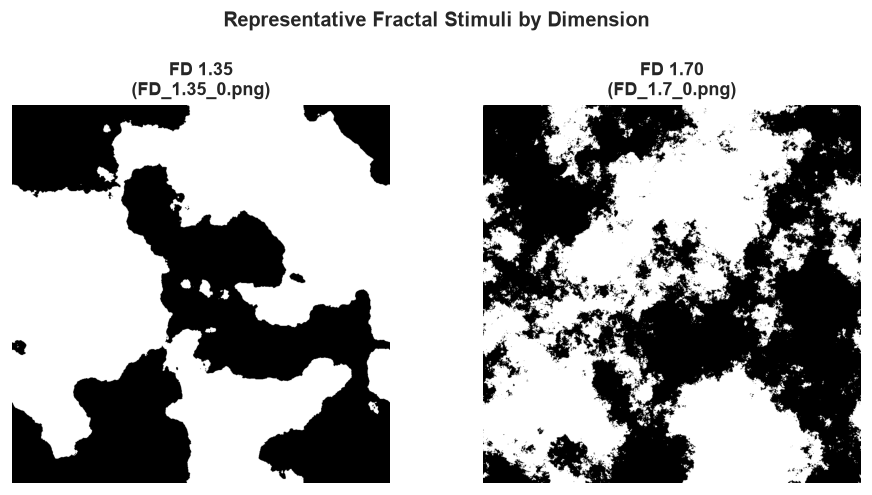

In [82]:
from pathlib import Path
from PIL import Image
import pandas as pd
import matplotlib.pyplot as plt

# Dataset directories
DATASET_DIRS = {
    "FD 1.35": Path("new-FD-images/FD135"),
    "FD 1.70": Path("new-FD-images/FD17")
}

# Fallback paths if directories are named differently
if not list(DATASET_DIRS.values())[0].exists():
    DATASET_DIRS = {
        "FD 1.35": Path("FD135"),
        "FD 1.70": Path("FD17")
    }

dataset_records = []
sample_images = {}

for fd_label, dir_path in DATASET_DIRS.items():
    if not dir_path.exists():
        print(f"Warning: Directory not found -> {dir_path}")
        continue

    imgs = sorted(list(dir_path.glob("*.png")) + list(dir_path.glob("*.jpg")))
    if imgs and fd_label not in sample_images:
        sample_images[fd_label] = imgs[0]

    for img_p in imgs:
        with Image.open(img_p) as im:
            w, h = im.size
            mode = im.mode
            ext = img_p.suffix.lower()

        dataset_records.append({
            "FD Category": fd_label,
            "File Name": img_p.name,
            "Width": w,
            "Height": h,
            "Channels/Mode": mode,
            "Format": ext
        })

df_dataset = pd.DataFrame(dataset_records)

print("=" * 70)
print("DATASET OVERVIEW: FRACTAL STIMULI")
print("=" * 70)

if not df_dataset.empty:
    summary = df_dataset.groupby("FD Category").agg(
        Total_Images=("File Name", "count"),
        Width=("Width", "first"),
        Height=("Height", "first"),
        Mode=("Channels/Mode", "first")
    ).reset_index()
    print(summary.to_string(index=False))
    print("-" * 70)
    print(f"Total Stimulus Images: {len(df_dataset)}")
    print("=" * 70)

    # Plot representative samples
    fig, axes = plt.subplots(1, 2, figsize=(8, 4), dpi=120)
    for idx, (fd_label, sample_path) in enumerate(sample_images.items()):
        img = Image.open(sample_path)
        axes[idx].imshow(img)
        axes[idx].set_title(f"{fd_label}\n({sample_path.name})", fontsize=11, fontweight="bold")
        axes[idx].axis("off")

    plt.suptitle("Representative Fractal Stimuli by Dimension", fontsize=12, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print("No images found in the specified dataset directories.")

# 2. Models

## 2.1 Gemini

#### Example:

Step 3: Full Pipeline Execution Profile (Gemini-3.1-Pro)
File: FD_1.35_0.png | Temp: 0.0 | Run: 1


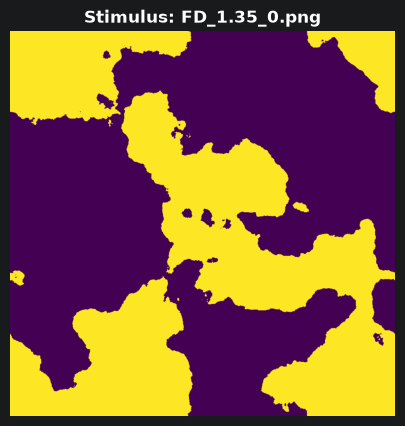


>>> PHASE 1: BASELINE DAT (CONTROL)
[PROMPT]:
Please enter 10 words that are as different from each other as possible, in all meanings and uses of the words. Rules: Only single words in English. Only nouns (e.g., things, objects, concepts). No proper nouns (e.g., no specific people or places). No specialised vocabulary (e.g., no technical terms). Think of the words on your own (e.g., do not just look at objects in your surroundings).  Make a list of these 10 words, a single word in each entry of the list.
Output must be strict valid JSON only, with no extra text.
Schema:
{"words":["string","string","string","string","string","string","string","string","string","string"]}
Constraints:
- The array must contain exactly 10 entries.
- Do not output numbering, explanations, or markdown.

[MODEL OUTPUT]:
{
  "words": [
    "justice",
    "galaxy",
    "reptile",
    "scissors",
    "desert",
    "afternoon",
    "soup",
    "glove",
    "melody",
    "breeze"
  ]
}

>>> PHASE 2 - TURN 1: FRA

In [6]:
import json
import matplotlib.pyplot as plt
from matplotlib.image import imread
from pathlib import Path

MODEL_NAME = "Gemini-3.1-Pro"
RESULTS_DIR = Path("results")
IMAGE_DIRS = [Path("new-FD-images/FD135"), Path("new-FD-images/FD17")]

main_file = RESULTS_DIR / MODEL_NAME / "main_results.jsonl"
baseline_file = RESULTS_DIR / MODEL_NAME / "dat_baseline_results.jsonl"

main_data = None
if main_file.exists():
    with open(main_file, "r", encoding="utf-8") as f:
        for line in f:
            if line.strip():
                main_data = json.loads(line)
                break

if main_data:
    target_temp = main_data.get('temperature')
    target_run = main_data.get('run_id')
    img_filename = main_data.get('file')

    baseline_data = None
    if baseline_file.exists():
        with open(baseline_file, "r", encoding="utf-8") as f:
            for line in f:
                if line.strip():
                    b_data = json.loads(line)
                    if b_data.get('temperature') == target_temp and b_data.get('run_id') == target_run:
                        baseline_data = b_data
                        break

    img_path = None
    for d in IMAGE_DIRS:
        p = d / img_filename
        if p.exists():
            img_path = p
            break

    print(f"Step 3: Full Pipeline Execution Profile ({MODEL_NAME})")
    print(f"File: {img_filename} | Temp: {target_temp} | Run: {target_run}")

    if img_path:
        plt.figure(figsize=(5, 5))
        img = imread(img_path)
        plt.imshow(img)
        plt.axis('off')
        plt.title(f"Stimulus: {img_filename}", fontweight='bold')
        plt.show()
    else:
        print(f"\n[IMAGE NOT FOUND: {img_filename}]")

    print("\n" + "="*80)
    print(">>> PHASE 1: BASELINE DAT (CONTROL)")
    print("="*80)
    print("[PROMPT]:")
    print(DAT_PROMPT.strip())
    print("\n[MODEL OUTPUT]:")
    if baseline_data and baseline_data.get('dat_parsed'):
        print(json.dumps(baseline_data['dat_parsed'], indent=2))
    else:
        print("No baseline data found for this run.")

    print("\n" + "="*80)
    print(">>> PHASE 2 - TURN 1: FRACTAL PAREIDOLIA")
    print("="*80)
    print("[PROMPT]:")
    print(FRACTAL_PROMPT.strip() + f"\n[ATTACHED IMAGE: {img_filename}]")
    print("\n[MODEL OUTPUT]:")
    fp = main_data.get('fractal_parsed') or {}
    print(json.dumps(fp, indent=2))

    print("\n" + "="*80)
    print(">>> PHASE 2 - TURN 2: PRIMED DAT (SAME THREAD)")
    print("="*80)
    print("[PROMPT]:")
    print(DAT_PROMPT.strip())
    print("\n[MODEL OUTPUT]:")
    dp = main_data.get('dat_parsed') or {}
    print(json.dumps(dp, indent=2))
    print("="*80 + "\n")
else:
    print(f"No data found in {main_file}")

#### Experiment Analysis:

In [7]:
import json
from pathlib import Path

MODEL_NAME = "Gemini-3.1-Pro"
RESULTS_DIR = Path("results")
IMAGE_DIRS = [Path("new-FD-images/FD135"), Path("new-FD-images/FD17")]
TEMPERATURES = [0.0, 1.0, 1.5]
NUM_RUNS = 10

images = []
for d in IMAGE_DIRS:
    if d.exists():
        images.extend(d.glob("*.png"))
        images.extend(d.glob("*.jpg"))

expected_combos = set((temp, img.name, run_id) for img in images for temp in TEMPERATURES for run_id in range(1, NUM_RUNS + 1))

main_file = RESULTS_DIR / MODEL_NAME / "main_results.jsonl"
completed_combos = set()

if main_file.exists():
    with open(main_file, "r", encoding="utf-8") as f:
        for line in f:
            if not line.strip():
                continue
            try:
                data = json.loads(line)
                if 'temperature' in data and 'file' in data and 'run_id' in data:
                    completed_combos.add((data['temperature'], data['file'], data['run_id']))
            except json.JSONDecodeError:
                pass

missing_combos = expected_combos - completed_combos

print(f"Step 4: Execution Progress for {MODEL_NAME}")
print("="*50)
print(f"Total Images Found    : {len(images)}")
print(f"Expected Runs (Total) : {len(expected_combos)}")
print(f"Completed Runs        : {len(completed_combos)}")
print(f"Missing Runs          : {len(missing_combos)}")
percentage = (len(completed_combos) / len(expected_combos)) * 100 if expected_combos else 0
print(f"Completion Rate       : {percentage:.2f}%")
print("="*50)

if missing_combos:
    print("\nSample of missing runs (showing up to 5):")
    for m in list(missing_combos)[:5]:
        print(f"- Temp: {m[0]} | File: {m[1]} | Run ID: {m[2]}")
else:
    print("\nAll expected runs are 100% completed!")

Step 4: Execution Progress for Gemini-3.1-Pro
Total Images Found    : 161
Expected Runs (Total) : 4830
Completed Runs        : 4525
Missing Runs          : 305
Completion Rate       : 93.69%

Sample of missing runs (showing up to 5):
- Temp: 1.0 | File: FD_1.7_45.png | Run ID: 1
- Temp: 1.5 | File: FD_1.7_68.png | Run ID: 4
- Temp: 1.0 | File: FD_1.7_45.png | Run ID: 10
- Temp: 1.5 | File: FD_1.35_44.png | Run ID: 4
- Temp: 1.0 | File: FD_1.7_50.png | Run ID: 6


#### Vocab Analysis:

In [10]:
import json
import numpy as np
import pandas as pd
from pathlib import Path
from collections import Counter
from itertools import combinations
from scipy.stats import entropy

MODEL_NAME = "Gemini-3.1-Pro"
RESULTS_DIR = Path("results")

main_file = RESULTS_DIR / MODEL_NAME / "main_results.jsonl"
base_file = RESULTS_DIR / MODEL_NAME / "dat_baseline_results.jsonl"

main_records = []
if main_file.exists():
    with open(main_file, 'r', encoding='utf-8') as f:
        for line in f:
            if line.strip():
                try:
                    main_records.append(json.loads(line))
                except json.JSONDecodeError:
                    pass

base_records = []
if base_file.exists():
    with open(base_file, 'r', encoding='utf-8') as f:
        for line in f:
            if line.strip():
                try:
                    base_records.append(json.loads(line))
                except json.JSONDecodeError:
                    pass

df_main = pd.DataFrame(main_records)
df_base = pd.DataFrame(base_records)

def extract_fd(filename):
    if '1.35' in str(filename): return 'FD1.35'
    if '1.7' in str(filename): return 'FD1.7'
    return 'Unknown'

def get_dat_words(dat_parsed):
    if isinstance(dat_parsed, dict) and 'words' in dat_parsed:
        return [str(w).lower().strip() for w in dat_parsed['words'] if str(w).strip()]
    return []

def get_percept_labels(fractal_parsed):
    if isinstance(fractal_parsed, dict) and 'percepts' in fractal_parsed:
        return [str(p.get('label', '')).lower().strip() for p in fractal_parsed['percepts'] if isinstance(p, dict) and p.get('label')]
    return []

def get_mean_confidence(fractal_parsed):
    if isinstance(fractal_parsed, dict) and 'percepts' in fractal_parsed:
        confs = [p.get('confidence_present', 0) for p in fractal_parsed['percepts'] if isinstance(p, dict)]
        if confs: return np.mean(confs)
    return np.nan

def calc_ttr(words):
    return len(set(words)) / len(words) if words else 0.0

def calc_entropy(words):
    if not words: return 0.0
    counts = list(Counter(words).values())
    probs = np.array(counts) / sum(counts)
    return entropy(probs)

df_main['fd'] = df_main['file'].apply(extract_fd)
df_main['dat_words'] = df_main['dat_parsed'].apply(get_dat_words)
df_main['percept_labels'] = df_main['fractal_parsed'].apply(get_percept_labels)
df_main['mean_confidence'] = df_main['fractal_parsed'].apply(get_mean_confidence)

df_main['total_words'] = df_main['dat_words'].apply(len)
df_main['unique_words'] = df_main['dat_words'].apply(lambda x: len(set(x)))
df_main['ttr'] = df_main['dat_words'].apply(calc_ttr)
df_main['repetition_rate'] = 1.0 - df_main['ttr']
df_main['entropy'] = df_main['dat_words'].apply(calc_entropy)

df_base['dat_words'] = df_base['dat_parsed'].apply(get_dat_words)
baseline_vocab_by_temp = {}
if not df_base.empty and 'temperature' in df_base.columns:
    for temp, group in df_base.groupby('temperature'):
        baseline_vocab_by_temp[temp] = set([w for words in group['dat_words'] for w in words])

def calc_novel_ratio(row):
    temp = row.get('temperature')
    words = row.get('dat_words', [])
    if not words or temp not in baseline_vocab_by_temp: return 0.0
    base_vocab = baseline_vocab_by_temp[temp]
    novel_words = [w for w in words if w not in base_vocab]
    return len(novel_words) / len(words)

df_main['novel_word_prop'] = df_main.apply(calc_novel_ratio, axis=1)

def calc_image_consistency(labels_list_of_runs):
    valid_runs = [set(labels) for labels in labels_list_of_runs if labels]
    if len(valid_runs) < 2:
        return np.nan
    sims = []
    for s1, s2 in combinations(valid_runs, 2):
        union = len(s1.union(s2))
        sims.append(len(s1.intersection(s2)) / union if union > 0 else 1.0)
    return np.mean(sims) if sims else np.nan

consistency_results = []
for (temp, file), group in df_main.groupby(['temperature', 'file']):
    score = calc_image_consistency(group['percept_labels'].tolist())
    consistency_results.append({
        'temperature': temp,
        'file': file,
        'fd': group['fd'].iloc[0],
        'consistency_score': score
    })
df_consistency = pd.DataFrame(consistency_results)

print("="*75)
print(f"ANALYSIS SUMMARY: {MODEL_NAME}")
print("="*75)

print("\n1. EFFECT OF FD ON VOCABULARY SIZE (Overall Unique Words):")
for fd, grp in df_main.groupby('fd'):
    unique_words_count = len(set([w for words in grp['dat_words'] for w in words]))
    print(f"  - {fd:<7}: {unique_words_count} unique words")

print("\n2. MEAN CONFIDENCE LEVELS BY TEMPERATURE:")
mean_conf = df_main.groupby('temperature')['mean_confidence'].mean()
for t, val in mean_conf.items():
    print(f"  - Temp {t}: {val:.2f}%")

print("\n3. WORD DIVERSITY METRICS (Averaged across runs):")
div_metrics = ['total_words', 'ttr', 'repetition_rate', 'novel_word_prop', 'entropy']
diversity_summary = df_main.groupby('temperature')[div_metrics].mean()
print(diversity_summary.round(4).to_string())



ANALYSIS SUMMARY: Gemini-3.1-Pro

1. EFFECT OF FD ON VOCABULARY SIZE (Overall Unique Words):
  - FD1.35 : 666 unique words
  - FD1.7  : 646 unique words

2. MEAN CONFIDENCE LEVELS BY TEMPERATURE:
  - Temp 0.0: 72.76%
  - Temp 1.0: 71.40%
  - Temp 1.5: 70.09%

3. WORD DIVERSITY METRICS (Averaged across runs):
             total_words  ttr  repetition_rate  novel_word_prop  entropy
temperature                                                             
0.0                 10.0  1.0              0.0           0.5918   2.3026
1.0                 10.0  1.0              0.0           0.5480   2.3026
1.5                 10.0  1.0              0.0           0.5509   2.3026


#### Perception Analysis

Total Unique Images in Data : 161
Total Executed Runs         : 4525

PAREIDOLIA CONSISTENCY: Gemini-3.1-Pro

Mean Jaccard Similarity:
                    count    mean     std
temperature fd                           
0.0         FD1.35     78  0.7436  0.1557
            FD1.7      80  0.8733  0.1156
1.0         FD1.35     81  0.1792  0.0597
            FD1.7      62  0.2055  0.0555
1.5         FD1.35     79  0.1762  0.0457
            FD1.7      78  0.2211  0.0710
------------------------------------------------------------


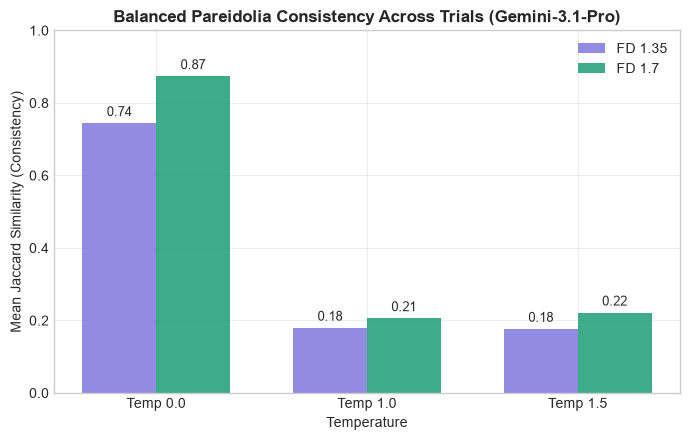

In [77]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from itertools import combinations

MODEL_NAME = "Gemini-3.1-Pro"
RESULTS_DIR = Path("results")
main_file = RESULTS_DIR / MODEL_NAME / "main_results.jsonl"
MIN_RUNS_PER_TEMP = 2

main_records = []
if main_file.exists():
    with open(main_file, 'r', encoding='utf-8') as f:
        for line in f:
            if line.strip():
                try:
                    main_records.append(json.loads(line))
                except json.JSONDecodeError:
                    pass

df_main = pd.DataFrame(main_records)

def extract_fd(filename):
    if '1.35' in str(filename): return 'FD1.35'
    if '1.7' in str(filename): return 'FD1.7'
    return 'Unknown'

def get_percept_labels(fractal_parsed):
    if isinstance(fractal_parsed, dict) and 'percepts' in fractal_parsed:
        return [str(p.get('label', '')).lower().strip() for p in fractal_parsed['percepts'] if isinstance(p, dict) and p.get('label')]
    return []

df_main['fd'] = df_main['file'].apply(extract_fd)
df_main['percept_labels'] = df_main['fractal_parsed'].apply(get_percept_labels)

print(f"Total Unique Images in Data : {df_main['file'].nunique()}")
print(f"Total Executed Runs         : {len(df_main)}")
print("="*60)

# Step B: Calculate Jaccard Consistency across trials
def calc_image_consistency(labels_list_of_runs):
    valid_runs = [set(labels) for labels in labels_list_of_runs if labels]
    if len(valid_runs) < MIN_RUNS_PER_TEMP:
        return np.nan
    sims = []
    for s1, s2 in combinations(valid_runs, 2):
        union = len(s1.union(s2))
        sims.append(len(s1.intersection(s2)) / union if union > 0 else 1.0)
    return np.mean(sims) if sims else np.nan

consistency_records = []
for (temp, file), group in df_main.groupby(['temperature', 'file']):
    score = calc_image_consistency(group['percept_labels'].tolist())
    consistency_records.append({
        'temperature': temp,
        'file': file,
        'fd': group['fd'].iloc[0],
        'consistency_score': score
    })

df_consistency = pd.DataFrame(consistency_records)

print(f"\nPAREIDOLIA CONSISTENCY: {MODEL_NAME}")
print("="*60)

summary_table = df_consistency.groupby(['temperature', 'fd'])['consistency_score'].agg(['count', 'mean', 'std']).round(4)
print("\nMean Jaccard Similarity:")
print(summary_table.to_string())
print("-" * 60)

# Step C: Plot the Results exactly with your original palette and styling
pivot_data = df_consistency.groupby(['temperature', 'fd'])['consistency_score'].mean().unstack('fd')

fig, ax = plt.subplots(figsize=(7, 4.5))
temps = pivot_data.index
x = np.arange(len(temps))
width = 0.35

ax.bar(x - width/2, pivot_data['FD1.35'], width, label='FD 1.35', color='#7F77DD', alpha=0.85)
ax.bar(x + width/2, pivot_data['FD1.7'], width, label='FD 1.7', color='#1D9E75', alpha=0.85)

ax.set_xlabel('Temperature')
ax.set_ylabel('Mean Jaccard Similarity (Consistency)')
ax.set_title(f'Balanced Pareidolia Consistency Across Trials ({MODEL_NAME})', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([f"Temp {t}" for t in temps])
ax.set_ylim(0, 1.0)
ax.legend(frameon=False)

for i in x:
    val1 = pivot_data['FD1.35'].iloc[i]
    val2 = pivot_data['FD1.7'].iloc[i]
    if not np.isnan(val1):
        ax.text(i - width/2, val1 + 0.02, f"{val1:.2f}", ha='center', fontsize=9)
    if not np.isnan(val2):
        ax.text(i + width/2, val2 + 0.02, f"{val2:.2f}", ha='center', fontsize=9)

plt.tight_layout()
plt.show()

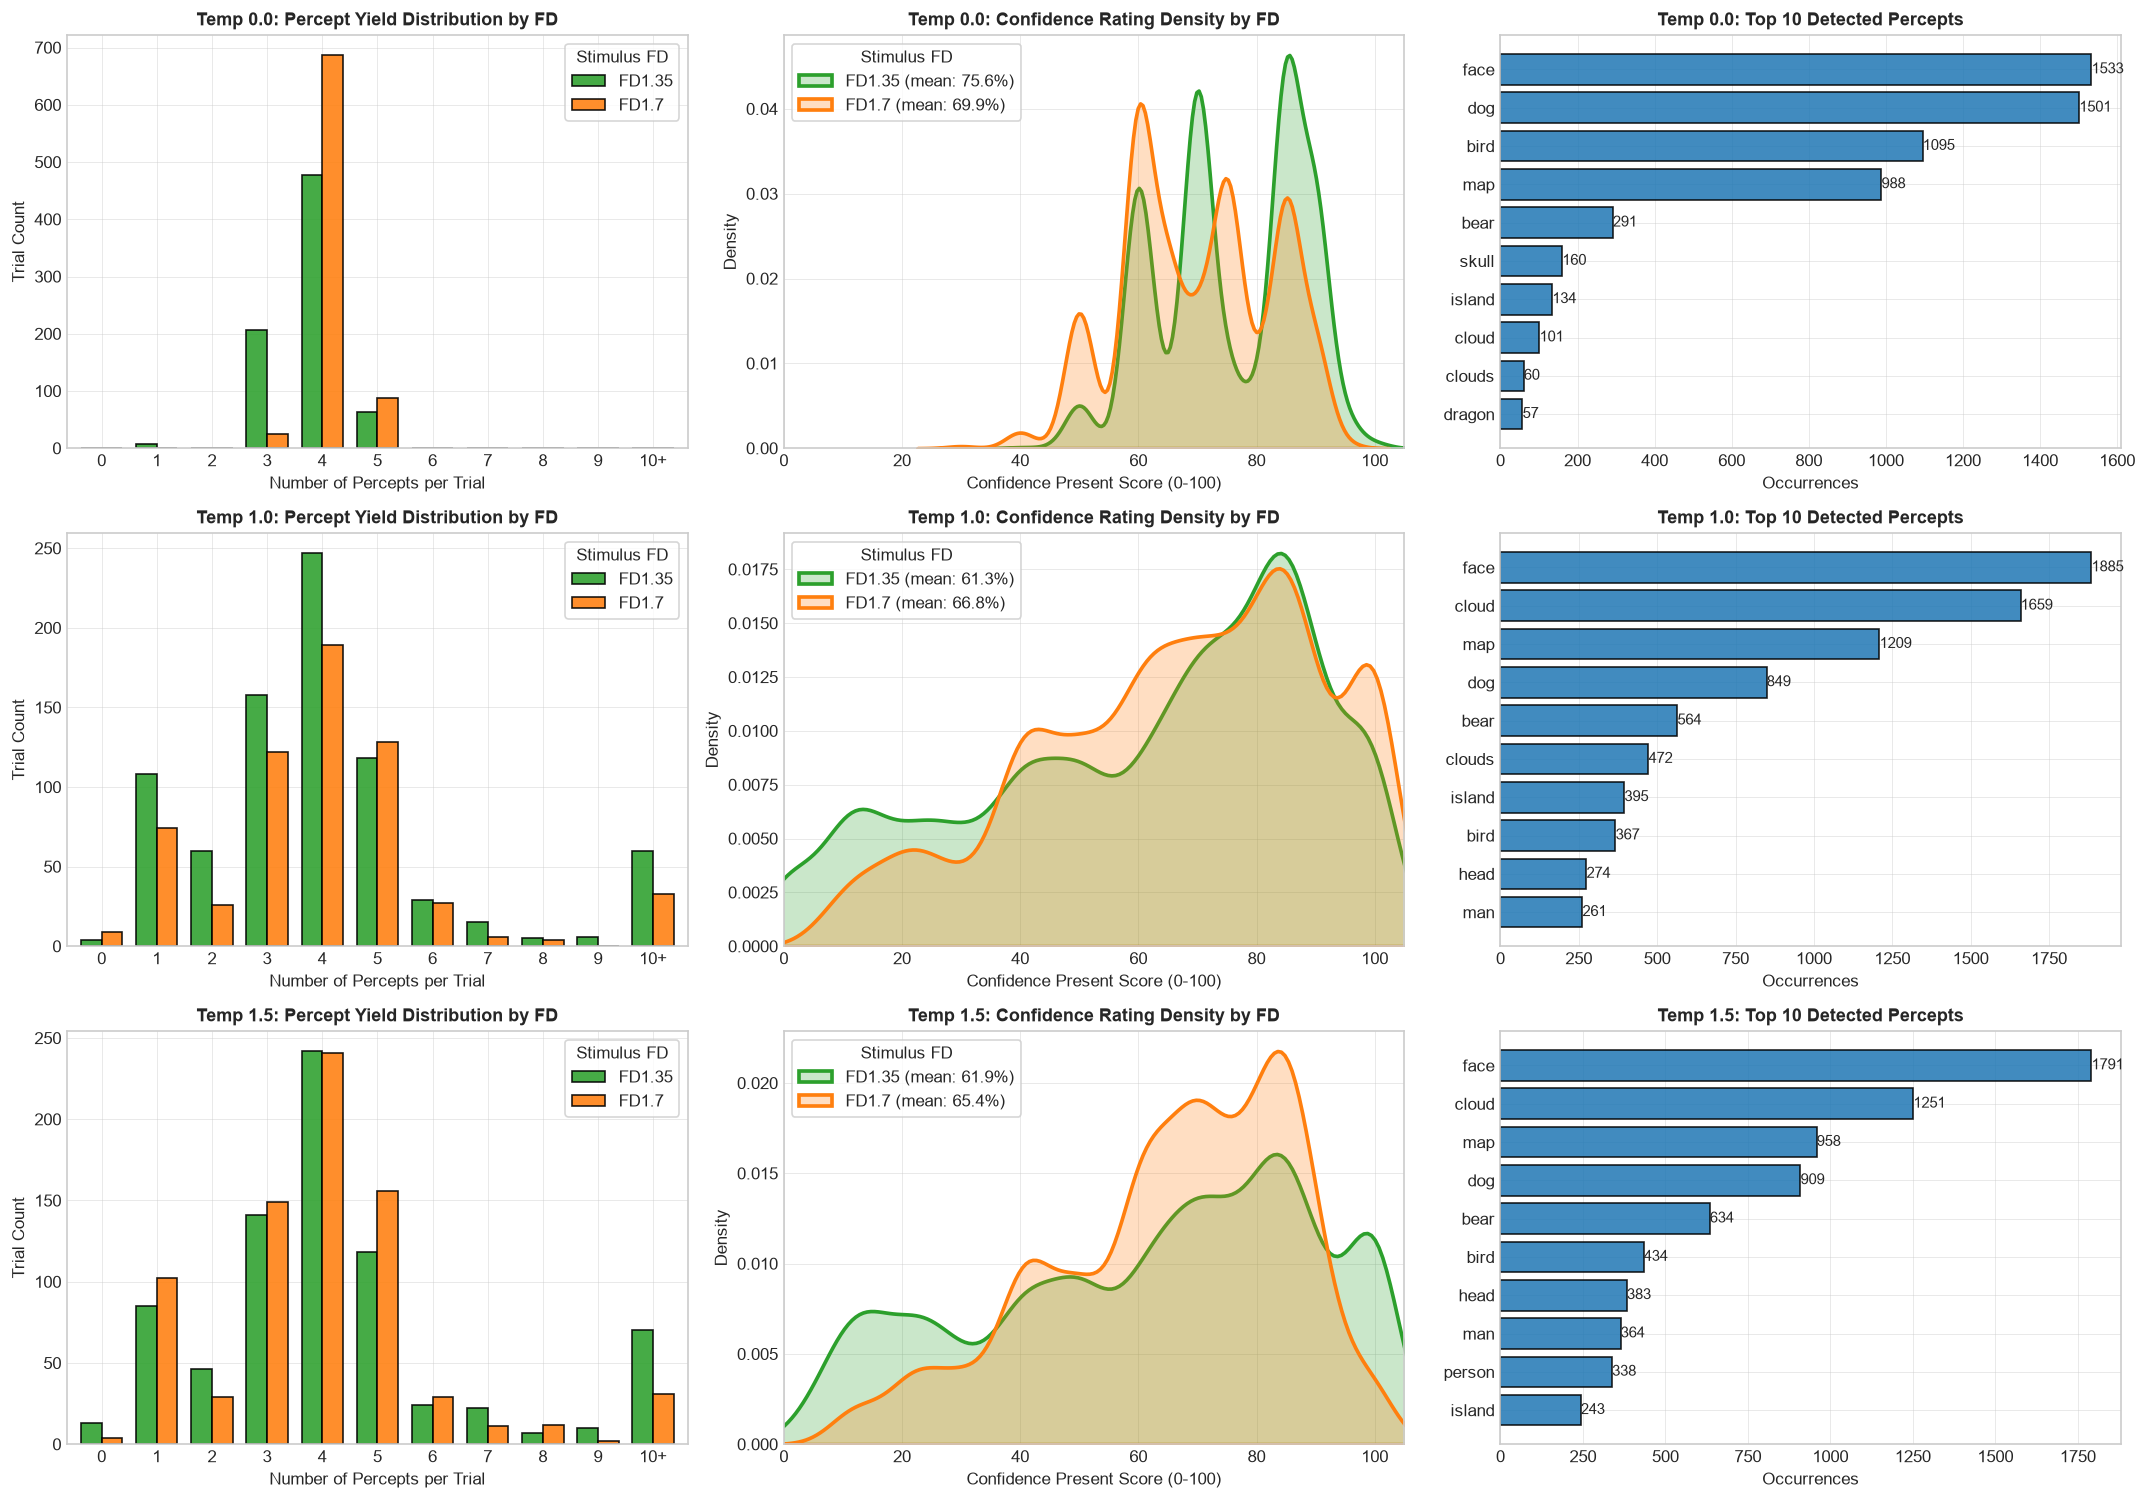

In [81]:
import json
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter

MODEL_NAME = "Gemini-3.1-Pro"
RESULTS_DIR = Path("results") / MODEL_NAME
main_file = RESULTS_DIR / "main_results.jsonl"

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

main_records = []
if main_file.exists():
    with open(main_file, 'r', encoding='utf-8') as f:
        for line in f:
            if line.strip():
                try:
                    main_records.append(json.loads(line))
                except json.JSONDecodeError:
                    pass

df_main = pd.DataFrame(main_records)

if df_main.empty:
    raise ValueError(f"No records found in {main_file}")

def extract_fd(filename):
    if '1.35' in str(filename): return 'FD1.35'
    if '1.7' in str(filename): return 'FD1.7'
    return 'Unknown'

def safe_parse_confidence(val):
    if val is None:
        return None
    if isinstance(val, (int, float)):
        return float(val)
    if isinstance(val, str):
        match = re.search(r"[-+]?\d*\.?\d+", val)
        if match:
            try:
                return float(match.group())
            except ValueError:
                return None
    return None

def extract_percept_details(row):
    parsed = row.get('fractal_parsed') or row.get('image_parsed') or {}
    labels = []
    confs = []
    if isinstance(parsed, dict) and 'percepts' in parsed:
        for p in parsed['percepts']:
            if isinstance(p, dict):
                lbl = str(p.get('label', '')).lower().strip()
                if lbl:
                    labels.append(lbl)
                c_val = safe_parse_confidence(p.get('confidence_present'))
                if c_val is not None:
                    confs.append(c_val)
    return labels, confs

df_main['fd'] = df_main['file'].apply(extract_fd)
extracted = df_main.apply(extract_percept_details, axis=1)
df_main['percept_labels'] = [x[0] for x in extracted]
df_main['confidence_list'] = [x[1] for x in extracted]
df_main['percept_count'] = df_main['percept_labels'].apply(len)

# دسته‌بندی مقادیر پرت بالاتر از ۱۰ برای خلوت و خوانا شدن محور X
MAX_DISPLAY_PERCEPTS = 10
def bin_percept_count(cnt):
    if cnt >= MAX_DISPLAY_PERCEPTS:
        return f"{MAX_DISPLAY_PERCEPTS}+"
    return str(cnt)

df_main['percept_count_binned'] = df_main['percept_count'].apply(bin_percept_count)

# ترتیب برچسب‌های محور افقی
bin_order = [str(i) for i in range(MAX_DISPLAY_PERCEPTS)] + [f"{MAX_DISPLAY_PERCEPTS}+"]

temperatures = sorted(df_main['temperature'].dropna().unique())
fd_colors = {'FD1.35': '#2ca02c', 'FD1.7': '#ff7f0e'}

fig, axes = plt.subplots(len(temperatures), 3, figsize=(18, 4.2 * len(temperatures)), dpi=120)

for r, temp in enumerate(temperatures):
    df_temp = df_main[df_main['temperature'] == temp]

    # -------------------------------------------------------------
    # Col 1: Percept Yield by FD (با محور X کامپکت و کاملاً خوانا)
    # -------------------------------------------------------------
    ax_count = axes[r, 0]
    yield_data = df_temp.groupby(['percept_count_binned', 'fd']).size().unstack(fill_value=0)

    # اعمال ترتیب یکدست روی تمام اعداد
    yield_data = yield_data.reindex(bin_order, fill_value=0)
    for fd_col in ['FD1.35', 'FD1.7']:
        if fd_col not in yield_data.columns:
            yield_data[fd_col] = 0

    yield_data[['FD1.35', 'FD1.7']].plot(
        kind='bar',
        ax=ax_count,
        color=[fd_colors['FD1.35'], fd_colors['FD1.7']],
        edgecolor='black',
        alpha=0.88,
        width=0.75
    )
    ax_count.set_title(f"Temp {temp}: Percept Yield Distribution by FD", fontsize=11, fontweight='bold')
    ax_count.set_xlabel("Number of Percepts per Trial", fontsize=10)
    ax_count.set_ylabel("Trial Count", fontsize=10)
    ax_count.tick_params(axis='x', rotation=0, labelsize=10)
    ax_count.legend(title="Stimulus FD", frameon=True)

    # -------------------------------------------------------------
    # Col 2: Confidence Rating Distributions by FD
    # -------------------------------------------------------------
    ax_conf = axes[r, 1]
    for fd_cat in ['FD1.35', 'FD1.7']:
        sub_fd = df_temp[df_temp['fd'] == fd_cat]
        confs = [c for clist in sub_fd['confidence_list'] for c in clist]
        if confs:
            sns.kdeplot(
                confs,
                ax=ax_conf,
                color=fd_colors[fd_cat],
                label=f"{fd_cat} (mean: {np.mean(confs):.1f}%)",
                linewidth=2.2,
                fill=True,
                alpha=0.25
            )
    ax_conf.set_title(f"Temp {temp}: Confidence Rating Density by FD", fontsize=11, fontweight='bold')
    ax_conf.set_xlabel("Confidence Present Score (0-100)", fontsize=10)
    ax_conf.set_ylabel("Density", fontsize=10)
    ax_conf.set_xlim(0, 105)
    ax_conf.legend(title="Stimulus FD", frameon=True)

    # -------------------------------------------------------------
    # Col 3: Top 10 Percept Labels Discovered
    # -------------------------------------------------------------
    ax_labels = axes[r, 2]
    all_temp_labels = [lbl for labels in df_temp['percept_labels'] for lbl in labels]
    top_labels = pd.DataFrame(Counter(all_temp_labels).most_common(10), columns=['Label', 'Count'])

    if not top_labels.empty:
        ax_labels.barh(top_labels['Label'][::-1], top_labels['Count'][::-1], color='#1f77b4', edgecolor='black', alpha=0.85)
        for idx, row in enumerate(top_labels.iloc[::-1].itertuples()):
            ax_labels.text(row.Count + 0.5, idx, f"{row.Count}", va='center', fontsize=9)
    ax_labels.set_title(f"Temp {temp}: Top 10 Detected Percepts", fontsize=11, fontweight='bold')
    ax_labels.set_xlabel("Occurrences", fontsize=10)

plt.tight_layout()
plt.show()

#### Left experiments:

In [17]:
import pandas as pd
import numpy as np
from pathlib import Path

ACTIVITY_FILE = "../openrouter_activity_2026-06-27.csv"
MODEL_NAME = "google/gemini-3.1-pro-preview"

TOTAL_IMAGES = 161
TEMPERATURES_COUNT = 3
RUNS_PER_IMAGE = 10
DAT_BASELINE_RUNS = 10

total_expected_runs = TOTAL_IMAGES * TEMPERATURES_COUNT * RUNS_PER_IMAGE
total_expected_calls = (total_expected_runs * 2) + (TEMPERATURES_COUNT * DAT_BASELINE_RUNS)

df_act = pd.read_csv(ACTIVITY_FILE)

# Filter records for Gemini 3.1 Pro
gemini_mask = df_act['model_permaslug'].str.contains('gemini-3.1-pro', case=False, na=False)
df_gemini = df_act[gemini_mask].copy()

total_completed_calls = len(df_gemini)
total_prompt_tokens = df_gemini['tokens_prompt'].sum()
total_completion_tokens = df_gemini['tokens_completion'].sum()
total_tokens = total_prompt_tokens + total_completion_tokens
total_cost = df_gemini['cost_total'].sum()

mean_prompt_per_call = df_gemini['tokens_prompt'].mean()
mean_comp_per_call = df_gemini['tokens_completion'].mean()
mean_cost_per_call = df_gemini['cost_total'].mean()

missing_calls = max(0, total_expected_calls - total_completed_calls)
missing_runs = missing_calls // 2

est_missing_prompt_tokens = int(missing_calls * mean_prompt_per_call)
est_missing_comp_tokens = int(missing_calls * mean_comp_per_call)
est_missing_total_tokens = est_missing_prompt_tokens + est_missing_comp_tokens
est_missing_cost = missing_calls * mean_cost_per_call

print("=" * 65)
print("TOKEN USAGE & BUDGET ESTIMATION (Gemini-3.1-Pro)")
print("=" * 65)
print(f"Total Completed API Calls     : {total_completed_calls:,}")
print(f"Total Prompt Tokens Used      : {total_prompt_tokens:,}")
print(f"Total Completion Tokens Used  : {total_completion_tokens:,}")
print(f"Total Tokens Consumed         : {total_tokens:,}")
print(f"Total Cost Spent              : ${total_cost:,.2f}")
print("-" * 65)
print(f"Mean Prompt Tokens / Call     : {mean_prompt_per_call:,.1f}")
print(f"Mean Completion Tokens / Call : {mean_comp_per_call:,.1f}")
print(f"Mean Cost / Call              : ${mean_cost_per_call:,.4f}")
print(f"Mean Cost / Full Run (2 calls): ${mean_cost_per_call * 2:,.4f}")
print("-" * 65)
print(f"Total Expected API Calls      : {total_expected_calls:,}")
print(f"Remaining Missing Calls       : {missing_calls:,} (~{missing_runs} runs)")
print(f"Estimated Missing Tokens      : {est_missing_total_tokens:,}")
print(f"Estimated Cost to Complete    : ${est_missing_cost:,.2f}")
print("=" * 65)

TOKEN USAGE & BUDGET ESTIMATION (Gemini-3.1-Pro)
Total Completed API Calls     : 9,025
Total Prompt Tokens Used      : 13,559,983
Total Completion Tokens Used  : 11,101,850
Total Tokens Consumed         : 24,661,833
Total Cost Spent              : $160.34
-----------------------------------------------------------------
Mean Prompt Tokens / Call     : 1,502.5
Mean Completion Tokens / Call : 1,230.1
Mean Cost / Call              : $0.0178
Mean Cost / Full Run (2 calls): $0.0355
-----------------------------------------------------------------
Total Expected API Calls      : 9,690
Remaining Missing Calls       : 665 (~332 runs)
Estimated Missing Tokens      : 1,817,187
Estimated Cost to Complete    : $11.81


## 2.2 Claude Opus 4.7

#### Example:

Step 1: Execution Profile for Claude-Opus-4-7
File: FD_1.35_0.png | Temp: 0.0 | Run: 1


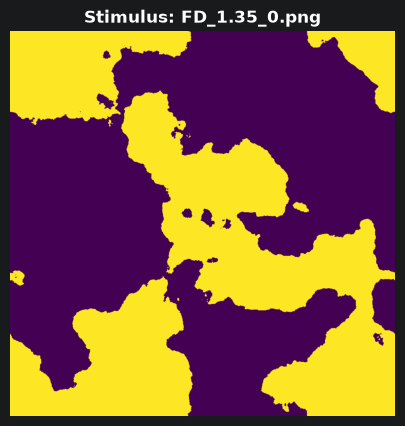


>>> PHASE 1: BASELINE DAT (CONTROL)
[PROMPT]:
Please name 10 words that are as different from each other as possible, in all ways and meanings you can imagine.

Rules:
- Only single words.
- Only nouns (e.g. things, concepts, objects). No verbs, adjectives, or other parts of speech.
- No proper nouns (no specific people, places, or brands).
- No specialized vocabulary, technical jargon, or obscure words.
- Think about different categories, contexts, domains, and properties.

Respond with a JSON object:
{
  "words": ["word1", "word2", "word3", "word4", "word5", "word6", "word7", "word8", "word9", "word10"]
}

[MODEL OUTPUT]:
{
  "words": [
    "mountain",
    "sorrow",
    "whisper",
    "engine",
    "freedom",
    "jellyfish",
    "triangle",
    "yesterday",
    "velvet",
    "hunger"
  ]
}

>>> PHASE 2 - TURN 1: FRACTAL PAREIDOLIA
[PROMPT]:
Look closely at this image. Do you see any shapes, faces, objects, animals, or patterns in it?

Please list everything you can perceive, even i

In [20]:
import json
import matplotlib.pyplot as plt
from matplotlib.image import imread

main_data = None
with open(main_file, "r", encoding="utf-8") as f:
    for line in f:
        if line.strip():
            main_data = json.loads(line)
            break

if main_data:
    target_temp = main_data.get('temperature')
    target_run = main_data.get('run_id')
    img_filename = main_data.get('file')

    baseline_data = None
    if baseline_file.exists():
        with open(baseline_file, "r", encoding="utf-8") as f:
            for line in f:
                if line.strip():
                    b_data = json.loads(line)
                    if b_data.get('temperature') == target_temp and b_data.get('run_id') == target_run:
                        baseline_data = b_data
                        break

    img_path = None
    for d in IMAGE_DIRS:
        p = d / img_filename
        if p.exists():
            img_path = p
            break

    print(f"Step 1: Execution Profile for {MODEL_NAME}")
    print(f"File: {img_filename} | Temp: {target_temp} | Run: {target_run}")

    if img_path:
        plt.figure(figsize=(5, 5))
        img = imread(img_path)
        plt.imshow(img)
        plt.axis('off')
        plt.title(f"Stimulus: {img_filename}", fontweight='bold')
        plt.show()
    else:
        print(f"\n[IMAGE NOT FOUND: {img_filename}]")

    print("\n" + "="*80)
    print(">>> PHASE 1: BASELINE DAT (CONTROL)")
    print("="*80)
    print("[PROMPT]:")
    print(DAT_PROMPT.strip())
    print("\n[MODEL OUTPUT]:")
    if baseline_data and baseline_data.get('dat_parsed'):
        print(json.dumps(baseline_data['dat_parsed'], indent=2))
    else:
        print("No baseline data found for this exact run.")

    print("\n" + "="*80)
    print(">>> PHASE 2 - TURN 1: FRACTAL PAREIDOLIA")
    print("="*80)
    print("[PROMPT]:")
    print(FRACTAL_PROMPT.strip() + f"\n[ATTACHED IMAGE: {img_filename}]")
    print("\n[MODEL OUTPUT]:")
    fp = main_data.get('fractal_parsed') or {}
    print(json.dumps(fp, indent=2))

    print("\n" + "="*80)
    print(">>> PHASE 2 - TURN 2: PRIMED DAT (SAME THREAD)")
    print("="*80)
    print("[PROMPT]:")
    print(DAT_PROMPT.strip())
    print("\n[MODEL OUTPUT]:")
    dp = main_data.get('dat_parsed') or {}
    print(json.dumps(dp, indent=2))
    print("="*80 + "\n")
else:
    print(f"No records found in {main_file}")

#### Experiment Analysis:

In [21]:
import json
from pathlib import Path

MODEL_NAME = "Claude-Opus-4-7"
RESULTS_DIR = Path("results")
IMAGE_DIRS = [Path("new-FD-images/FD135"), Path("new-FD-images/FD17")]
TEMPERATURES = [0.0, 1.0, 1.5]
NUM_RUNS = 10

images = []
for d in IMAGE_DIRS:
    if d.exists():
        images.extend(d.glob("*.png"))
        images.extend(d.glob("*.jpg"))

expected_combos = set((temp, img.name, run_id) for img in images for temp in TEMPERATURES for run_id in range(1, NUM_RUNS + 1))

main_file = RESULTS_DIR / MODEL_NAME / "main_results.jsonl"
completed_combos = set()

if main_file.exists():
    with open(main_file, "r", encoding="utf-8") as f:
        for line in f:
            if not line.strip():
                continue
            try:
                data = json.loads(line)
                if 'temperature' in data and 'file' in data and 'run_id' in data:
                    completed_combos.add((data['temperature'], data['file'], data['run_id']))
            except json.JSONDecodeError:
                pass

missing_combos = expected_combos - completed_combos

print(f"Step 2: Execution Progress for {MODEL_NAME}")
print("="*50)
print(f"Total Images Found    : {len(images)}")
print(f"Expected Runs (Total) : {len(expected_combos)}")
print(f"Completed Runs        : {len(completed_combos)}")
print(f"Missing Runs          : {len(missing_combos)}")
percentage = (len(completed_combos) / len(expected_combos)) * 100 if expected_combos else 0
print(f"Completion Rate       : {percentage:.2f}%")
print("="*50)

if missing_combos:
    print("\nSample of missing runs (showing up to 5):")
    for m in list(missing_combos)[:5]:
        print(f"- Temp: {m[0]} | File: {m[1]} | Run ID: {m[2]}")
else:
    print("\nAll expected runs are 100% completed!")

Step 2: Execution Progress for Claude-Opus-4-7
Total Images Found    : 161
Expected Runs (Total) : 4830
Completed Runs        : 4826
Missing Runs          : 4
Completion Rate       : 99.92%

Sample of missing runs (showing up to 5):
- Temp: 1.0 | File: FD_1.7_76.png | Run ID: 6
- Temp: 1.0 | File: FD_1.7_76.png | Run ID: 4
- Temp: 0.0 | File: FD_1.35_65.png | Run ID: 4
- Temp: 0.0 | File: FD_1.35_65.png | Run ID: 5


#### Vocab Analysis:

In [23]:
import json
import numpy as np
import pandas as pd
from pathlib import Path
from collections import Counter
from scipy.stats import entropy

MODEL_NAME = "Claude-Opus-4-7"
RESULTS_DIR = Path("results")

main_file = RESULTS_DIR / MODEL_NAME / "main_results.jsonl"
base_file = RESULTS_DIR / MODEL_NAME / "dat_baseline_results.jsonl"

main_records = []
if main_file.exists():
    with open(main_file, 'r', encoding='utf-8') as f:
        for line in f:
            if line.strip():
                try:
                    main_records.append(json.loads(line))
                except json.JSONDecodeError:
                    pass

base_records = []
if base_file.exists():
    with open(base_file, 'r', encoding='utf-8') as f:
        for line in f:
            if line.strip():
                try:
                    base_records.append(json.loads(line))
                except json.JSONDecodeError:
                    pass

df_main = pd.DataFrame(main_records)
df_base = pd.DataFrame(base_records)

def extract_fd(filename):
    if '1.35' in str(filename): return 'FD1.35'
    if '1.7' in str(filename): return 'FD1.7'
    return 'Unknown'

def get_dat_words(dat_parsed):
    if isinstance(dat_parsed, dict) and 'words' in dat_parsed:
        return [str(w).lower().strip() for w in dat_parsed['words'] if str(w).strip()]
    return []

def get_mean_confidence(fractal_parsed):
    if isinstance(fractal_parsed, dict) and 'percepts' in fractal_parsed:
        confs = [p.get('confidence_present', 0) for p in fractal_parsed['percepts'] if isinstance(p, dict)]
        if confs: return np.mean(confs)
    return np.nan

def calc_ttr(words):
    return len(set(words)) / len(words) if words else 0.0

def calc_entropy(words):
    if not words: return 0.0
    counts = list(Counter(words).values())
    probs = np.array(counts) / sum(counts)
    return entropy(probs)

df_main['fd'] = df_main['file'].apply(extract_fd)
df_main['dat_words'] = df_main['dat_parsed'].apply(get_dat_words)
df_main['mean_confidence'] = df_main['fractal_parsed'].apply(get_mean_confidence)

df_main['total_words'] = df_main['dat_words'].apply(len)
df_main['unique_words'] = df_main['dat_words'].apply(lambda x: len(set(x)))
df_main['ttr'] = df_main['dat_words'].apply(calc_ttr)
df_main['repetition_rate'] = 1.0 - df_main['ttr']
df_main['entropy'] = df_main['dat_words'].apply(calc_entropy)

df_base['dat_words'] = df_base['dat_parsed'].apply(get_dat_words)
baseline_vocab_by_temp = {}
if not df_base.empty and 'temperature' in df_base.columns:
    for temp, group in df_base.groupby('temperature'):
        baseline_vocab_by_temp[temp] = set([w for words in group['dat_words'] for w in words])

def calc_novel_ratio(row):
    temp = row.get('temperature')
    words = row.get('dat_words', [])
    if not words or temp not in baseline_vocab_by_temp: return 0.0
    base_vocab = baseline_vocab_by_temp[temp]
    novel_words = [w for w in words if w not in base_vocab]
    return len(novel_words) / len(words)

df_main['novel_word_prop'] = df_main.apply(calc_novel_ratio, axis=1)

print("="*75)
print(f"VOCABULARY & DIVERSITY ANALYSIS: {MODEL_NAME}")
print("="*75)

print("\n1. EFFECT OF FD ON VOCABULARY SIZE (Overall Unique Words):")
for fd, grp in df_main.groupby('fd'):
    unique_words_count = len(set([w for words in grp['dat_words'] for w in words]))
    print(f"  - {fd:<7}: {unique_words_count} unique words")

print("\n2. MEAN CONFIDENCE LEVELS BY TEMPERATURE:")
mean_conf = df_main.groupby('temperature')['mean_confidence'].mean()
for t, val in mean_conf.items():
    print(f"  - Temp {t}: {val:.2f}%")

print("\n3. WORD DIVERSITY METRICS (Averaged across runs):")
div_metrics = ['total_words', 'ttr', 'repetition_rate', 'novel_word_prop', 'entropy']
diversity_summary = df_main.groupby('temperature')[div_metrics].mean()
print(diversity_summary.round(4).to_string())
print("="*75)

VOCABULARY & DIVERSITY ANALYSIS: Claude-Opus-4-7

1. EFFECT OF FD ON VOCABULARY SIZE (Overall Unique Words):
  - FD1.35 : 477 unique words
  - FD1.7  : 443 unique words

2. MEAN CONFIDENCE LEVELS BY TEMPERATURE:
  - Temp 0.0: 54.36%
  - Temp 1.0: 54.42%
  - Temp 1.5: 54.39%

3. WORD DIVERSITY METRICS (Averaged across runs):
             total_words  ttr  repetition_rate  novel_word_prop  entropy
temperature                                                             
0.0                 10.0  1.0              0.0           0.3876   2.3026
1.0                 10.0  1.0              0.0           0.3807   2.3026
1.5                 10.0  1.0              0.0           0.3882   2.3026


#### Perception Analysis:

Total Unique Images in Data : 161
Images Complete Across All 3 Temps: 161
Excluded Incomplete Images  : 0

BALANCED PAREIDOLIA CONSISTENCY: Claude-Opus-4-7

Mean Jaccard Similarity (Balanced Subset):
                    count    mean     std
temperature fd                           
0.0         FD1.35     81  0.6408  0.1215
            FD1.7      80  0.6654  0.1216
1.0         FD1.35     81  0.6192  0.1156
            FD1.7      80  0.6536  0.1159
1.5         FD1.35     81  0.6133  0.1156
            FD1.7      80  0.6524  0.1235
------------------------------------------------------------


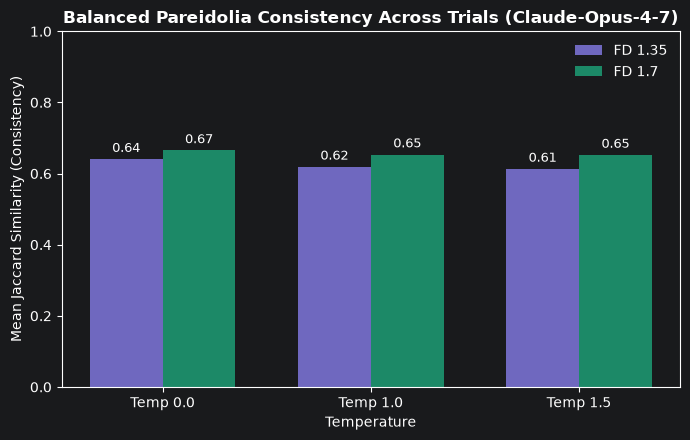

In [25]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from itertools import combinations

MODEL_NAME = "Claude-Opus-4-7"
RESULTS_DIR = Path("results")
main_file = RESULTS_DIR / MODEL_NAME / "main_results.jsonl"
REQUIRED_TEMPS = {0.0, 1.0, 1.5}
MIN_RUNS_PER_TEMP = 2

main_records = []
if main_file.exists():
    with open(main_file, 'r', encoding='utf-8') as f:
        for line in f:
            if line.strip():
                try:
                    main_records.append(json.loads(line))
                except json.JSONDecodeError:
                    pass

df_main = pd.DataFrame(main_records)

def extract_fd(filename):
    if '1.35' in str(filename): return 'FD1.35'
    if '1.7' in str(filename): return 'FD1.7'
    return 'Unknown'

def get_percept_labels(fractal_parsed):
    if isinstance(fractal_parsed, dict) and 'percepts' in fractal_parsed:
        return [str(p.get('label', '')).lower().strip() for p in fractal_parsed['percepts'] if isinstance(p, dict) and p.get('label')]
    return []

df_main['fd'] = df_main['file'].apply(extract_fd)
df_main['percept_labels'] = df_main['fractal_parsed'].apply(get_percept_labels)

# Step A: Filter ONLY images that have sufficient runs in ALL 3 temperatures
valid_files = set()
for file, file_group in df_main.groupby('file'):
    temp_counts = file_group.groupby('temperature')['run_id'].nunique()
    present_temps = set(temp_counts.index)
    if REQUIRED_TEMPS.issubset(present_temps):
        if all(temp_counts[t] >= MIN_RUNS_PER_TEMP for t in REQUIRED_TEMPS):
            valid_files.add(file)

df_filtered = df_main[df_main['file'].isin(valid_files)].copy()

print(f"Total Unique Images in Data : {df_main['file'].nunique()}")
print(f"Images Complete Across All 3 Temps: {len(valid_files)}")
print(f"Excluded Incomplete Images  : {df_main['file'].nunique() - len(valid_files)}")
print("="*60)

# Step B: Calculate Jaccard Consistency across trials for filtered images
def calc_image_consistency(labels_list_of_runs):
    valid_runs = [set(labels) for labels in labels_list_of_runs if labels]
    if len(valid_runs) < 2:
        return np.nan
    sims = []
    for s1, s2 in combinations(valid_runs, 2):
        union = len(s1.union(s2))
        sims.append(len(s1.intersection(s2)) / union if union > 0 else 1.0)
    return np.mean(sims) if sims else np.nan

consistency_records = []
for (temp, file), group in df_filtered.groupby(['temperature', 'file']):
    score = calc_image_consistency(group['percept_labels'].tolist())
    consistency_records.append({
        'temperature': temp,
        'file': file,
        'fd': group['fd'].iloc[0],
        'consistency_score': score
    })

df_consistency = pd.DataFrame(consistency_records)

print(f"\nBALANCED PAREIDOLIA CONSISTENCY: {MODEL_NAME}")
print("="*60)

summary_table = df_consistency.groupby(['temperature', 'fd'])['consistency_score'].agg(['count', 'mean', 'std']).round(4)
print("\nMean Jaccard Similarity (Balanced Subset):")
print(summary_table.to_string())
print("-" * 60)

# Step C: Plot the Balanced Results
pivot_data = df_consistency.groupby(['temperature', 'fd'])['consistency_score'].mean().unstack('fd')

fig, ax = plt.subplots(figsize=(7, 4.5))
temps = pivot_data.index
x = np.arange(len(temps))
width = 0.35

ax.bar(x - width/2, pivot_data['FD1.35'], width, label='FD 1.35', color='#7F77DD', alpha=0.85)
ax.bar(x + width/2, pivot_data['FD1.7'], width, label='FD 1.7', color='#1D9E75', alpha=0.85)

ax.set_xlabel('Temperature')
ax.set_ylabel('Mean Jaccard Similarity (Consistency)')
ax.set_title(f'Balanced Pareidolia Consistency Across Trials ({MODEL_NAME})', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([f"Temp {t}" for t in temps])
ax.set_ylim(0, 1.0)
ax.legend(frameon=False)

for i in x:
    val1 = pivot_data['FD1.35'].iloc[i]
    val2 = pivot_data['FD1.7'].iloc[i]
    ax.text(i - width/2, val1 + 0.02, f"{val1:.2f}", ha='center', fontsize=9)
    ax.text(i + width/2, val2 + 0.02, f"{val2:.2f}", ha='center', fontsize=9)

plt.tight_layout()
plt.show()

Total Unique Images in Data : 161
Images Complete Across All 3 Temps: 161
Excluded Incomplete Images  : 0

BALANCED PAREIDOLIA CONSISTENCY: Claude-Opus-4-7

Mean Jaccard Similarity (Balanced Subset):
                    count    mean     std
temperature fd                           
0.0         FD1.35     81  0.6408  0.1215
            FD1.7      80  0.6654  0.1216
1.0         FD1.35     81  0.6192  0.1156
            FD1.7      80  0.6536  0.1159
1.5         FD1.35     81  0.6133  0.1156
            FD1.7      80  0.6524  0.1235
------------------------------------------------------------


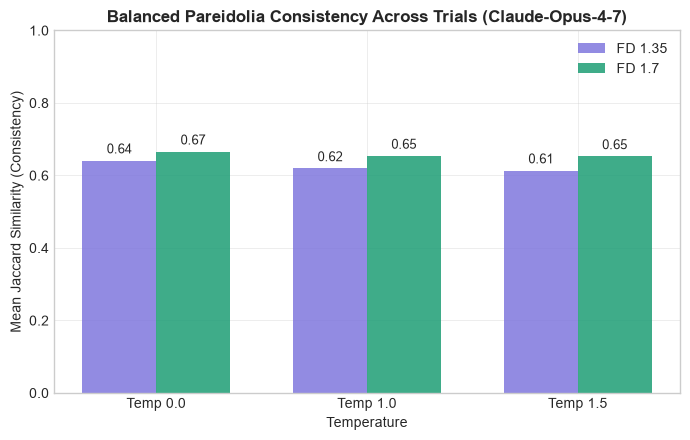

In [83]:
import json
from itertools import combinations
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

MODEL_NAME = "Claude-Opus-4-7"
RESULTS_DIR = Path("results")
main_file = RESULTS_DIR / MODEL_NAME / "main_results.jsonl"
REQUIRED_TEMPS = {0.0, 1.0, 1.5}
MIN_RUNS_PER_TEMP = 2

main_records = []
if main_file.exists():
    with open(main_file, "r", encoding="utf-8") as f:
        for line in f:
            if line.strip():
                try:
                    main_records.append(json.loads(line))
                except json.JSONDecodeError:
                    pass

df_main = pd.DataFrame(main_records)


def extract_fd(filename):
    if "1.35" in str(filename):
        return "FD1.35"
    if "1.7" in str(filename):
        return "FD1.7"
    return "Unknown"


def get_percept_labels(fractal_parsed):
    if isinstance(fractal_parsed, dict) and "percepts" in fractal_parsed:
        return [
            str(p.get("label", "")).lower().strip()
            for p in fractal_parsed["percepts"]
            if isinstance(p, dict) and p.get("label")
        ]
    return []


df_main["fd"] = df_main["file"].apply(extract_fd)
df_main["percept_labels"] = df_main["fractal_parsed"].apply(get_percept_labels)

# Step A: Filter ONLY images that have sufficient runs in ALL 3 temperatures
valid_files = set()
for file, file_group in df_main.groupby("file"):
    temp_counts = file_group.groupby("temperature")["run_id"].nunique()
    present_temps = set(temp_counts.index)
    if REQUIRED_TEMPS.issubset(present_temps):
        if all(temp_counts[t] >= MIN_RUNS_PER_TEMP for t in REQUIRED_TEMPS):
            valid_files.add(file)

df_filtered = df_main[df_main["file"].isin(valid_files)].copy()

print(f"Total Unique Images in Data : {df_main['file'].nunique()}")
print(f"Images Complete Across All 3 Temps: {len(valid_files)}")
print(f"Excluded Incomplete Images  : {df_main['file'].nunique() - len(valid_files)}")
print("=" * 60)


# Step B: Calculate Jaccard Consistency across trials for filtered images
def calc_image_consistency(labels_list_of_runs):
    valid_runs = [set(labels) for labels in labels_list_of_runs if labels]
    if len(valid_runs) < 2:
        return np.nan
    sims = []
    for s1, s2 in combinations(valid_runs, 2):
        union = len(s1.union(s2))
        sims.append(len(s1.intersection(s2)) / union if union > 0 else 1.0)
    return np.mean(sims) if sims else np.nan


consistency_records = []
for (temp, file), group in df_filtered.groupby(["temperature", "file"]):
    score = calc_image_consistency(group["percept_labels"].tolist())
    consistency_records.append(
        {
            "temperature": temp,
            "file": file,
            "fd": group["fd"].iloc[0],
            "consistency_score": score,
        }
    )

df_consistency = pd.DataFrame(consistency_records)

print(f"\nBALANCED PAREIDOLIA CONSISTENCY: {MODEL_NAME}")
print("=" * 60)

summary_table = (
    df_consistency.groupby(["temperature", "fd"])["consistency_score"]
    .agg(["count", "mean", "std"])
    .round(4)
)
print("\nMean Jaccard Similarity (Balanced Subset):")
print(summary_table.to_string())
print("-" * 60)

# Step C: Plot the Balanced Results (White Background)
pivot_data = (
    df_consistency.groupby(["temperature", "fd"])["consistency_score"]
    .mean()
    .unstack("fd")
)

fig, ax = plt.subplots(figsize=(7, 4.5), facecolor="white")
ax.set_facecolor("white")

temps = pivot_data.index
x = np.arange(len(temps))
width = 0.35

ax.bar(
    x - width / 2,
    pivot_data["FD1.35"],
    width,
    label="FD 1.35",
    color="#7F77DD",
    alpha=0.85,
)
ax.bar(
    x + width / 2,
    pivot_data["FD1.7"],
    width,
    label="FD 1.7",
    color="#1D9E75",
    alpha=0.85,
)

ax.set_xlabel("Temperature")
ax.set_ylabel("Mean Jaccard Similarity (Consistency)")
ax.set_title(
    f"Balanced Pareidolia Consistency Across Trials ({MODEL_NAME})",
    fontweight="bold",
)
ax.set_xticks(x)
ax.set_xticklabels([f"Temp {t}" for t in temps])
ax.set_ylim(0, 1.0)
ax.legend(frameon=False)

for i in x:
    val1 = pivot_data["FD1.35"].iloc[i]
    val2 = pivot_data["FD1.7"].iloc[i]
    ax.text(i - width / 2, val1 + 0.02, f"{val1:.2f}", ha="center", fontsize=9)
    ax.text(i + width / 2, val2 + 0.02, f"{val2:.2f}", ha="center", fontsize=9)

plt.tight_layout()
plt.show()

#### Left experiments:

In [28]:
import os
import glob
import pandas as pd
import numpy as np

# Automatic path discovery for the activity log file
target_filename = "../openrouter_activity_2026-06-27.csv"
found_path = None
search_patterns = [
    target_filename,
    f"../{target_filename}",
    f"../../{target_filename}",
    os.path.expanduser(f"~/Downloads/{target_filename}"),
    "openrouter_activity*.csv",
    "../openrouter_activity*.csv"
]

for pattern in search_patterns:
    matches = glob.glob(pattern)
    if matches:
        found_path = matches[0]
        break

if not found_path:
    raise FileNotFoundError(f"Could not find activity log file '{target_filename}'.")

TOTAL_IMAGES = 161
TEMPERATURES_COUNT = 3
RUNS_PER_IMAGE = 10
DAT_BASELINE_RUNS = 10

total_expected_runs = TOTAL_IMAGES * TEMPERATURES_COUNT * RUNS_PER_IMAGE
total_expected_calls = (total_expected_runs * 2) + (TEMPERATURES_COUNT * DAT_BASELINE_RUNS)

df_act = pd.read_csv(found_path)

# Filter records specifically for Claude 4.7 Opus in Fractal Pipeline
claude_mask = (df_act['model_permaslug'].str.contains('claude-4.7-opus', case=False, na=False)) & \
              (df_act['app_name'] == 'Fractal Pareidolia Pipeline')
df_claude = df_act[claude_mask].copy()

total_completed_calls = len(df_claude)
total_prompt_tokens = df_claude['tokens_prompt'].sum()
total_completion_tokens = df_claude['tokens_completion'].sum()
total_tokens = total_prompt_tokens + total_completion_tokens
total_cost = df_claude['cost_total'].sum()

mean_prompt_per_call = df_claude['tokens_prompt'].mean()
mean_comp_per_call = df_claude['tokens_completion'].mean()
mean_cost_per_call = df_claude['cost_total'].mean()

missing_calls = max(0, total_expected_calls - total_completed_calls)
missing_runs = missing_calls // 2

est_missing_prompt_tokens = int(missing_calls * mean_prompt_per_call)
est_missing_comp_tokens = int(missing_calls * mean_comp_per_call)
est_missing_total_tokens = est_missing_prompt_tokens + est_missing_comp_tokens
est_missing_cost = missing_calls * mean_cost_per_call

print("=" * 65)
print("TOKEN USAGE & BUDGET ESTIMATION (Claude-Opus-4-7)")
print("=" * 65)
print(f"Total Completed API Calls     : {total_completed_calls:,}")
print(f"Total Prompt Tokens Used      : {total_prompt_tokens:,}")
print(f"Total Completion Tokens Used  : {total_completion_tokens:,}")
print(f"Total Tokens Consumed         : {total_tokens:,}")
print(f"Total Cost Spent              : ${total_cost:,.2f}")
print("-" * 65)
print(f"Mean Prompt Tokens / Call     : {mean_prompt_per_call:,.1f}")
print(f"Mean Completion Tokens / Call : {mean_comp_per_call:,.1f}")
print(f"Mean Cost / Call              : ${mean_cost_per_call:,.4f}")
print(f"Mean Cost / Full Run (2 calls): ${mean_cost_per_call * 2:,.4f}")
print("-" * 65)
print(f"Total Expected API Calls      : {total_expected_calls:,}")
print(f"Remaining Missing Calls       : {missing_calls:,} (~{missing_runs} runs)")
print(f"Completion Rate               : {(total_completed_calls / total_expected_calls) * 100:.2f}%")
print(f"Estimated Missing Tokens      : {est_missing_total_tokens:,}")
print(f"Estimated Cost to Complete    : ${est_missing_cost:,.2f}")
print("=" * 65)

TOKEN USAGE & BUDGET ESTIMATION (Claude-Opus-4-7)
Total Completed API Calls     : 9,686
Total Prompt Tokens Used      : 18,224,304
Total Completion Tokens Used  : 1,248,924
Total Tokens Consumed         : 19,473,228
Total Cost Spent              : $122.34
-----------------------------------------------------------------
Mean Prompt Tokens / Call     : 1,881.5
Mean Completion Tokens / Call : 128.9
Mean Cost / Call              : $0.0126
Mean Cost / Full Run (2 calls): $0.0253
-----------------------------------------------------------------
Total Expected API Calls      : 9,690
Remaining Missing Calls       : 4 (~2 runs)
Completion Rate               : 99.96%
Estimated Missing Tokens      : 8,041
Estimated Cost to Complete    : $0.05


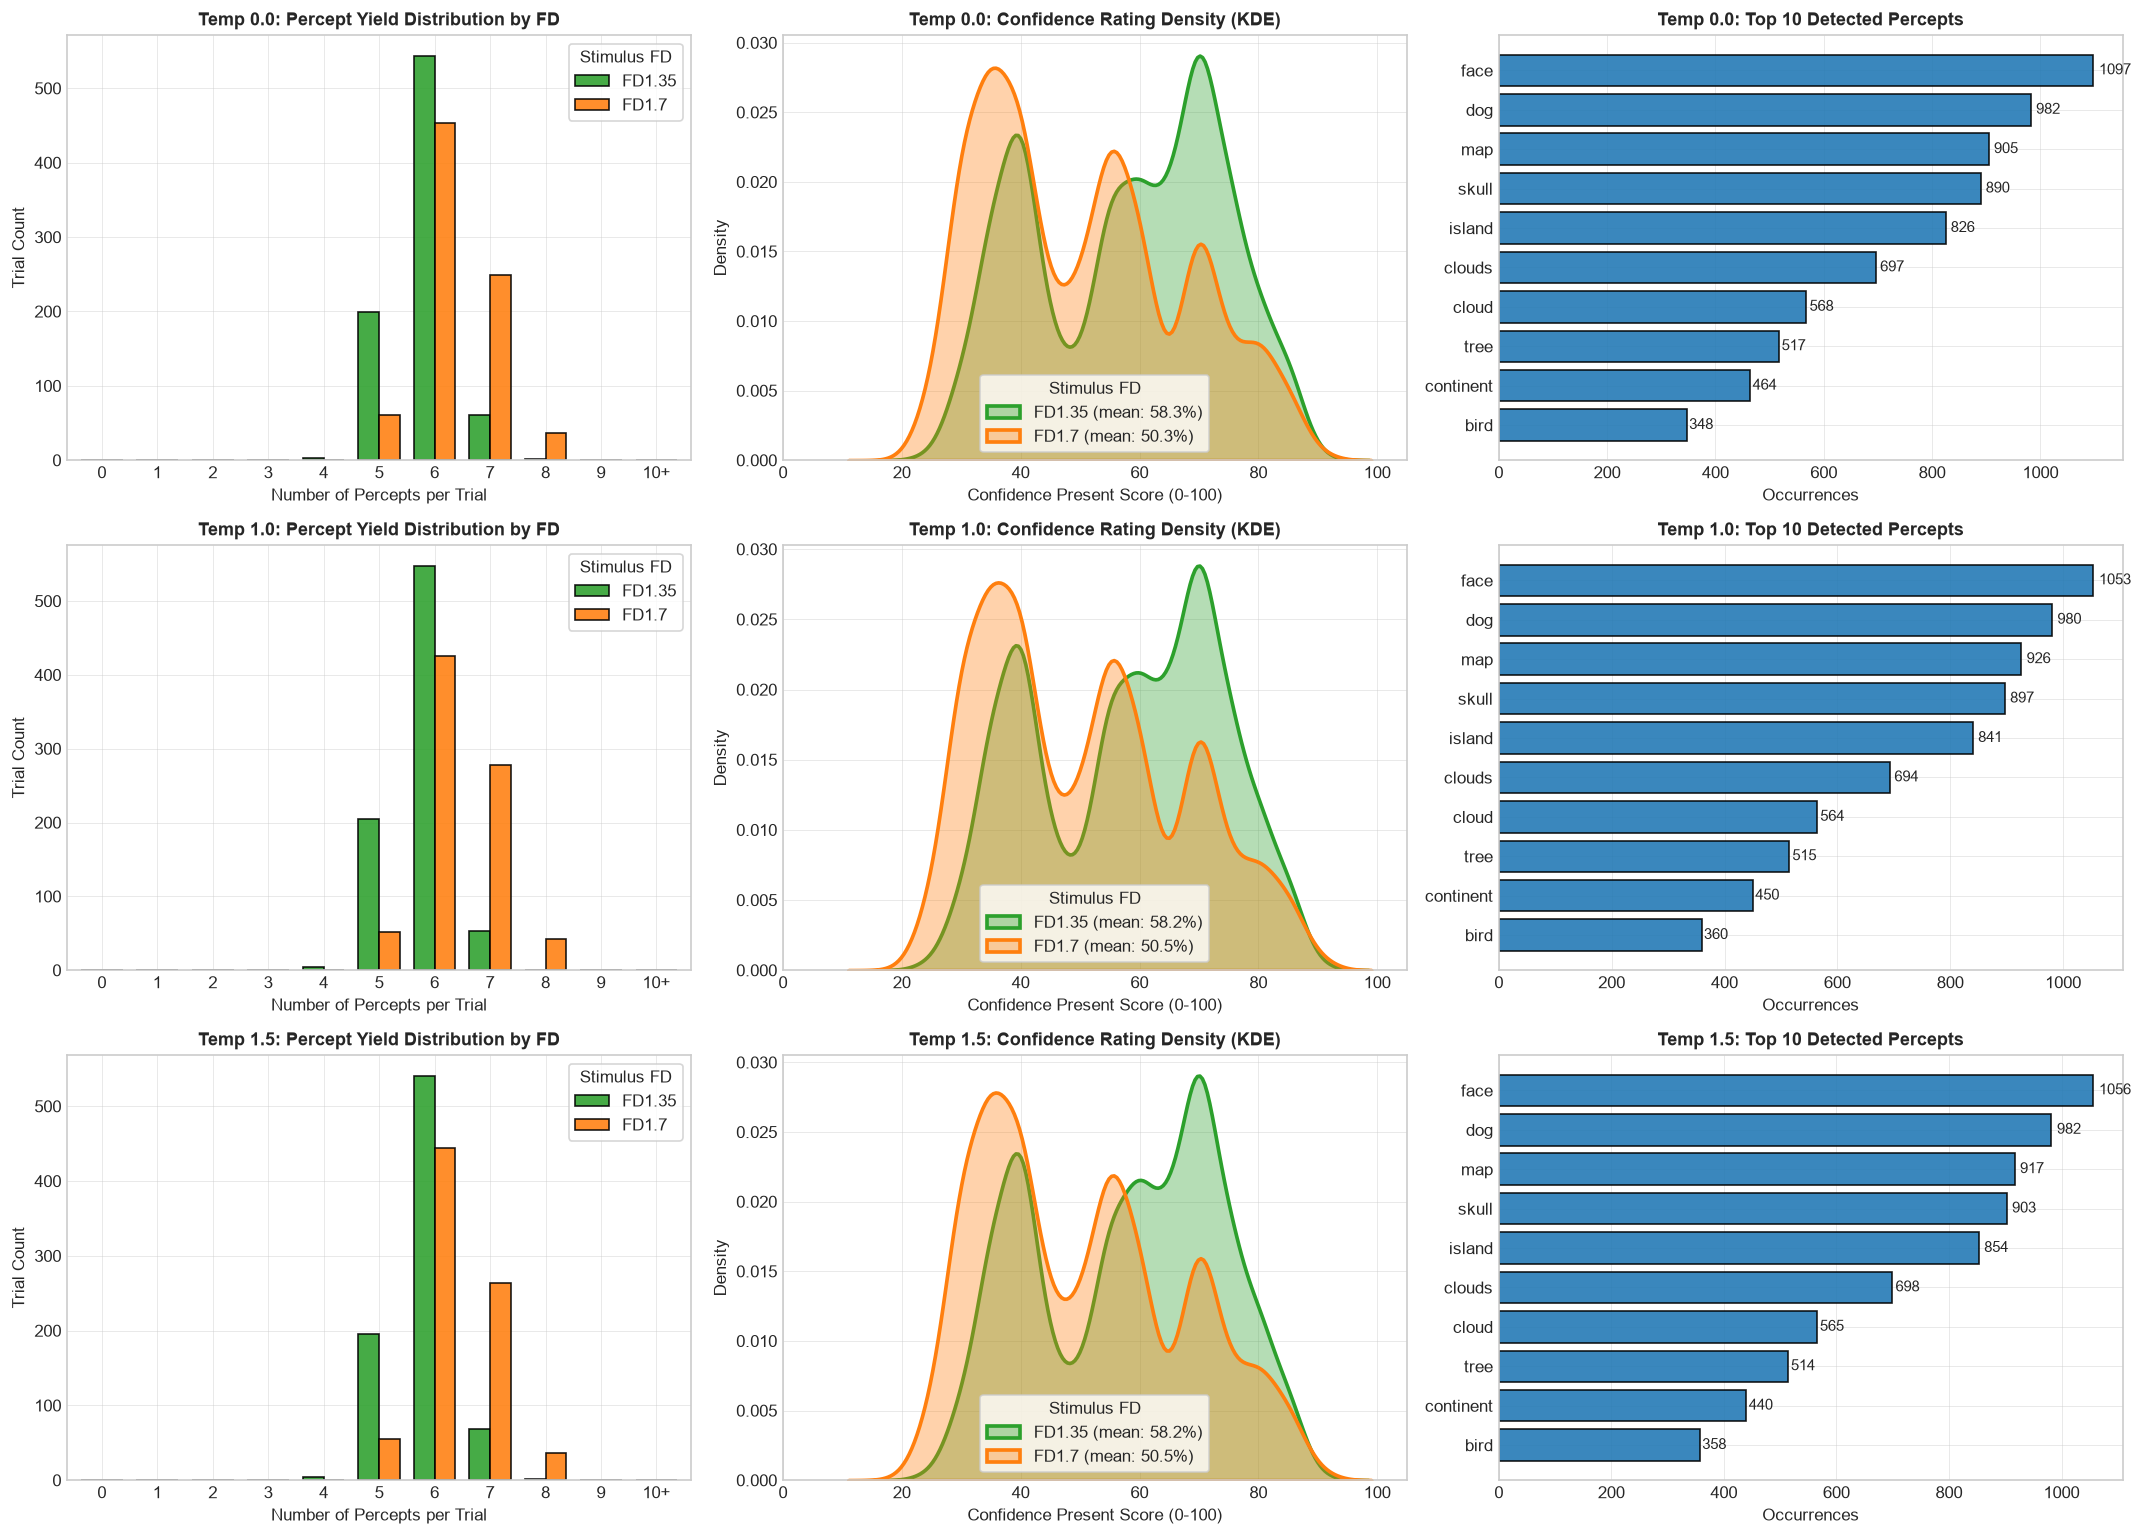

In [84]:
import json
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter

MODEL_NAME = "Claude-Opus-4-7"
RESULTS_DIR = Path("results") / MODEL_NAME
main_file = RESULTS_DIR / "main_results.jsonl"

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

main_records = []
if main_file.exists():
    with open(main_file, 'r', encoding='utf-8') as f:
        for line in f:
            if line.strip():
                try:
                    main_records.append(json.loads(line))
                except json.JSONDecodeError:
                    pass

df_main = pd.DataFrame(main_records)

if df_main.empty:
    raise ValueError(f"No records found in {main_file}")

def extract_fd(filename):
    if '1.35' in str(filename): return 'FD1.35'
    if '1.7' in str(filename): return 'FD1.7'
    return 'Unknown'

def safe_parse_confidence(val):
    if val is None:
        return None
    if isinstance(val, (int, float)):
        return float(val)
    if isinstance(val, str):
        match = re.search(r"[-+]?\d*\.?\d+", val)
        if match:
            try:
                return float(match.group())
            except ValueError:
                return None
    return None

def extract_percept_details(row):
    parsed = row.get('fractal_parsed') or row.get('image_parsed') or {}
    labels = []
    confs = []
    if isinstance(parsed, dict) and 'percepts' in parsed:
        for p in parsed['percepts']:
            if isinstance(p, dict):
                lbl = str(p.get('label', '')).lower().strip()
                if lbl:
                    labels.append(lbl)
                c_val = safe_parse_confidence(p.get('confidence_present'))
                if c_val is not None:
                    confs.append(c_val)
    return labels, confs

df_main['fd'] = df_main['file'].apply(extract_fd)
extracted = df_main.apply(extract_percept_details, axis=1)
df_main['percept_labels'] = [x[0] for x in extracted]
df_main['confidence_list'] = [x[1] for x in extracted]
df_main['percept_count'] = df_main['percept_labels'].apply(len)

MAX_DISPLAY_PERCEPTS = 10
def bin_percept_count(cnt):
    if cnt >= MAX_DISPLAY_PERCEPTS:
        return f"{MAX_DISPLAY_PERCEPTS}+"
    return str(cnt)

df_main['percept_count_binned'] = df_main['percept_count'].apply(bin_percept_count)
bin_order = [str(i) for i in range(MAX_DISPLAY_PERCEPTS)] + [f"{MAX_DISPLAY_PERCEPTS}+"]

temperatures = sorted(df_main['temperature'].dropna().unique())
fd_colors = {'FD1.35': '#2ca02c', 'FD1.7': '#ff7f0e'}

fig, axes = plt.subplots(len(temperatures), 3, figsize=(18, 4.3 * len(temperatures)), dpi=120)

for r, temp in enumerate(temperatures):
    df_temp = df_main[df_main['temperature'] == temp]

    # -------------------------------------------------------------
    # Panel 1: Percept Yield by FD (Binned with 10+)
    # -------------------------------------------------------------
    ax_count = axes[r, 0] if len(temperatures) > 1 else axes[0]
    yield_data = df_temp.groupby(['percept_count_binned', 'fd']).size().unstack(fill_value=0)
    yield_data = yield_data.reindex(bin_order, fill_value=0)
    for fd_col in ['FD1.35', 'FD1.7']:
        if fd_col not in yield_data.columns:
            yield_data[fd_col] = 0

    yield_data[['FD1.35', 'FD1.7']].plot(
        kind='bar',
        ax=ax_count,
        color=[fd_colors['FD1.35'], fd_colors['FD1.7']],
        edgecolor='black',
        alpha=0.88,
        width=0.75
    )
    ax_count.set_title(f"Temp {temp}: Percept Yield Distribution by FD", fontsize=11, fontweight='bold')
    ax_count.set_xlabel("Number of Percepts per Trial", fontsize=10)
    ax_count.set_ylabel("Trial Count", fontsize=10)
    ax_count.tick_params(axis='x', rotation=0, labelsize=10)
    ax_count.legend(title="Stimulus FD", frameon=True)

    # -------------------------------------------------------------
    # Panel 2: Confidence Rating Distributions by FD (KDE Density)
    # -------------------------------------------------------------
    ax_conf = axes[r, 1] if len(temperatures) > 1 else axes[1]
    has_density = False
    for fd_cat in ['FD1.35', 'FD1.7']:
        sub_fd = df_temp[df_temp['fd'] == fd_cat]
        confs = [c for clist in sub_fd['confidence_list'] for c in clist]
        if len(confs) > 1 and np.var(confs) > 0:
            sns.kdeplot(
                confs,
                ax=ax_conf,
                color=fd_colors[fd_cat],
                label=f"{fd_cat} (mean: {np.mean(confs):.1f}%)",
                linewidth=2.2,
                fill=True,
                alpha=0.35,
                clip=(0, 100)
            )
            has_density = True
        elif confs:
            ax_conf.axvline(np.mean(confs), color=fd_colors[fd_cat], linestyle='--', linewidth=2, label=f"{fd_cat} (mean: {np.mean(confs):.1f}%)")
            has_density = True

    ax_conf.set_title(f"Temp {temp}: Confidence Rating Density (KDE)", fontsize=11, fontweight='bold')
    ax_conf.set_xlabel("Confidence Present Score (0-100)", fontsize=10)
    ax_conf.set_ylabel("Density", fontsize=10)
    ax_conf.set_xlim(0, 105)
    if has_density:
        ax_conf.legend(title="Stimulus FD", frameon=True)

    # -------------------------------------------------------------
    # Panel 3: Top 10 Percept Labels Discovered
    # -------------------------------------------------------------
    ax_labels = axes[r, 2] if len(temperatures) > 1 else axes[2]
    all_temp_labels = [lbl for labels in df_temp['percept_labels'] for lbl in labels]
    top_labels = pd.DataFrame(Counter(all_temp_labels).most_common(10), columns=['Label', 'Count'])

    if not top_labels.empty:
        ax_labels.barh(top_labels['Label'][::-1], top_labels['Count'][::-1], color='#1f77b4', edgecolor='black', alpha=0.88)
        for idx, row in enumerate(top_labels.iloc[::-1].itertuples()):
            ax_labels.text(row.Count + max(0.5, row.Count * 0.01), idx, f"{row.Count}", va='center', fontsize=9)
    ax_labels.set_title(f"Temp {temp}: Top 10 Detected Percepts", fontsize=11, fontweight='bold')
    ax_labels.set_xlabel("Occurrences", fontsize=10)

plt.tight_layout()
plt.show()

## 2.3 Gemma3-26b

#### Example:

Step 1: Execution Profile for Gemma3-26b
File: FD_1.35_0.png | Temp: 0.0 | Run: 1


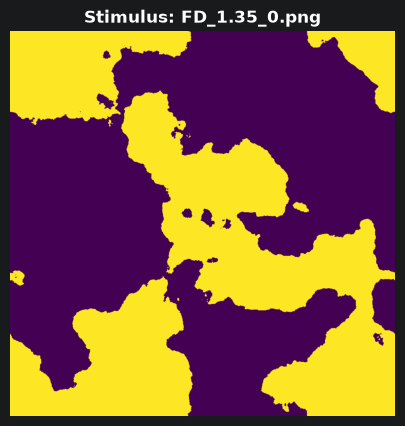


>>> PHASE 1: BASELINE DAT (CONTROL)
[PROMPT]:
Please name 10 words that are as different from each other as possible, in all ways and meanings you can imagine.

Rules:
- Only single words.
- Only nouns (e.g. things, concepts, objects). No verbs, adjectives, or other parts of speech.
- No proper nouns (no specific people, places, or brands).
- No specialized vocabulary, technical jargon, or obscure words.
- Think about different categories, contexts, domains, and properties.

Respond with a JSON object:
{
  "words": ["word1", "word2", "word3", "word4", "word5", "word6", "word7", "word8", "word9", "word10"]
}

[MODEL OUTPUT]:
{
  "words": [
    "justice",
    "cloud",
    "hammer",
    "silence",
    "ocean",
    "idea",
    "bread",
    "gravity",
    "velvet",
    "memory"
  ]
}

>>> PHASE 2 - TURN 1: FRACTAL PAREIDOLIA
[PROMPT]:
Look closely at this image. Do you see any shapes, faces, objects, animals, or patterns in it?

Please list everything you can perceive, even if faint or amb

In [30]:
import json
import matplotlib.pyplot as plt
from matplotlib.image import imread

main_data = None
if main_file.exists():
    with open(main_file, "r", encoding="utf-8") as f:
        for line in f:
            if line.strip():
                try:
                    main_data = json.loads(line)
                    break
                except json.JSONDecodeError:
                    pass

if main_data:
    target_temp = main_data.get('temperature')
    target_run = main_data.get('run_id')
    img_filename = main_data.get('file')

    baseline_data = None
    if baseline_file.exists():
        with open(baseline_file, "r", encoding="utf-8") as f:
            for line in f:
                if line.strip():
                    try:
                        b_data = json.loads(line)
                        if b_data.get('temperature') == target_temp and b_data.get('run_id') == target_run:
                            baseline_data = b_data
                            break
                    except json.JSONDecodeError:
                        pass

    img_path = None
    for d in IMAGE_DIRS:
        p = d / img_filename
        if p.exists():
            img_path = p
            break

    print(f"Step 1: Execution Profile for {MODEL_NAME}")
    print(f"File: {img_filename} | Temp: {target_temp} | Run: {target_run}")

    if img_path:
        plt.figure(figsize=(5, 5))
        img = imread(img_path)
        plt.imshow(img)
        plt.axis('off')
        plt.title(f"Stimulus: {img_filename}", fontweight='bold')
        plt.show()
    else:
        print(f"\n[IMAGE NOT FOUND: {img_filename}]")

    print("\n" + "="*80)
    print(">>> PHASE 1: BASELINE DAT (CONTROL)")
    print("="*80)
    print("[PROMPT]:")
    print(DAT_PROMPT.strip())
    print("\n[MODEL OUTPUT]:")
    if baseline_data and baseline_data.get('dat_parsed'):
        print(json.dumps(baseline_data['dat_parsed'], indent=2))
    else:
        print("No baseline data found for this exact run.")

    print("\n" + "="*80)
    print(">>> PHASE 2 - TURN 1: FRACTAL PAREIDOLIA")
    print("="*80)
    print("[PROMPT]:")
    print(FRACTAL_PROMPT.strip() + f"\n[ATTACHED IMAGE: {img_filename}]")
    print("\n[MODEL OUTPUT]:")
    fp = main_data.get('fractal_parsed') or {}
    print(json.dumps(fp, indent=2))

    print("\n" + "="*80)
    print(">>> PHASE 2 - TURN 2: PRIMED DAT (SAME THREAD)")
    print("="*80)
    print("[PROMPT]:")
    print(DAT_PROMPT.strip())
    print("\n[MODEL OUTPUT]:")
    dp = main_data.get('dat_parsed') or {}
    print(json.dumps(dp, indent=2))
    print("="*80 + "\n")
else:
    print(f"No records found in {main_file}")

#### Experiment Analysis:

In [31]:
import json
from pathlib import Path

MODEL_NAME = "Gemma3-26b"
RESULTS_DIR = Path("results")
IMAGE_DIRS = [Path("new-FD-images/FD135"), Path("new-FD-images/FD17")]
TEMPERATURES = [0.0, 1.0, 1.5]
NUM_RUNS = 10

images = []
for d in IMAGE_DIRS:
    if d.exists():
        images.extend(d.glob("*.png"))
        images.extend(d.glob("*.jpg"))

expected_combos = set((temp, img.name, run_id) for img in images for temp in TEMPERATURES for run_id in range(1, NUM_RUNS + 1))

main_file = RESULTS_DIR / MODEL_NAME / "main_results.jsonl"
completed_combos = set()

if main_file.exists():
    with open(main_file, "r", encoding="utf-8") as f:
        for line in f:
            if not line.strip():
                continue
            try:
                data = json.loads(line)
                if 'temperature' in data and 'file' in data and 'run_id' in data:
                    completed_combos.add((data['temperature'], data['file'], data['run_id']))
            except json.JSONDecodeError:
                pass

missing_combos = expected_combos - completed_combos

print(f"Step 2: Execution Progress for {MODEL_NAME}")
print("="*50)
print(f"Total Images Found    : {len(images)}")
print(f"Expected Runs (Total) : {len(expected_combos)}")
print(f"Completed Runs        : {len(completed_combos)}")
print(f"Missing Runs          : {len(missing_combos)}")
percentage = (len(completed_combos) / len(expected_combos)) * 100 if expected_combos else 0
print(f"Completion Rate       : {percentage:.2f}%")
print("="*50)

if missing_combos:
    print("\nSample of missing runs (showing up to 5):")
    for m in list(missing_combos)[:5]:
        print(f"- Temp: {m[0]} | File: {m[1]} | Run ID: {m[2]}")
else:
    print("\nAll expected runs are 100% completed!")

Step 2: Execution Progress for Gemma3-26b
Total Images Found    : 161
Expected Runs (Total) : 4830
Completed Runs        : 4830
Missing Runs          : 0
Completion Rate       : 100.00%

All expected runs are 100% completed!


#### Vocab Analysis:

In [32]:
import json
import numpy as np
import pandas as pd
from pathlib import Path
from collections import Counter
from scipy.stats import entropy

MODEL_NAME = "Gemma3-26b"
RESULTS_DIR = Path("results")

main_file = RESULTS_DIR / MODEL_NAME / "main_results.jsonl"
base_file = RESULTS_DIR / MODEL_NAME / "dat_baseline_results.jsonl"

main_records = []
if main_file.exists():
    with open(main_file, 'r', encoding='utf-8') as f:
        for line in f:
            if line.strip():
                try:
                    main_records.append(json.loads(line))
                except json.JSONDecodeError:
                    pass

base_records = []
if base_file.exists():
    with open(base_file, 'r', encoding='utf-8') as f:
        for line in f:
            if line.strip():
                try:
                    base_records.append(json.loads(line))
                except json.JSONDecodeError:
                    pass

df_main = pd.DataFrame(main_records)
df_base = pd.DataFrame(base_records)

def extract_fd(filename):
    if '1.35' in str(filename): return 'FD1.35'
    if '1.7' in str(filename): return 'FD1.7'
    return 'Unknown'

def get_dat_words(dat_parsed):
    if isinstance(dat_parsed, dict) and 'words' in dat_parsed:
        return [str(w).lower().strip() for w in dat_parsed['words'] if str(w).strip()]
    return []

def get_mean_confidence(fractal_parsed):
    if isinstance(fractal_parsed, dict) and 'percepts' in fractal_parsed:
        confs = [p.get('confidence_present', 0) for p in fractal_parsed['percepts'] if isinstance(p, dict)]
        if confs: return np.mean(confs)
    return np.nan

def calc_ttr(words):
    return len(set(words)) / len(words) if words else 0.0

def calc_entropy(words):
    if not words: return 0.0
    counts = list(Counter(words).values())
    probs = np.array(counts) / sum(counts)
    return entropy(probs)

if not df_main.empty:
    df_main['fd'] = df_main['file'].apply(extract_fd)
    df_main['dat_words'] = df_main['dat_parsed'].apply(get_dat_words)
    df_main['mean_confidence'] = df_main['fractal_parsed'].apply(get_mean_confidence)

    df_main['total_words'] = df_main['dat_words'].apply(len)
    df_main['unique_words'] = df_main['dat_words'].apply(lambda x: len(set(x)))
    df_main['ttr'] = df_main['dat_words'].apply(calc_ttr)
    df_main['repetition_rate'] = 1.0 - df_main['ttr']
    df_main['entropy'] = df_main['dat_words'].apply(calc_entropy)

    df_base['dat_words'] = df_base['dat_parsed'].apply(get_dat_words)
    baseline_vocab_by_temp = {}
    if not df_base.empty and 'temperature' in df_base.columns:
        for temp, group in df_base.groupby('temperature'):
            baseline_vocab_by_temp[temp] = set([w for words in group['dat_words'] for w in words])

    def calc_novel_ratio(row):
        temp = row.get('temperature')
        words = row.get('dat_words', [])
        if not words or temp not in baseline_vocab_by_temp: return 0.0
        base_vocab = baseline_vocab_by_temp[temp]
        novel_words = [w for w in words if w not in base_vocab]
        return len(novel_words) / len(words)

    df_main['novel_word_prop'] = df_main.apply(calc_novel_ratio, axis=1)

    print("="*75)
    print(f"VOCABULARY & DIVERSITY ANALYSIS: {MODEL_NAME}")
    print("="*75)

    print("\n1. EFFECT OF FD ON VOCABULARY SIZE (Overall Unique Words):")
    for fd, grp in df_main.groupby('fd'):
        unique_words_count = len(set([w for words in grp['dat_words'] for w in words]))
        print(f"  - {fd:<7}: {unique_words_count} unique words")

    print("\n2. MEAN CONFIDENCE LEVELS BY TEMPERATURE:")
    mean_conf = df_main.groupby('temperature')['mean_confidence'].mean()
    for t, val in mean_conf.items():
        print(f"  - Temp {t}: {val:.2f}%")

    print("\n3. WORD DIVERSITY METRICS (Averaged across runs):")
    div_metrics = ['total_words', 'ttr', 'repetition_rate', 'novel_word_prop', 'entropy']
    diversity_summary = df_main.groupby('temperature')[div_metrics].mean()
    print(diversity_summary.round(4).to_string())
    print("="*75)
else:
    print(f"No records available in {main_file} to analyze.")

VOCABULARY & DIVERSITY ANALYSIS: Gemma3-26b

1. EFFECT OF FD ON VOCABULARY SIZE (Overall Unique Words):
  - FD1.35 : 279 unique words
  - FD1.7  : 267 unique words

2. MEAN CONFIDENCE LEVELS BY TEMPERATURE:
  - Temp 0.0: 76.09%
  - Temp 1.0: 67.65%
  - Temp 1.5: 65.91%

3. WORD DIVERSITY METRICS (Averaged across runs):
             total_words     ttr  repetition_rate  novel_word_prop  entropy
temperature                                                                
0.0              10.0000  1.0000           0.0000           0.3834   2.3026
1.0              10.0000  1.0000           0.0000           0.2673   2.3026
1.5               9.9807  0.9981           0.0019           0.3670   2.2982


#### Perception Analysis:

PAREIDOLIA CONSISTENCY ANALYSIS: Gemma3-26b

Mean Jaccard Similarity across Trials:
                    count    mean     std
temperature fd                           
0.0         FD1.35     17  0.7445  0.2465
            FD1.7      15  0.8628  0.1626
1.0         FD1.35     48  0.4325  0.2749
            FD1.7      33  0.6634  0.2744
1.5         FD1.35     62  0.3389  0.2774
            FD1.7      54  0.5455  0.2654
-----------------------------------------------------------------


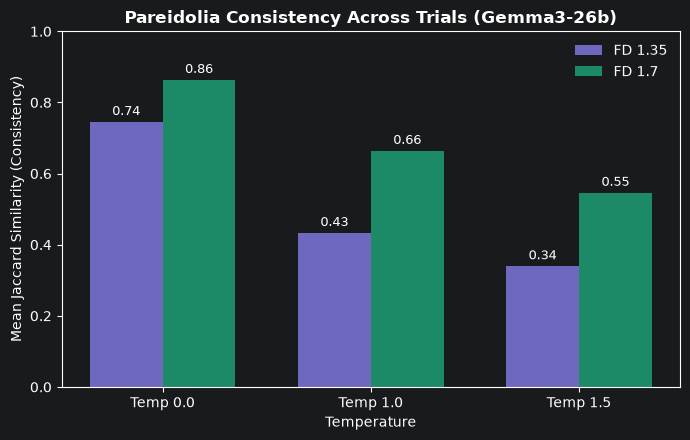

In [33]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from itertools import combinations

MODEL_NAME = "Gemma3-26b"
RESULTS_DIR = Path("results")
main_file = RESULTS_DIR / MODEL_NAME / "main_results.jsonl"

main_records = []
if main_file.exists():
    with open(main_file, 'r', encoding='utf-8') as f:
        for line in f:
            if line.strip():
                try:
                    main_records.append(json.loads(line))
                except json.JSONDecodeError:
                    pass

df_main = pd.DataFrame(main_records)

def extract_fd(filename):
    if '1.35' in str(filename): return 'FD1.35'
    if '1.7' in str(filename): return 'FD1.7'
    return 'Unknown'

def get_percept_labels(fractal_parsed):
    if isinstance(fractal_parsed, dict) and 'percepts' in fractal_parsed:
        return [str(p.get('label', '')).lower().strip() for p in fractal_parsed['percepts'] if isinstance(p, dict) and p.get('label')]
    return []

if not df_main.empty:
    df_main['fd'] = df_main['file'].apply(extract_fd)
    df_main['percept_labels'] = df_main['fractal_parsed'].apply(get_percept_labels)

    def calc_image_consistency(labels_list_of_runs):
        valid_runs = [set(labels) for labels in labels_list_of_runs if labels]
        if len(valid_runs) < 2:
            return np.nan
        sims = []
        for s1, s2 in combinations(valid_runs, 2):
            union = len(s1.union(s2))
            sims.append(len(s1.intersection(s2)) / union if union > 0 else 1.0)
        return np.mean(sims) if sims else np.nan

    consistency_records = []
    for (temp, file), group in df_main.groupby(['temperature', 'file']):
        score = calc_image_consistency(group['percept_labels'].tolist())
        consistency_records.append({
            'temperature': temp,
            'file': file,
            'fd': group['fd'].iloc[0],
            'consistency_score': score
        })

    df_consistency = pd.DataFrame(consistency_records)

    print("=" * 65)
    print(f"PAREIDOLIA CONSISTENCY ANALYSIS: {MODEL_NAME}")
    print("=" * 65)

    summary_table = df_consistency.groupby(['temperature', 'fd'])['consistency_score'].agg(['count', 'mean', 'std']).round(4)
    print("\nMean Jaccard Similarity across Trials:")
    print(summary_table.to_string())
    print("-" * 65)

    pivot_data = df_consistency.groupby(['temperature', 'fd'])['consistency_score'].mean().unstack('fd')

    fig, ax = plt.subplots(figsize=(7, 4.5))
    temps = pivot_data.index
    x = np.arange(len(temps))
    width = 0.35

    if 'FD1.35' in pivot_data.columns:
        ax.bar(x - width/2, pivot_data['FD1.35'], width, label='FD 1.35', color='#7F77DD', alpha=0.85)
    if 'FD1.7' in pivot_data.columns:
        ax.bar(x + width/2, pivot_data['FD1.7'], width, label='FD 1.7', color='#1D9E75', alpha=0.85)

    ax.set_xlabel('Temperature')
    ax.set_ylabel('Mean Jaccard Similarity (Consistency)')
    ax.set_title(f'Pareidolia Consistency Across Trials ({MODEL_NAME})', fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels([f"Temp {t}" for t in temps])
    ax.set_ylim(0, 1.0)
    ax.legend(frameon=False)

    for i in x:
        if 'FD1.35' in pivot_data.columns and not np.isnan(pivot_data['FD1.35'].iloc[i]):
            val1 = pivot_data['FD1.35'].iloc[i]
            ax.text(i - width/2, val1 + 0.02, f"{val1:.2f}", ha='center', fontsize=9)
        if 'FD1.7' in pivot_data.columns and not np.isnan(pivot_data['FD1.7'].iloc[i]):
            val2 = pivot_data['FD1.7'].iloc[i]
            ax.text(i + width/2, val2 + 0.02, f"{val2:.2f}", ha='center', fontsize=9)

    plt.tight_layout()
    plt.show()
else:
    print(f"No records available in {main_file} to analyze.")

PAREIDOLIA CONSISTENCY ANALYSIS: Gemma3-26b

Mean Jaccard Similarity across Trials:
                    count    mean     std
temperature fd                           
0.0         FD1.35     17  0.7445  0.2465
            FD1.7      15  0.8628  0.1626
1.0         FD1.35     48  0.4325  0.2749
            FD1.7      33  0.6634  0.2744
1.5         FD1.35     62  0.3389  0.2774
            FD1.7      54  0.5455  0.2654
-----------------------------------------------------------------


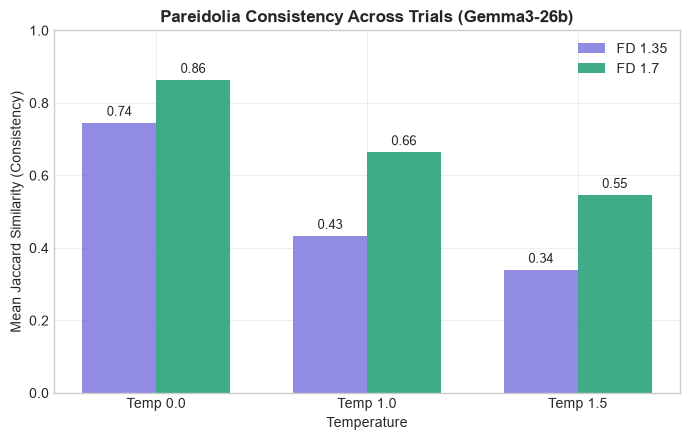

In [85]:
import json
from itertools import combinations
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

MODEL_NAME = "Gemma3-26b"
RESULTS_DIR = Path("results")
main_file = RESULTS_DIR / MODEL_NAME / "main_results.jsonl"

main_records = []
if main_file.exists():
    with open(main_file, "r", encoding="utf-8") as f:
        for line in f:
            if line.strip():
                try:
                    main_records.append(json.loads(line))
                except json.JSONDecodeError:
                    pass

df_main = pd.DataFrame(main_records)


def extract_fd(filename):
    if "1.35" in str(filename):
        return "FD1.35"
    if "1.7" in str(filename):
        return "FD1.7"
    return "Unknown"


def get_percept_labels(fractal_parsed):
    if isinstance(fractal_parsed, dict) and "percepts" in fractal_parsed:
        return [
            str(p.get("label", "")).lower().strip()
            for p in fractal_parsed["percepts"]
            if isinstance(p, dict) and p.get("label")
        ]
    return []


if not df_main.empty:
    df_main["fd"] = df_main["file"].apply(extract_fd)
    df_main["percept_labels"] = df_main["fractal_parsed"].apply(
        get_percept_labels
    )

    def calc_image_consistency(labels_list_of_runs):
        valid_runs = [set(labels) for labels in labels_list_of_runs if labels]
        if len(valid_runs) < 2:
            return np.nan
        sims = []
        for s1, s2 in combinations(valid_runs, 2):
            union = len(s1.union(s2))
            sims.append(len(s1.intersection(s2)) / union if union > 0 else 1.0)
        return np.mean(sims) if sims else np.nan

    consistency_records = []
    for (temp, file), group in df_main.groupby(["temperature", "file"]):
        score = calc_image_consistency(group["percept_labels"].tolist())
        consistency_records.append(
            {
                "temperature": temp,
                "file": file,
                "fd": group["fd"].iloc[0],
                "consistency_score": score,
            }
        )

    df_consistency = pd.DataFrame(consistency_records)

    print("=" * 65)
    print(f"PAREIDOLIA CONSISTENCY ANALYSIS: {MODEL_NAME}")
    print("=" * 65)

    summary_table = (
        df_consistency.groupby(["temperature", "fd"])["consistency_score"]
        .agg(["count", "mean", "std"])
        .round(4)
    )
    print("\nMean Jaccard Similarity across Trials:")
    print(summary_table.to_string())
    print("-" * 65)

    pivot_data = (
        df_consistency.groupby(["temperature", "fd"])["consistency_score"]
        .mean()
        .unstack("fd")
    )

    # ایجاد نمودار با پس‌زمینه کاملاً سفید
    fig, ax = plt.subplots(figsize=(7, 4.5), facecolor="white")
    ax.set_facecolor("white")

    temps = pivot_data.index
    x = np.arange(len(temps))
    width = 0.35

    if "FD1.35" in pivot_data.columns:
        ax.bar(
            x - width / 2,
            pivot_data["FD1.35"],
            width,
            label="FD 1.35",
            color="#7F77DD",
            alpha=0.85,
        )
    if "FD1.7" in pivot_data.columns:
        ax.bar(
            x + width / 2,
            pivot_data["FD1.7"],
            width,
            label="FD 1.7",
            color="#1D9E75",
            alpha=0.85,
        )

    ax.set_xlabel("Temperature")
    ax.set_ylabel("Mean Jaccard Similarity (Consistency)")
    ax.set_title(
        f"Pareidolia Consistency Across Trials ({MODEL_NAME})",
        fontweight="bold",
    )
    ax.set_xticks(x)
    ax.set_xticklabels([f"Temp {t}" for t in temps])
    ax.set_ylim(0, 1.0)
    ax.legend(frameon=False)

    for i in x:
        if "FD1.35" in pivot_data.columns and not np.isnan(
            pivot_data["FD1.35"].iloc[i]
        ):
            val1 = pivot_data["FD1.35"].iloc[i]
            ax.text(
                i - width / 2, val1 + 0.02, f"{val1:.2f}", ha="center", fontsize=9
            )
        if "FD1.7" in pivot_data.columns and not np.isnan(
            pivot_data["FD1.7"].iloc[i]
        ):
            val2 = pivot_data["FD1.7"].iloc[i]
            ax.text(
                i + width / 2, val2 + 0.02, f"{val2:.2f}", ha="center", fontsize=9
            )

    plt.tight_layout()
    plt.show()
else:
    print(f"No records available in {main_file} to analyze.")

## 2.4 GPT-5.4

#### Example:

Step 1: Execution Profile for GPT-5.4
File: FD_1.35_0.png | Temp: 0.0 | Run: 1


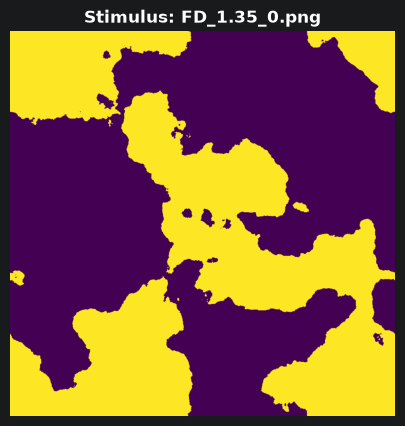


>>> PHASE 1: BASELINE DAT (CONTROL)
[PROMPT]:
Please name 10 words that are as different from each other as possible, in all ways and meanings you can imagine.

Rules:
- Only single words.
- Only nouns (e.g. things, concepts, objects). No verbs, adjectives, or other parts of speech.
- No proper nouns (no specific people, places, or brands).
- No specialized vocabulary, technical jargon, or obscure words.
- Think about different categories, contexts, domains, and properties.

Respond with a JSON object:
{
  "words": ["word1", "word2", "word3", "word4", "word5", "word6", "word7", "word8", "word9", "word10"]
}

[MODEL OUTPUT]:
{
  "words": [
    "mountain",
    "whisper",
    "justice",
    "teacup",
    "galaxy",
    "hunger",
    "blanket",
    "shadow",
    "festival",
    "pebble"
  ]
}

>>> PHASE 2 - TURN 1: FRACTAL PAREIDOLIA
[PROMPT]:
Look closely at this image. Do you see any shapes, faces, objects, animals, or patterns in it?

Please list everything you can perceive, even if fai

In [35]:
import json
import matplotlib.pyplot as plt
from matplotlib.image import imread

main_data = None
if main_file.exists():
    with open(main_file, "r", encoding="utf-8") as f:
        for line in f:
            if line.strip():
                try:
                    main_data = json.loads(line)
                    break
                except json.JSONDecodeError:
                    pass

if main_data:
    target_temp = main_data.get('temperature')
    target_run = main_data.get('run_id')
    img_filename = main_data.get('file')

    baseline_data = None
    if baseline_file.exists():
        with open(baseline_file, "r", encoding="utf-8") as f:
            for line in f:
                if line.strip():
                    try:
                        b_data = json.loads(line)
                        if b_data.get('temperature') == target_temp and b_data.get('run_id') == target_run:
                            baseline_data = b_data
                            break
                    except json.JSONDecodeError:
                        pass

    img_path = None
    for d in IMAGE_DIRS:
        p = d / img_filename
        if p.exists():
            img_path = p
            break

    print(f"Step 1: Execution Profile for {MODEL_NAME}")
    print(f"File: {img_filename} | Temp: {target_temp} | Run: {target_run}")

    if img_path:
        plt.figure(figsize=(5, 5))
        img = imread(img_path)
        plt.imshow(img)
        plt.axis('off')
        plt.title(f"Stimulus: {img_filename}", fontweight='bold')
        plt.show()
    else:
        print(f"\n[IMAGE NOT FOUND: {img_filename}]")

    print("\n" + "="*80)
    print(">>> PHASE 1: BASELINE DAT (CONTROL)")
    print("="*80)
    print("[PROMPT]:")
    print(DAT_PROMPT.strip())
    print("\n[MODEL OUTPUT]:")
    if baseline_data and baseline_data.get('dat_parsed'):
        print(json.dumps(baseline_data['dat_parsed'], indent=2))
    else:
        print("No baseline data found for this exact run.")

    print("\n" + "="*80)
    print(">>> PHASE 2 - TURN 1: FRACTAL PAREIDOLIA")
    print("="*80)
    print("[PROMPT]:")
    print(FRACTAL_PROMPT.strip() + f"\n[ATTACHED IMAGE: {img_filename}]")
    print("\n[MODEL OUTPUT]:")
    fp = main_data.get('fractal_parsed') or {}
    print(json.dumps(fp, indent=2))

    print("\n" + "="*80)
    print(">>> PHASE 2 - TURN 2: PRIMED DAT (SAME THREAD)")
    print("="*80)
    print("[PROMPT]:")
    print(DAT_PROMPT.strip())
    print("\n[MODEL OUTPUT]:")
    dp = main_data.get('dat_parsed') or {}
    print(json.dumps(dp, indent=2))
    print("="*80 + "\n")
else:
    print(f"No records found in {main_file}")

#### Experiment Analysis:

In [36]:
import json
from pathlib import Path

MODEL_NAME = "GPT-5.4"
RESULTS_DIR = Path("results")
IMAGE_DIRS = [Path("new-FD-images/FD135"), Path("new-FD-images/FD17")]
TEMPERATURES = [0.0, 1.0, 1.5]
NUM_RUNS = 10

images = []
for d in IMAGE_DIRS:
    if d.exists():
        images.extend(d.glob("*.png"))
        images.extend(d.glob("*.jpg"))

expected_combos = set((temp, img.name, run_id) for img in images for temp in TEMPERATURES for run_id in range(1, NUM_RUNS + 1))

main_file = RESULTS_DIR / MODEL_NAME / "main_results.jsonl"
completed_combos = set()

if main_file.exists():
    with open(main_file, "r", encoding="utf-8") as f:
        for line in f:
            if not line.strip():
                continue
            try:
                data = json.loads(line)
                if 'temperature' in data and 'file' in data and 'run_id' in data:
                    completed_combos.add((data['temperature'], data['file'], data['run_id']))
            except json.JSONDecodeError:
                pass

missing_combos = expected_combos - completed_combos

print(f"Step 2: Execution Progress for {MODEL_NAME}")
print("="*50)
print(f"Total Images Found    : {len(images)}")
print(f"Expected Runs (Total) : {len(expected_combos)}")
print(f"Completed Runs        : {len(completed_combos)}")
print(f"Missing Runs          : {len(missing_combos)}")
percentage = (len(completed_combos) / len(expected_combos)) * 100 if expected_combos else 0
print(f"Completion Rate       : {percentage:.2f}%")
print("="*50)

if missing_combos:
    print("\nSample of missing runs (showing up to 5):")
    for m in list(missing_combos)[:5]:
        print(f"- Temp: {m[0]} | File: {m[1]} | Run ID: {m[2]}")
else:
    print("\nAll expected runs are 100% completed!")

Step 2: Execution Progress for GPT-5.4
Total Images Found    : 161
Expected Runs (Total) : 4830
Completed Runs        : 4612
Missing Runs          : 218
Completion Rate       : 95.49%

Sample of missing runs (showing up to 5):
- Temp: 1.0 | File: FD_1.35_80.png | Run ID: 9
- Temp: 1.0 | File: FD_1.35_8.png | Run ID: 4
- Temp: 1.0 | File: FD_1.35_71.png | Run ID: 5
- Temp: 1.0 | File: FD_1.7_11.png | Run ID: 3
- Temp: 1.0 | File: FD_1.7_13.png | Run ID: 9


#### Vocab Analysis:

In [38]:
import json
import numpy as np
import pandas as pd
from pathlib import Path
from collections import Counter
from scipy.stats import entropy

MODEL_NAME = "GPT-5.4"
RESULTS_DIR = Path("results")

main_file = RESULTS_DIR / MODEL_NAME / "main_results.jsonl"
base_file = RESULTS_DIR / MODEL_NAME / "dat_baseline_results.jsonl"

main_records = []
if main_file.exists():
    with open(main_file, 'r', encoding='utf-8') as f:
        for line in f:
            if line.strip():
                try:
                    main_records.append(json.loads(line))
                except json.JSONDecodeError:
                    pass

base_records = []
if base_file.exists():
    with open(base_file, 'r', encoding='utf-8') as f:
        for line in f:
            if line.strip():
                try:
                    base_records.append(json.loads(line))
                except json.JSONDecodeError:
                    pass

df_main = pd.DataFrame(main_records)
df_base = pd.DataFrame(base_records)

def extract_fd(filename):
    if '1.35' in str(filename): return 'FD1.35'
    if '1.7' in str(filename): return 'FD1.7'
    return 'Unknown'

def get_dat_words(dat_parsed):
    if isinstance(dat_parsed, dict) and 'words' in dat_parsed:
        return [str(w).lower().strip() for w in dat_parsed['words'] if str(w).strip()]
    return []

def get_mean_confidence(fractal_parsed):
    if isinstance(fractal_parsed, dict) and 'percepts' in fractal_parsed:
        confs = [p.get('confidence_present', 0) for p in fractal_parsed['percepts'] if isinstance(p, dict)]
        if confs: return np.mean(confs)
    return np.nan

def calc_ttr(words):
    return len(set(words)) / len(words) if words else 0.0

def calc_entropy(words):
    if not words: return 0.0
    counts = list(Counter(words).values())
    probs = np.array(counts) / sum(counts)
    return entropy(probs)

if not df_main.empty:
    df_main['fd'] = df_main['file'].apply(extract_fd)
    df_main['dat_words'] = df_main['dat_parsed'].apply(get_dat_words)
    df_main['mean_confidence'] = df_main['fractal_parsed'].apply(get_mean_confidence)

    df_main['total_words'] = df_main['dat_words'].apply(len)
    df_main['unique_words'] = df_main['dat_words'].apply(lambda x: len(set(x)))
    df_main['ttr'] = df_main['dat_words'].apply(calc_ttr)
    df_main['repetition_rate'] = 1.0 - df_main['ttr']
    df_main['entropy'] = df_main['dat_words'].apply(calc_entropy)

    df_base['dat_words'] = df_base['dat_parsed'].apply(get_dat_words)
    baseline_vocab_by_temp = {}
    if not df_base.empty and 'temperature' in df_base.columns:
        for temp, group in df_base.groupby('temperature'):
            baseline_vocab_by_temp[temp] = set([w for words in group['dat_words'] for w in words])

    def calc_novel_ratio(row):
        temp = row.get('temperature')
        words = row.get('dat_words', [])
        if not words or temp not in baseline_vocab_by_temp: return 0.0
        base_vocab = baseline_vocab_by_temp[temp]
        novel_words = [w for w in words if w not in base_vocab]
        return len(novel_words) / len(words)

    df_main['novel_word_prop'] = df_main.apply(calc_novel_ratio, axis=1)

    print("="*75)
    print(f"VOCABULARY & DIVERSITY ANALYSIS: {MODEL_NAME}")
    print("="*75)

    print("\n1. EFFECT OF FD ON VOCABULARY SIZE (Overall Unique Words):")
    for fd, grp in df_main.groupby('fd'):
        unique_words_count = len(set([w for words in grp['dat_words'] for w in words]))
        print(f"  - {fd:<7}: {unique_words_count} unique words")

    print("\n2. MEAN CONFIDENCE LEVELS BY TEMPERATURE:")
    mean_conf = df_main.groupby('temperature')['mean_confidence'].mean()
    for t, val in mean_conf.items():
        print(f"  - Temp {t}: {val:.2f}%")

    print("\n3. WORD DIVERSITY METRICS (Averaged across runs):")
    div_metrics = ['total_words', 'ttr', 'repetition_rate', 'novel_word_prop', 'entropy']
    diversity_summary = df_main.groupby('temperature')[div_metrics].mean()
    print(diversity_summary.round(4).to_string())
    print("="*75)
else:
    print(f"No records available in {main_file} to analyze.")

VOCABULARY & DIVERSITY ANALYSIS: GPT-5.4

1. EFFECT OF FD ON VOCABULARY SIZE (Overall Unique Words):
  - FD1.35 : 168 unique words
  - FD1.7  : 178 unique words

2. MEAN CONFIDENCE LEVELS BY TEMPERATURE:
  - Temp 0.0: 54.26%
  - Temp 1.0: 54.60%
  - Temp 1.5: 54.91%

3. WORD DIVERSITY METRICS (Averaged across runs):
             total_words  ttr  repetition_rate  novel_word_prop  entropy
temperature                                                             
0.0                 10.0  1.0              0.0           0.2865   2.3026
1.0                 10.0  1.0              0.0           0.1778   2.3026
1.5                 10.0  1.0              0.0           0.1461   2.3026


#### Perception Analysis:

PAREIDOLIA CONSISTENCY ANALYSIS: GPT-5.4

Mean Jaccard Similarity across Trials:
                    count    mean     std
temperature fd                           
0.0         FD1.35     81  0.5414  0.1582
            FD1.7      80  0.7681  0.1259
1.0         FD1.35     69  0.5591  0.1425
            FD1.7      74  0.7406  0.1442
1.5         FD1.35     79  0.5427  0.1419
            FD1.7      80  0.7325  0.1339
-----------------------------------------------------------------


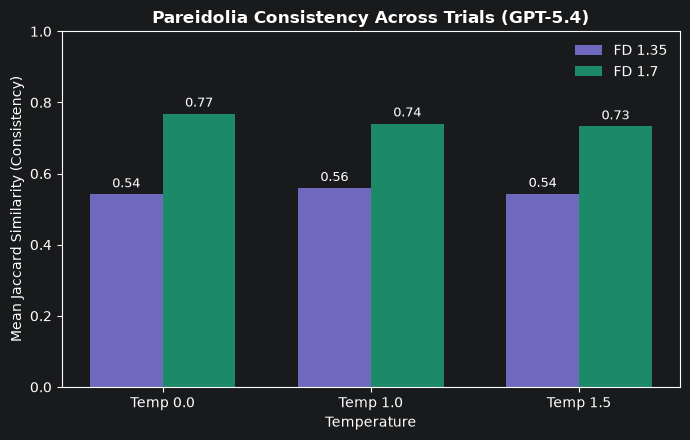

In [39]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from itertools import combinations

MODEL_NAME = "GPT-5.4"
RESULTS_DIR = Path("results")
main_file = RESULTS_DIR / MODEL_NAME / "main_results.jsonl"

main_records = []
if main_file.exists():
    with open(main_file, 'r', encoding='utf-8') as f:
        for line in f:
            if line.strip():
                try:
                    main_records.append(json.loads(line))
                except json.JSONDecodeError:
                    pass

df_main = pd.DataFrame(main_records)

def extract_fd(filename):
    if '1.35' in str(filename): return 'FD1.35'
    if '1.7' in str(filename): return 'FD1.7'
    return 'Unknown'

def get_percept_labels(fractal_parsed):
    if isinstance(fractal_parsed, dict) and 'percepts' in fractal_parsed:
        return [str(p.get('label', '')).lower().strip() for p in fractal_parsed['percepts'] if isinstance(p, dict) and p.get('label')]
    return []

if not df_main.empty:
    df_main['fd'] = df_main['file'].apply(extract_fd)
    df_main['percept_labels'] = df_main['fractal_parsed'].apply(get_percept_labels)

    def calc_image_consistency(labels_list_of_runs):
        valid_runs = [set(labels) for labels in labels_list_of_runs if labels]
        if len(valid_runs) < 2:
            return np.nan
        sims = []
        for s1, s2 in combinations(valid_runs, 2):
            union = len(s1.union(s2))
            sims.append(len(s1.intersection(s2)) / union if union > 0 else 1.0)
        return np.mean(sims) if sims else np.nan

    consistency_records = []
    for (temp, file), group in df_main.groupby(['temperature', 'file']):
        score = calc_image_consistency(group['percept_labels'].tolist())
        consistency_records.append({
            'temperature': temp,
            'file': file,
            'fd': group['fd'].iloc[0],
            'consistency_score': score
        })

    df_consistency = pd.DataFrame(consistency_records)

    print("=" * 65)
    print(f"PAREIDOLIA CONSISTENCY ANALYSIS: {MODEL_NAME}")
    print("=" * 65)

    summary_table = df_consistency.groupby(['temperature', 'fd'])['consistency_score'].agg(['count', 'mean', 'std']).round(4)
    print("\nMean Jaccard Similarity across Trials:")
    print(summary_table.to_string())
    print("-" * 65)

    pivot_data = df_consistency.groupby(['temperature', 'fd'])['consistency_score'].mean().unstack('fd')

    fig, ax = plt.subplots(figsize=(7, 4.5))
    temps = pivot_data.index
    x = np.arange(len(temps))
    width = 0.35

    if 'FD1.35' in pivot_data.columns:
        ax.bar(x - width/2, pivot_data['FD1.35'], width, label='FD 1.35', color='#7F77DD', alpha=0.85)
    if 'FD1.7' in pivot_data.columns:
        ax.bar(x + width/2, pivot_data['FD1.7'], width, label='FD 1.7', color='#1D9E75', alpha=0.85)

    ax.set_xlabel('Temperature')
    ax.set_ylabel('Mean Jaccard Similarity (Consistency)')
    ax.set_title(f'Pareidolia Consistency Across Trials ({MODEL_NAME})', fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels([f"Temp {t}" for t in temps])
    ax.set_ylim(0, 1.0)
    ax.legend(frameon=False)

    for i in x:
        if 'FD1.35' in pivot_data.columns and not np.isnan(pivot_data['FD1.35'].iloc[i]):
            val1 = pivot_data['FD1.35'].iloc[i]
            ax.text(i - width/2, val1 + 0.02, f"{val1:.2f}", ha='center', fontsize=9)
        if 'FD1.7' in pivot_data.columns and not np.isnan(pivot_data['FD1.7'].iloc[i]):
            val2 = pivot_data['FD1.7'].iloc[i]
            ax.text(i + width/2, val2 + 0.02, f"{val2:.2f}", ha='center', fontsize=9)

    plt.tight_layout()
    plt.show()
else:
    print(f"No records available in {main_file} to analyze.")

PAREIDOLIA CONSISTENCY ANALYSIS: GPT-5.4

Mean Jaccard Similarity across Trials:
                    count    mean     std
temperature fd                           
0.0         FD1.35     81  0.5414  0.1582
            FD1.7      80  0.7681  0.1259
1.0         FD1.35     69  0.5591  0.1425
            FD1.7      74  0.7406  0.1442
1.5         FD1.35     79  0.5427  0.1419
            FD1.7      80  0.7325  0.1339
-----------------------------------------------------------------


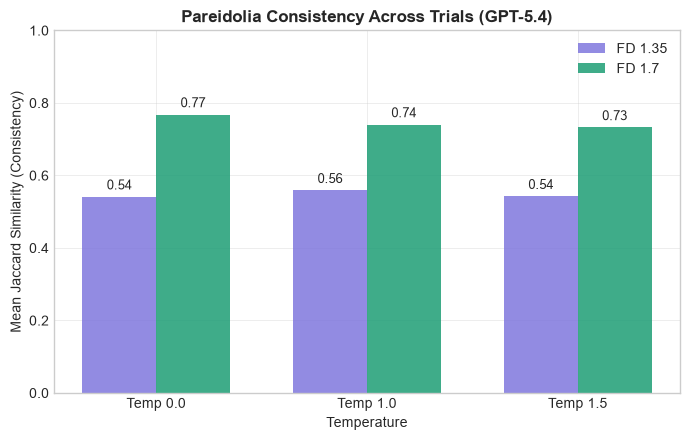

In [86]:
import json
from itertools import combinations
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

MODEL_NAME = "GPT-5.4"
RESULTS_DIR = Path("results")
main_file = RESULTS_DIR / MODEL_NAME / "main_results.jsonl"

main_records = []
if main_file.exists():
    with open(main_file, "r", encoding="utf-8") as f:
        for line in f:
            if line.strip():
                try:
                    main_records.append(json.loads(line))
                except json.JSONDecodeError:
                    pass

df_main = pd.DataFrame(main_records)


def extract_fd(filename):
    if "1.35" in str(filename):
        return "FD1.35"
    if "1.7" in str(filename):
        return "FD1.7"
    return "Unknown"


def get_percept_labels(fractal_parsed):
    if isinstance(fractal_parsed, dict) and "percepts" in fractal_parsed:
        return [
            str(p.get("label", "")).lower().strip()
            for p in fractal_parsed["percepts"]
            if isinstance(p, dict) and p.get("label")
        ]
    return []


if not df_main.empty:
    df_main["fd"] = df_main["file"].apply(extract_fd)
    df_main["percept_labels"] = df_main["fractal_parsed"].apply(
        get_percept_labels
    )

    def calc_image_consistency(labels_list_of_runs):
        valid_runs = [set(labels) for labels in labels_list_of_runs if labels]
        if len(valid_runs) < 2:
            return np.nan
        sims = []
        for s1, s2 in combinations(valid_runs, 2):
            union = len(s1.union(s2))
            sims.append(len(s1.intersection(s2)) / union if union > 0 else 1.0)
        return np.mean(sims) if sims else np.nan

    consistency_records = []
    for (temp, file), group in df_main.groupby(["temperature", "file"]):
        score = calc_image_consistency(group["percept_labels"].tolist())
        consistency_records.append(
            {
                "temperature": temp,
                "file": file,
                "fd": group["fd"].iloc[0],
                "consistency_score": score,
            }
        )

    df_consistency = pd.DataFrame(consistency_records)

    print("=" * 65)
    print(f"PAREIDOLIA CONSISTENCY ANALYSIS: {MODEL_NAME}")
    print("=" * 65)

    summary_table = (
        df_consistency.groupby(["temperature", "fd"])["consistency_score"]
        .agg(["count", "mean", "std"])
        .round(4)
    )
    print("\nMean Jaccard Similarity across Trials:")
    print(summary_table.to_string())
    print("-" * 65)

    pivot_data = (
        df_consistency.groupby(["temperature", "fd"])["consistency_score"]
        .mean()
        .unstack("fd")
    )

    # تنظیم پس‌زمینه سفید برای شکل و محور
    fig, ax = plt.subplots(figsize=(7, 4.5), facecolor="white")
    ax.set_facecolor("white")

    temps = pivot_data.index
    x = np.arange(len(temps))
    width = 0.35

    if "FD1.35" in pivot_data.columns:
        ax.bar(
            x - width / 2,
            pivot_data["FD1.35"],
            width,
            label="FD 1.35",
            color="#7F77DD",
            alpha=0.85,
        )
    if "FD1.7" in pivot_data.columns:
        ax.bar(
            x + width / 2,
            pivot_data["FD1.7"],
            width,
            label="FD 1.7",
            color="#1D9E75",
            alpha=0.85,
        )

    ax.set_xlabel("Temperature")
    ax.set_ylabel("Mean Jaccard Similarity (Consistency)")
    ax.set_title(
        f"Pareidolia Consistency Across Trials ({MODEL_NAME})",
        fontweight="bold",
    )
    ax.set_xticks(x)
    ax.set_xticklabels([f"Temp {t}" for t in temps])
    ax.set_ylim(0, 1.0)
    ax.legend(frameon=False)

    for i in x:
        if "FD1.35" in pivot_data.columns and not np.isnan(
            pivot_data["FD1.35"].iloc[i]
        ):
            val1 = pivot_data["FD1.35"].iloc[i]
            ax.text(
                i - width / 2, val1 + 0.02, f"{val1:.2f}", ha="center", fontsize=9
            )
        if "FD1.7" in pivot_data.columns and not np.isnan(
            pivot_data["FD1.7"].iloc[i]
        ):
            val2 = pivot_data["FD1.7"].iloc[i]
            ax.text(
                i + width / 2, val2 + 0.02, f"{val2:.2f}", ha="center", fontsize=9
            )

    plt.tight_layout()
    plt.show()
else:
    print(f"No records available in {main_file} to analyze.")

#### Left Experiments:

In [40]:
import os
import glob
import pandas as pd
import numpy as np

target_filename = "openrouter_activity_2026-06-27.csv"
found_path = None
search_patterns = [
    target_filename,
    f"../{target_filename}",
    f"../../{target_filename}",
    os.path.expanduser(f"~/Downloads/{target_filename}"),
    "openrouter_activity*.csv",
    "../openrouter_activity*.csv"
]

for pattern in search_patterns:
    matches = glob.glob(pattern)
    if matches:
        found_path = matches[0]
        break

if not found_path:
    raise FileNotFoundError(f"Could not find activity log file '{target_filename}'.")

TOTAL_IMAGES = 161
TEMPERATURES_COUNT = 3
RUNS_PER_IMAGE = 10
DAT_BASELINE_RUNS = 10

total_expected_runs = TOTAL_IMAGES * TEMPERATURES_COUNT * RUNS_PER_IMAGE
total_expected_calls = (total_expected_runs * 2) + (TEMPERATURES_COUNT * DAT_BASELINE_RUNS)

df_act = pd.read_csv(found_path)

gpt_mask = df_act['model_permaslug'].str.contains('gpt-5.4', case=False, na=False)
df_gpt = df_act[gpt_mask].copy()

total_completed_calls = len(df_gpt)
total_prompt_tokens = df_gpt['tokens_prompt'].sum()
total_completion_tokens = df_gpt['tokens_completion'].sum()
total_tokens = total_prompt_tokens + total_completion_tokens
total_cost = df_gpt['cost_total'].sum()

mean_prompt_per_call = df_gpt['tokens_prompt'].mean()
mean_comp_per_call = df_gpt['tokens_completion'].mean()
mean_cost_per_call = df_gpt['cost_total'].mean()

missing_calls = max(0, total_expected_calls - total_completed_calls)
missing_runs = missing_calls // 2

est_missing_prompt_tokens = int(missing_calls * mean_prompt_per_call)
est_missing_comp_tokens = int(missing_calls * mean_comp_per_call)
est_missing_total_tokens = est_missing_prompt_tokens + est_missing_comp_tokens
est_missing_cost = missing_calls * mean_cost_per_call

print("=" * 65)
print("TOKEN USAGE & BUDGET ESTIMATION (GPT-5.4)")
print("=" * 65)
print(f"Total Completed API Calls     : {total_completed_calls:,}")
print(f"Total Prompt Tokens Used      : {total_prompt_tokens:,}")
print(f"Total Completion Tokens Used  : {total_completion_tokens:,}")
print(f"Total Tokens Consumed         : {total_tokens:,}")
print(f"Total Cost Spent              : ${total_cost:,.2f}")
print("-" * 65)
print(f"Mean Prompt Tokens / Call     : {mean_prompt_per_call:,.1f}")
print(f"Mean Completion Tokens / Call : {mean_comp_per_call:,.1f}")
print(f"Mean Cost / Call              : ${mean_cost_per_call:,.4f}")
print(f"Mean Cost / Full Run (2 calls): ${mean_cost_per_call * 2:,.4f}")
print("-" * 65)
print(f"Total Expected API Calls      : {total_expected_calls:,}")
print(f"Remaining Missing Calls       : {missing_calls:,} (~{missing_runs} runs)")
print(f"Completion Rate               : {(total_completed_calls / total_expected_calls) * 100:.2f}%")
print(f"Estimated Missing Tokens      : {est_missing_total_tokens:,}")
print(f"Estimated Cost to Complete    : ${est_missing_cost:,.2f}")
print("=" * 65)

TOKEN USAGE & BUDGET ESTIMATION (GPT-5.4)
Total Completed API Calls     : 9,151
Total Prompt Tokens Used      : 5,680,708
Total Completion Tokens Used  : 490,910
Total Tokens Consumed         : 6,171,618
Total Cost Spent              : $21.56
-----------------------------------------------------------------
Mean Prompt Tokens / Call     : 620.8
Mean Completion Tokens / Call : 53.6
Mean Cost / Call              : $0.0024
Mean Cost / Full Run (2 calls): $0.0047
-----------------------------------------------------------------
Total Expected API Calls      : 9,690
Remaining Missing Calls       : 539 (~269 runs)
Completion Rate               : 94.44%
Estimated Missing Tokens      : 363,511
Estimated Cost to Complete    : $1.27


## 2.5 Mistral-Small-4

#### Example:

Step 1: Execution Profile for Mistral-Small-4
File: FD_1.35_0.png | Temp: 0.0 | Run: 1


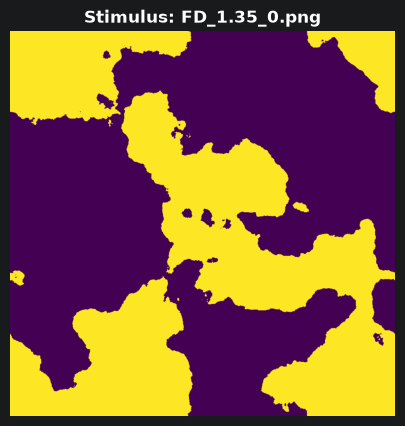


>>> PHASE 1: BASELINE DAT (CONTROL)
[PROMPT]:
Please name 10 words that are as different from each other as possible, in all ways and meanings you can imagine.

Rules:
- Only single words.
- Only nouns (e.g. things, concepts, objects). No verbs, adjectives, or other parts of speech.
- No proper nouns (no specific people, places, or brands).
- No specialized vocabulary, technical jargon, or obscure words.
- Think about different categories, contexts, domains, and properties.

Respond with a JSON object:
{
  "words": ["word1", "word2", "word3", "word4", "word5", "word6", "word7", "word8", "word9", "word10"]
}

[MODEL OUTPUT]:
{
  "words": [
    "serendipity",
    "quasar",
    "labyrinth",
    "ephemeral",
    "quintessence",
    "obfuscate",
    "kaleidoscope",
    "xenophobia",
    "zephyr",
    "quagmire"
  ]
}

>>> PHASE 2 - TURN 1: FRACTAL PAREIDOLIA
[PROMPT]:
Look closely at this image. Do you see any shapes, faces, objects, animals, or patterns in it?

Please list everything you 

In [43]:
import json
import matplotlib.pyplot as plt
from matplotlib.image import imread

main_data = None
if main_file.exists():
    with open(main_file, "r", encoding="utf-8") as f:
        for line in f:
            if line.strip():
                try:
                    main_data = json.loads(line)
                    break
                except json.JSONDecodeError:
                    pass

if main_data:
    target_temp = main_data.get('temperature')
    target_run = main_data.get('run_id')
    img_filename = main_data.get('file')

    baseline_data = None
    if baseline_file.exists():
        with open(baseline_file, "r", encoding="utf-8") as f:
            for line in f:
                if line.strip():
                    try:
                        b_data = json.loads(line)
                        if b_data.get('temperature') == target_temp and b_data.get('run_id') == target_run:
                            baseline_data = b_data
                            break
                    except json.JSONDecodeError:
                        pass

    img_path = None
    for d in IMAGE_DIRS:
        p = d / img_filename
        if p.exists():
            img_path = p
            break

    print(f"Step 1: Execution Profile for {MODEL_NAME}")
    print(f"File: {img_filename} | Temp: {target_temp} | Run: {target_run}")

    if img_path:
        plt.figure(figsize=(5, 5))
        img = imread(img_path)
        plt.imshow(img)
        plt.axis('off')
        plt.title(f"Stimulus: {img_filename}", fontweight='bold')
        plt.show()
    else:
        print(f"\n[IMAGE NOT FOUND: {img_filename}]")

    print("\n" + "="*80)
    print(">>> PHASE 1: BASELINE DAT (CONTROL)")
    print("="*80)
    print("[PROMPT]:")
    print(DAT_PROMPT.strip())
    print("\n[MODEL OUTPUT]:")
    if baseline_data and baseline_data.get('dat_parsed'):
        print(json.dumps(baseline_data['dat_parsed'], indent=2))
    else:
        print("No baseline data found for this exact run.")

    print("\n" + "="*80)
    print(">>> PHASE 2 - TURN 1: FRACTAL PAREIDOLIA")
    print("="*80)
    print("[PROMPT]:")
    print(FRACTAL_PROMPT.strip() + f"\n[ATTACHED IMAGE: {img_filename}]")
    print("\n[MODEL OUTPUT]:")
    fp = main_data.get('fractal_parsed') or {}
    print(json.dumps(fp, indent=2))

    print("\n" + "="*80)
    print(">>> PHASE 2 - TURN 2: PRIMED DAT (SAME THREAD)")
    print("="*80)
    print("[PROMPT]:")
    print(DAT_PROMPT.strip())
    print("\n[MODEL OUTPUT]:")
    dp = main_data.get('dat_parsed') or {}
    print(json.dumps(dp, indent=2))
    print("="*80 + "\n")
else:
    print(f"No records found in {main_file}")

#### Experiment Analysis:

In [44]:
import json
from pathlib import Path

MODEL_NAME = "Mistral-Small-4"
RESULTS_DIR = Path("results")
IMAGE_DIRS = [Path("new-FD-images/FD135"), Path("new-FD-images/FD17")]
TEMPERATURES = [0.0, 1.0, 1.5]
NUM_RUNS = 10

images = []
for d in IMAGE_DIRS:
    if d.exists():
        images.extend(d.glob("*.png"))
        images.extend(d.glob("*.jpg"))

expected_combos = set((temp, img.name, run_id) for img in images for temp in TEMPERATURES for run_id in range(1, NUM_RUNS + 1))

main_file = RESULTS_DIR / MODEL_NAME / "main_results.jsonl"
completed_combos = set()

if main_file.exists():
    with open(main_file, "r", encoding="utf-8") as f:
        for line in f:
            if not line.strip():
                continue
            try:
                data = json.loads(line)
                if 'temperature' in data and 'file' in data and 'run_id' in data:
                    completed_combos.add((data['temperature'], data['file'], data['run_id']))
            except json.JSONDecodeError:
                pass

missing_combos = expected_combos - completed_combos

print(f"Step 2: Execution Progress for {MODEL_NAME}")
print("="*50)
print(f"Total Images Found    : {len(images)}")
print(f"Expected Runs (Total) : {len(expected_combos)}")
print(f"Completed Runs        : {len(completed_combos)}")
print(f"Missing Runs          : {len(missing_combos)}")
percentage = (len(completed_combos) / len(expected_combos)) * 100 if expected_combos else 0
print(f"Completion Rate       : {percentage:.2f}%")
print("="*50)

if missing_combos:
    print("\nSample of missing runs (showing up to 5):")
    for m in list(missing_combos)[:5]:
        print(f"- Temp: {m[0]} | File: {m[1]} | Run ID: {m[2]}")
else:
    print("\nAll expected runs are 100% completed!")

Step 2: Execution Progress for Mistral-Small-4
Total Images Found    : 161
Expected Runs (Total) : 4830
Completed Runs        : 4830
Missing Runs          : 0
Completion Rate       : 100.00%

All expected runs are 100% completed!


#### Vocab Analysis

In [45]:
import json
import numpy as np
import pandas as pd
from pathlib import Path
from collections import Counter
from scipy.stats import entropy

MODEL_NAME = "Mistral-Small-4"
RESULTS_DIR = Path("results")

main_file = RESULTS_DIR / MODEL_NAME / "main_results.jsonl"
base_file = RESULTS_DIR / MODEL_NAME / "dat_baseline_results.jsonl"

main_records = []
if main_file.exists():
    with open(main_file, 'r', encoding='utf-8') as f:
        for line in f:
            if line.strip():
                try:
                    main_records.append(json.loads(line))
                except json.JSONDecodeError:
                    pass

base_records = []
if base_file.exists():
    with open(base_file, 'r', encoding='utf-8') as f:
        for line in f:
            if line.strip():
                try:
                    base_records.append(json.loads(line))
                except json.JSONDecodeError:
                    pass

df_main = pd.DataFrame(main_records)
df_base = pd.DataFrame(base_records)

def extract_fd(filename):
    if '1.35' in str(filename): return 'FD1.35'
    if '1.7' in str(filename): return 'FD1.7'
    return 'Unknown'

def get_dat_words(dat_parsed):
    if isinstance(dat_parsed, dict) and 'words' in dat_parsed:
        return [str(w).lower().strip() for w in dat_parsed['words'] if str(w).strip()]
    return []

def get_mean_confidence(fractal_parsed):
    if isinstance(fractal_parsed, dict) and 'percepts' in fractal_parsed:
        confs = [p.get('confidence_present', 0) for p in fractal_parsed['percepts'] if isinstance(p, dict)]
        if confs: return np.mean(confs)
    return np.nan

def calc_ttr(words):
    return len(set(words)) / len(words) if words else 0.0

def calc_entropy(words):
    if not words: return 0.0
    counts = list(Counter(words).values())
    probs = np.array(counts) / sum(counts)
    return entropy(probs)

if not df_main.empty:
    df_main['fd'] = df_main['file'].apply(extract_fd)
    df_main['dat_words'] = df_main['dat_parsed'].apply(get_dat_words)
    df_main['mean_confidence'] = df_main['fractal_parsed'].apply(get_mean_confidence)

    df_main['total_words'] = df_main['dat_words'].apply(len)
    df_main['unique_words'] = df_main['dat_words'].apply(lambda x: len(set(x)))
    df_main['ttr'] = df_main['dat_words'].apply(calc_ttr)
    df_main['repetition_rate'] = 1.0 - df_main['ttr']
    df_main['entropy'] = df_main['dat_words'].apply(calc_entropy)

    df_base['dat_words'] = df_base['dat_parsed'].apply(get_dat_words)
    baseline_vocab_by_temp = {}
    if not df_base.empty and 'temperature' in df_base.columns:
        for temp, group in df_base.groupby('temperature'):
            baseline_vocab_by_temp[temp] = set([w for words in group['dat_words'] for w in words])

    def calc_novel_ratio(row):
        temp = row.get('temperature')
        words = row.get('dat_words', [])
        if not words or temp not in baseline_vocab_by_temp: return 0.0
        base_vocab = baseline_vocab_by_temp[temp]
        novel_words = [w for w in words if w not in base_vocab]
        return len(novel_words) / len(words)

    df_main['novel_word_prop'] = df_main.apply(calc_novel_ratio, axis=1)

    print("="*75)
    print(f"VOCABULARY & DIVERSITY ANALYSIS: {MODEL_NAME}")
    print("="*75)

    print("\n1. EFFECT OF FD ON VOCABULARY SIZE (Overall Unique Words):")
    for fd, grp in df_main.groupby('fd'):
        unique_words_count = len(set([w for words in grp['dat_words'] for w in words]))
        print(f"  - {fd:<7}: {unique_words_count} unique words")

    print("\n2. MEAN CONFIDENCE LEVELS BY TEMPERATURE:")
    mean_conf = df_main.groupby('temperature')['mean_confidence'].mean()
    for t, val in mean_conf.items():
        print(f"  - Temp {t}: {val:.2f}%")

    print("\n3. WORD DIVERSITY METRICS (Averaged across runs):")
    div_metrics = ['total_words', 'ttr', 'repetition_rate', 'novel_word_prop', 'entropy']
    diversity_summary = df_main.groupby('temperature')[div_metrics].mean()
    print(diversity_summary.round(4).to_string())
    print("="*75)
else:
    print(f"No records available in {main_file} to analyze.")

VOCABULARY & DIVERSITY ANALYSIS: Mistral-Small-4

1. EFFECT OF FD ON VOCABULARY SIZE (Overall Unique Words):
  - FD1.35 : 1404 unique words
  - FD1.7  : 1395 unique words

2. MEAN CONFIDENCE LEVELS BY TEMPERATURE:
  - Temp 0.0: 79.81%
  - Temp 1.0: 76.43%
  - Temp 1.5: 76.86%

3. WORD DIVERSITY METRICS (Averaged across runs):
             total_words     ttr  repetition_rate  novel_word_prop  entropy
temperature                                                                
0.0              10.0000  0.9989           0.0011           0.4297   2.3010
1.0               9.9932  0.9989           0.0011           0.5761   2.3004
1.5               9.9888  0.9991           0.0009           0.6466   2.2997


#### Perception Analysis:

PAREIDOLIA CONSISTENCY ANALYSIS: Mistral-Small-4

Mean Jaccard Similarity across Trials:
                    count    mean     std
temperature fd                           
0.0         FD1.35     14  0.1726  0.1348
            FD1.7      13  0.3130  0.2691
1.0         FD1.35     50  0.0368  0.0469
            FD1.7      63  0.0512  0.0646
1.5         FD1.35     54  0.0475  0.0781
            FD1.7      50  0.0562  0.0775
-----------------------------------------------------------------


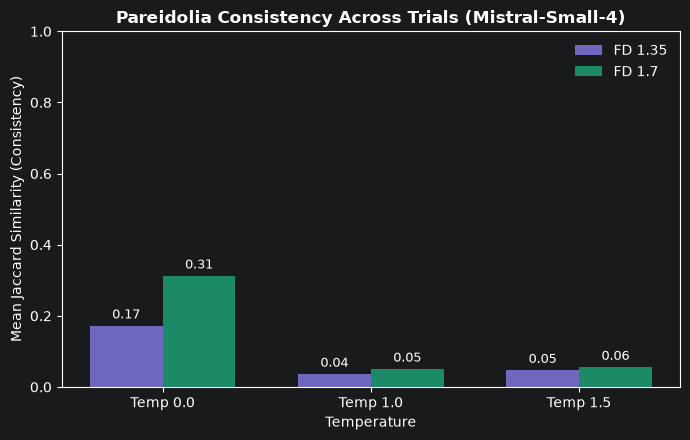

In [46]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from itertools import combinations

MODEL_NAME = "Mistral-Small-4"
RESULTS_DIR = Path("results")
main_file = RESULTS_DIR / MODEL_NAME / "main_results.jsonl"

main_records = []
if main_file.exists():
    with open(main_file, 'r', encoding='utf-8') as f:
        for line in f:
            if line.strip():
                try:
                    main_records.append(json.loads(line))
                except json.JSONDecodeError:
                    pass

df_main = pd.DataFrame(main_records)

def extract_fd(filename):
    if '1.35' in str(filename): return 'FD1.35'
    if '1.7' in str(filename): return 'FD1.7'
    return 'Unknown'

def get_percept_labels(fractal_parsed):
    if isinstance(fractal_parsed, dict) and 'percepts' in fractal_parsed:
        return [str(p.get('label', '')).lower().strip() for p in fractal_parsed['percepts'] if isinstance(p, dict) and p.get('label')]
    return []

if not df_main.empty:
    df_main['fd'] = df_main['file'].apply(extract_fd)
    df_main['percept_labels'] = df_main['fractal_parsed'].apply(get_percept_labels)

    def calc_image_consistency(labels_list_of_runs):
        valid_runs = [set(labels) for labels in labels_list_of_runs if labels]
        if len(valid_runs) < 2:
            return np.nan
        sims = []
        for s1, s2 in combinations(valid_runs, 2):
            union = len(s1.union(s2))
            sims.append(len(s1.intersection(s2)) / union if union > 0 else 1.0)
        return np.mean(sims) if sims else np.nan

    consistency_records = []
    for (temp, file), group in df_main.groupby(['temperature', 'file']):
        score = calc_image_consistency(group['percept_labels'].tolist())
        consistency_records.append({
            'temperature': temp,
            'file': file,
            'fd': group['fd'].iloc[0],
            'consistency_score': score
        })

    df_consistency = pd.DataFrame(consistency_records)

    print("=" * 65)
    print(f"PAREIDOLIA CONSISTENCY ANALYSIS: {MODEL_NAME}")
    print("=" * 65)

    summary_table = df_consistency.groupby(['temperature', 'fd'])['consistency_score'].agg(['count', 'mean', 'std']).round(4)
    print("\nMean Jaccard Similarity across Trials:")
    print(summary_table.to_string())
    print("-" * 65)

    pivot_data = df_consistency.groupby(['temperature', 'fd'])['consistency_score'].mean().unstack('fd')

    fig, ax = plt.subplots(figsize=(7, 4.5))
    temps = pivot_data.index
    x = np.arange(len(temps))
    width = 0.35

    if 'FD1.35' in pivot_data.columns:
        ax.bar(x - width/2, pivot_data['FD1.35'], width, label='FD 1.35', color='#7F77DD', alpha=0.85)
    if 'FD1.7' in pivot_data.columns:
        ax.bar(x + width/2, pivot_data['FD1.7'], width, label='FD 1.7', color='#1D9E75', alpha=0.85)

    ax.set_xlabel('Temperature')
    ax.set_ylabel('Mean Jaccard Similarity (Consistency)')
    ax.set_title(f'Pareidolia Consistency Across Trials ({MODEL_NAME})', fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels([f"Temp {t}" for t in temps])
    ax.set_ylim(0, 1.0)
    ax.legend(frameon=False)

    for i in x:
        if 'FD1.35' in pivot_data.columns and not np.isnan(pivot_data['FD1.35'].iloc[i]):
            val1 = pivot_data['FD1.35'].iloc[i]
            ax.text(i - width/2, val1 + 0.02, f"{val1:.2f}", ha='center', fontsize=9)
        if 'FD1.7' in pivot_data.columns and not np.isnan(pivot_data['FD1.7'].iloc[i]):
            val2 = pivot_data['FD1.7'].iloc[i]
            ax.text(i + width/2, val2 + 0.02, f"{val2:.2f}", ha='center', fontsize=9)

    plt.tight_layout()
    plt.show()
else:
    print(f"No records available in {main_file} to analyze.")

PAREIDOLIA CONSISTENCY ANALYSIS: Mistral-Small-4

Mean Jaccard Similarity across Trials:
                    count    mean     std
temperature fd                           
0.0         FD1.35     14  0.1726  0.1348
            FD1.7      13  0.3130  0.2691
1.0         FD1.35     50  0.0368  0.0469
            FD1.7      63  0.0512  0.0646
1.5         FD1.35     54  0.0475  0.0781
            FD1.7      50  0.0562  0.0775
-----------------------------------------------------------------


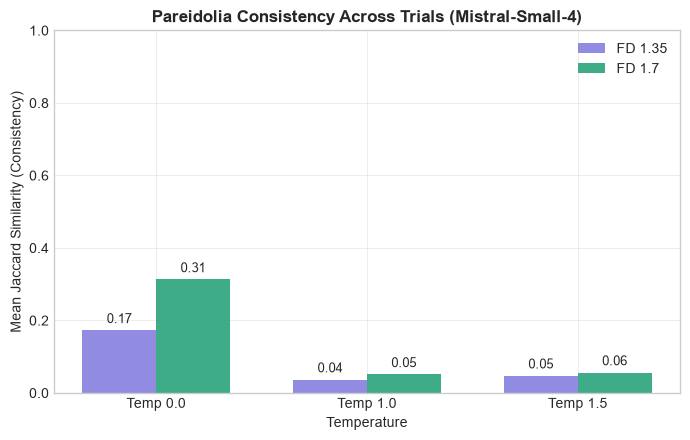

In [87]:
import json
from itertools import combinations
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

MODEL_NAME = "Mistral-Small-4"
RESULTS_DIR = Path("results")
main_file = RESULTS_DIR / MODEL_NAME / "main_results.jsonl"

main_records = []
if main_file.exists():
    with open(main_file, "r", encoding="utf-8") as f:
        for line in f:
            if line.strip():
                try:
                    main_records.append(json.loads(line))
                except json.JSONDecodeError:
                    pass

df_main = pd.DataFrame(main_records)


def extract_fd(filename):
    if "1.35" in str(filename):
        return "FD1.35"
    if "1.7" in str(filename):
        return "FD1.7"
    return "Unknown"


def get_percept_labels(fractal_parsed):
    if isinstance(fractal_parsed, dict) and "percepts" in fractal_parsed:
        return [
            str(p.get("label", "")).lower().strip()
            for p in fractal_parsed["percepts"]
            if isinstance(p, dict) and p.get("label")
        ]
    return []


if not df_main.empty:
    df_main["fd"] = df_main["file"].apply(extract_fd)
    df_main["percept_labels"] = df_main["fractal_parsed"].apply(
        get_percept_labels
    )

    def calc_image_consistency(labels_list_of_runs):
        valid_runs = [set(labels) for labels in labels_list_of_runs if labels]
        if len(valid_runs) < 2:
            return np.nan
        sims = []
        for s1, s2 in combinations(valid_runs, 2):
            union = len(s1.union(s2))
            sims.append(len(s1.intersection(s2)) / union if union > 0 else 1.0)
        return np.mean(sims) if sims else np.nan

    consistency_records = []
    for (temp, file), group in df_main.groupby(["temperature", "file"]):
        score = calc_image_consistency(group["percept_labels"].tolist())
        consistency_records.append(
            {
                "temperature": temp,
                "file": file,
                "fd": group["fd"].iloc[0],
                "consistency_score": score,
            }
        )

    df_consistency = pd.DataFrame(consistency_records)

    print("=" * 65)
    print(f"PAREIDOLIA CONSISTENCY ANALYSIS: {MODEL_NAME}")
    print("=" * 65)

    summary_table = (
        df_consistency.groupby(["temperature", "fd"])["consistency_score"]
        .agg(["count", "mean", "std"])
        .round(4)
    )
    print("\nMean Jaccard Similarity across Trials:")
    print(summary_table.to_string())
    print("-" * 65)

    pivot_data = (
        df_consistency.groupby(["temperature", "fd"])["consistency_score"]
        .mean()
        .unstack("fd")
    )

    # پس‌زمینه سفید برای کادر کلی و محور نمودار
    fig, ax = plt.subplots(figsize=(7, 4.5), facecolor="white")
    ax.set_facecolor("white")

    temps = pivot_data.index
    x = np.arange(len(temps))
    width = 0.35

    if "FD1.35" in pivot_data.columns:
        ax.bar(
            x - width / 2,
            pivot_data["FD1.35"],
            width,
            label="FD 1.35",
            color="#7F77DD",
            alpha=0.85,
        )
    if "FD1.7" in pivot_data.columns:
        ax.bar(
            x + width / 2,
            pivot_data["FD1.7"],
            width,
            label="FD 1.7",
            color="#1D9E75",
            alpha=0.85,
        )

    ax.set_xlabel("Temperature")
    ax.set_ylabel("Mean Jaccard Similarity (Consistency)")
    ax.set_title(
        f"Pareidolia Consistency Across Trials ({MODEL_NAME})",
        fontweight="bold",
    )
    ax.set_xticks(x)
    ax.set_xticklabels([f"Temp {t}" for t in temps])
    ax.set_ylim(0, 1.0)
    ax.legend(frameon=False)

    for i in x:
        if "FD1.35" in pivot_data.columns and not np.isnan(
            pivot_data["FD1.35"].iloc[i]
        ):
            val1 = pivot_data["FD1.35"].iloc[i]
            ax.text(
                i - width / 2, val1 + 0.02, f"{val1:.2f}", ha="center", fontsize=9
            )
        if "FD1.7" in pivot_data.columns and not np.isnan(
            pivot_data["FD1.7"].iloc[i]
        ):
            val2 = pivot_data["FD1.7"].iloc[i]
            ax.text(
                i + width / 2, val2 + 0.02, f"{val2:.2f}", ha="center", fontsize=9
            )

    plt.tight_layout()
    plt.show()
else:
    print(f"No records available in {main_file} to analyze.")

In [48]:
df_main['has_percepts'] = df_main['percept_labels'].apply(lambda x: len(x) > 0)

empty_stats = df_main.groupby(['temperature', 'fd'])['has_percepts'].agg(
    total_runs='count',
    runs_with_detection='sum',
    pct_detection=lambda x: f"{x.mean()*100:.1f}%"
)
print("Pareidolia Detection Rate (Non-empty responses):")
print(empty_stats)

Pareidolia Detection Rate (Non-empty responses):
                    total_runs  runs_with_detection pct_detection
temperature fd                                                   
0.0         FD1.35         810                   65          8.0%
            FD1.7          800                   56          7.0%
1.0         FD1.35         810                  174         21.5%
            FD1.7          800                  209         26.1%
1.5         FD1.35         810                  196         24.2%
            FD1.7          800                  171         21.4%


##### Left Experiments:

In [49]:
import os
import glob
import pandas as pd
import numpy as np

target_filename = "openrouter_activity_2026-06-27 (2).csv"
found_path = None
search_patterns = [
    target_filename,
    f"../{target_filename}",
    f"../../{target_filename}",
    os.path.expanduser(f"~/Downloads/{target_filename}"),
    "openrouter_activity*.csv",
    "../openrouter_activity*.csv"
]

for pattern in search_patterns:
    matches = glob.glob(pattern)
    if matches:
        found_path = matches[0]
        break

if not found_path:
    raise FileNotFoundError(f"Could not find activity log file '{target_filename}'.")

TOTAL_IMAGES = 161
TEMPERATURES_COUNT = 3
RUNS_PER_IMAGE = 10
DAT_BASELINE_RUNS = 10

total_expected_runs = TOTAL_IMAGES * TEMPERATURES_COUNT * RUNS_PER_IMAGE
total_expected_calls = (total_expected_runs * 2) + (TEMPERATURES_COUNT * DAT_BASELINE_RUNS)

df_act = pd.read_csv(found_path)

mistral_mask = df_act['model_permaslug'].str.contains('mistral-small', case=False, na=False)
df_mistral = df_act[mistral_mask].copy()

total_completed_calls = len(df_mistral)
total_prompt_tokens = df_mistral['tokens_prompt'].sum()
total_completion_tokens = df_mistral['tokens_completion'].sum()
total_tokens = total_prompt_tokens + total_completion_tokens
total_cost = df_mistral['cost_total'].sum()

mean_prompt_per_call = df_mistral['tokens_prompt'].mean()
mean_comp_per_call = df_mistral['tokens_completion'].mean()
mean_cost_per_call = df_mistral['cost_total'].mean()

missing_calls = max(0, total_expected_calls - total_completed_calls)
missing_runs = missing_calls // 2

est_missing_prompt_tokens = int(missing_calls * mean_prompt_per_call)
est_missing_comp_tokens = int(missing_calls * mean_comp_per_call)
est_missing_total_tokens = est_missing_prompt_tokens + est_missing_comp_tokens
est_missing_cost = missing_calls * mean_cost_per_call

print("=" * 65)
print("TOKEN USAGE & BUDGET ESTIMATION (Mistral-Small-4)")
print("=" * 65)
print(f"Total Completed API Calls     : {total_completed_calls:,}")
print(f"Total Prompt Tokens Used      : {total_prompt_tokens:,}")
print(f"Total Completion Tokens Used  : {total_completion_tokens:,}")
print(f"Total Tokens Consumed         : {total_tokens:,}")
print(f"Total Cost Spent              : ${total_cost:,.2f}")
print("-" * 65)
print(f"Mean Prompt Tokens / Call     : {mean_prompt_per_call:,.1f}")
print(f"Mean Completion Tokens / Call : {mean_comp_per_call:,.1f}")
print(f"Mean Cost / Call              : ${mean_cost_per_call:,.4f}")
print(f"Mean Cost / Full Run (2 calls): ${mean_cost_per_call * 2:,.4f}")
print("-" * 65)
print(f"Total Expected API Calls      : {total_expected_calls:,}")
print(f"Remaining Missing Calls       : {missing_calls:,} (~{missing_runs} runs)")
print(f"Completion Rate               : {(total_completed_calls / total_expected_calls) * 100:.2f}%")
print(f"Estimated Missing Tokens      : {est_missing_total_tokens:,}")
print(f"Estimated Cost to Complete    : ${est_missing_cost:,.2f}")
print("=" * 65)

TOKEN USAGE & BUDGET ESTIMATION (Mistral-Small-4)
Total Completed API Calls     : 9,667
Total Prompt Tokens Used      : 6,628,860
Total Completion Tokens Used  : 324,246
Total Tokens Consumed         : 6,953,106
Total Cost Spent              : $0.83
-----------------------------------------------------------------
Mean Prompt Tokens / Call     : 685.7
Mean Completion Tokens / Call : 33.5
Mean Cost / Call              : $0.0001
Mean Cost / Full Run (2 calls): $0.0002
-----------------------------------------------------------------
Total Expected API Calls      : 9,690
Remaining Missing Calls       : 23 (~11 runs)
Completion Rate               : 99.76%
Estimated Missing Tokens      : 16,542
Estimated Cost to Complete    : $0.00


## 2.6 Qwen3.5-9b

#### Example:

Step 1: Execution Profile for Qwen3.5-9B
File: FD_1.35_0.png | Temp: 0.0 | Run: 1


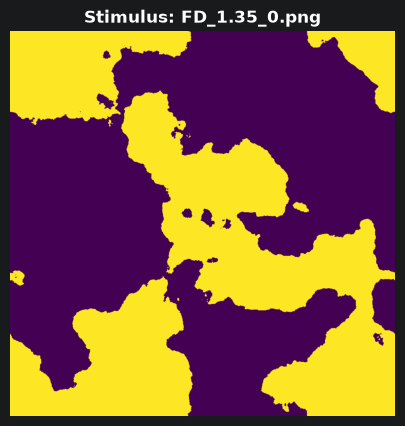


>>> PHASE 1: BASELINE DAT (CONTROL)
[PROMPT]:
Please name 10 words that are as different from each other as possible, in all ways and meanings you can imagine.

Rules:
- Only single words.
- Only nouns (e.g. things, concepts, objects). No verbs, adjectives, or other parts of speech.
- No proper nouns (no specific people, places, or brands).
- No specialized vocabulary, technical jargon, or obscure words.
- Think about different categories, contexts, domains, and properties.

Respond with a JSON object:
{
  "words": ["word1", "word2", "word3", "word4", "word5", "word6", "word7", "word8", "word9", "word10"]
}

[MODEL OUTPUT]:
{
  "words": [
    "Silence",
    "Mountain",
    "Child",
    "Bread",
    "Key",
    "War",
    "Dream",
    "Ocean",
    "Shadow",
    "Love"
  ]
}

>>> PHASE 2 - TURN 1: FRACTAL PAREIDOLIA
[PROMPT]:
Look closely at this image. Do you see any shapes, faces, objects, animals, or patterns in it?

Please list everything you can perceive, even if faint or ambiguous.

In [51]:
import json
import matplotlib.pyplot as plt
from matplotlib.image import imread

main_data = None
if main_file.exists():
    with open(main_file, "r", encoding="utf-8") as f:
        for line in f:
            if line.strip():
                try:
                    main_data = json.loads(line)
                    break
                except json.JSONDecodeError:
                    pass

if main_data:
    target_temp = main_data.get('temperature')
    target_run = main_data.get('run_id')
    img_filename = main_data.get('file')

    baseline_data = None
    if baseline_file.exists():
        with open(baseline_file, "r", encoding="utf-8") as f:
            for line in f:
                if line.strip():
                    try:
                        b_data = json.loads(line)
                        if b_data.get('temperature') == target_temp and b_data.get('run_id') == target_run:
                            baseline_data = b_data
                            break
                    except json.JSONDecodeError:
                        pass

    img_path = None
    for d in IMAGE_DIRS:
        p = d / img_filename
        if p.exists():
            img_path = p
            break

    print(f"Step 1: Execution Profile for {MODEL_NAME}")
    print(f"File: {img_filename} | Temp: {target_temp} | Run: {target_run}")

    if img_path:
        plt.figure(figsize=(5, 5))
        img = imread(img_path)
        plt.imshow(img)
        plt.axis('off')
        plt.title(f"Stimulus: {img_filename}", fontweight='bold')
        plt.show()
    else:
        print(f"\n[IMAGE NOT FOUND: {img_filename}]")

    print("\n" + "="*80)
    print(">>> PHASE 1: BASELINE DAT (CONTROL)")
    print("="*80)
    print("[PROMPT]:")
    print(DAT_PROMPT.strip())
    print("\n[MODEL OUTPUT]:")
    if baseline_data and baseline_data.get('dat_parsed'):
        print(json.dumps(baseline_data['dat_parsed'], indent=2))
    else:
        print("No baseline data found for this exact run.")

    print("\n" + "="*80)
    print(">>> PHASE 2 - TURN 1: FRACTAL PAREIDOLIA")
    print("="*80)
    print("[PROMPT]:")
    print(FRACTAL_PROMPT.strip() + f"\n[ATTACHED IMAGE: {img_filename}]")
    print("\n[MODEL OUTPUT]:")
    fp = main_data.get('fractal_parsed') or {}
    print(json.dumps(fp, indent=2))

    print("\n" + "="*80)
    print(">>> PHASE 2 - TURN 2: PRIMED DAT (SAME THREAD)")
    print("="*80)
    print("[PROMPT]:")
    print(DAT_PROMPT.strip())
    print("\n[MODEL OUTPUT]:")
    dp = main_data.get('dat_parsed') or {}
    print(json.dumps(dp, indent=2))
    print("="*80 + "\n")
else:
    print(f"No records found in {main_file}")

#### Experiment Analysis:

In [52]:
import json
from pathlib import Path

MODEL_NAME = "Qwen3.5-9B"
RESULTS_DIR = Path("results")
IMAGE_DIRS = [Path("new-FD-images/FD135"), Path("new-FD-images/FD17")]
TEMPERATURES = [0.0, 1.0, 1.5]
NUM_RUNS = 10

images = []
for d in IMAGE_DIRS:
    if d.exists():
        images.extend(d.glob("*.png"))
        images.extend(d.glob("*.jpg"))

expected_combos = set((temp, img.name, run_id) for img in images for temp in TEMPERATURES for run_id in range(1, NUM_RUNS + 1))

main_file = RESULTS_DIR / MODEL_NAME / "main_results.jsonl"
completed_combos = set()

if main_file.exists():
    with open(main_file, "r", encoding="utf-8") as f:
        for line in f:
            if not line.strip():
                continue
            try:
                data = json.loads(line)
                if 'temperature' in data and 'file' in data and 'run_id' in data:
                    completed_combos.add((data['temperature'], data['file'], data['run_id']))
            except json.JSONDecodeError:
                pass

missing_combos = expected_combos - completed_combos

print(f"Step 2: Execution Progress for {MODEL_NAME}")
print("="*50)
print(f"Total Images Found    : {len(images)}")
print(f"Expected Runs (Total) : {len(expected_combos)}")
print(f"Completed Runs        : {len(completed_combos)}")
print(f"Missing Runs          : {len(missing_combos)}")
percentage = (len(completed_combos) / len(expected_combos)) * 100 if expected_combos else 0
print(f"Completion Rate       : {percentage:.2f}%")
print("="*50)

if missing_combos:
    print("\nSample of missing runs (showing up to 5):")
    for m in list(missing_combos)[:5]:
        print(f"- Temp: {m[0]} | File: {m[1]} | Run ID: {m[2]}")
else:
    print("\nAll expected runs are 100% completed!")

Step 2: Execution Progress for Qwen3.5-9B
Total Images Found    : 161
Expected Runs (Total) : 4830
Completed Runs        : 4765
Missing Runs          : 65
Completion Rate       : 98.65%

Sample of missing runs (showing up to 5):
- Temp: 1.5 | File: FD_1.35_75.png | Run ID: 3
- Temp: 1.0 | File: FD_1.7_21.png | Run ID: 2
- Temp: 1.5 | File: FD_1.35_60.png | Run ID: 4
- Temp: 1.5 | File: FD_1.7_60.png | Run ID: 3
- Temp: 1.5 | File: FD_1.35_43.png | Run ID: 10


#### Vocab Analysis:

In [55]:
import json
import re
import numpy as np
import pandas as pd
from pathlib import Path
from collections import Counter
from scipy.stats import entropy

MODEL_NAME = "Qwen3.5-9B"
RESULTS_DIR = Path("results")

main_file = RESULTS_DIR / MODEL_NAME / "main_results.jsonl"
base_file = RESULTS_DIR / MODEL_NAME / "dat_baseline_results.jsonl"

main_records = []
if main_file.exists():
    with open(main_file, 'r', encoding='utf-8') as f:
        for line in f:
            if line.strip():
                try:
                    main_records.append(json.loads(line))
                except json.JSONDecodeError:
                    pass

base_records = []
if base_file.exists():
    with open(base_file, 'r', encoding='utf-8') as f:
        for line in f:
            if line.strip():
                try:
                    base_records.append(json.loads(line))
                except json.JSONDecodeError:
                    pass

df_main = pd.DataFrame(main_records)
df_base = pd.DataFrame(base_records)

def extract_fd(filename):
    if '1.35' in str(filename): return 'FD1.35'
    if '1.7' in str(filename): return 'FD1.7'
    return 'Unknown'

def get_dat_words(dat_parsed):
    if isinstance(dat_parsed, dict) and 'words' in dat_parsed:
        return [str(w).lower().strip() for w in dat_parsed['words'] if str(w).strip()]
    return []

def safe_parse_confidence(val):
    """تبدیل امن انواع ورودی‌های confidence (عدد، رشته عددی، یا رشته دارای علامت درصد) به float"""
    if val is None:
        return None
    if isinstance(val, (int, float)):
        return float(val)
    if isinstance(val, str):
        # استخراج اولین عدد موجود در رشته
        match = re.search(r"[-+]?\d*\.?\d+", val)
        if match:
            try:
                return float(match.group())
            except ValueError:
                return None
    return None

def get_mean_confidence(fractal_parsed):
    if isinstance(fractal_parsed, dict) and 'percepts' in fractal_parsed:
        confs = []
        for p in fractal_parsed['percepts']:
            if isinstance(p, dict):
                c_val = safe_parse_confidence(p.get('confidence_present'))
                if c_val is not None:
                    confs.append(c_val)
        if confs:
            return float(np.mean(confs))
    return np.nan

def calc_ttr(words):
    return len(set(words)) / len(words) if words else 0.0

def calc_entropy(words):
    if not words: return 0.0
    counts = list(Counter(words).values())
    probs = np.array(counts) / sum(counts)
    return entropy(probs)

if not df_main.empty:
    df_main['fd'] = df_main['file'].apply(extract_fd)
    df_main['dat_words'] = df_main['dat_parsed'].apply(get_dat_words)
    df_main['mean_confidence'] = df_main['fractal_parsed'].apply(get_mean_confidence)

    df_main['total_words'] = df_main['dat_words'].apply(len)
    df_main['unique_words'] = df_main['dat_words'].apply(lambda x: len(set(x)))
    df_main['ttr'] = df_main['dat_words'].apply(calc_ttr)
    df_main['repetition_rate'] = 1.0 - df_main['ttr']
    df_main['entropy'] = df_main['dat_words'].apply(calc_entropy)

    df_base['dat_words'] = df_base['dat_parsed'].apply(get_dat_words)
    baseline_vocab_by_temp = {}
    if not df_base.empty and 'temperature' in df_base.columns:
        for temp, group in df_base.groupby('temperature'):
            baseline_vocab_by_temp[temp] = set([w for words in group['dat_words'] for w in words])

    def calc_novel_ratio(row):
        temp = row.get('temperature')
        words = row.get('dat_words', [])
        if not words or temp not in baseline_vocab_by_temp: return 0.0
        base_vocab = baseline_vocab_by_temp[temp]
        novel_words = [w for w in words if w not in base_vocab]
        return len(novel_words) / len(words)

    df_main['novel_word_prop'] = df_main.apply(calc_novel_ratio, axis=1)

    print("="*75)
    print(f"VOCABULARY & DIVERSITY ANALYSIS: {MODEL_NAME}")
    print("="*75)

    print("\n1. EFFECT OF FD ON VOCABULARY SIZE (Overall Unique Words):")
    for fd, grp in df_main.groupby('fd'):
        unique_words_count = len(set([w for words in grp['dat_words'] for w in words]))
        print(f"  - {fd:<7}: {unique_words_count} unique words")

    print("\n2. MEAN CONFIDENCE LEVELS BY TEMPERATURE:")
    mean_conf = df_main.groupby('temperature')['mean_confidence'].mean()
    for t, val in mean_conf.items():
        print(f"  - Temp {t}: {val:.2f}%")

    print("\n3. WORD DIVERSITY METRICS (Averaged across runs):")
    div_metrics = ['total_words', 'ttr', 'repetition_rate', 'novel_word_prop', 'entropy']
    diversity_summary = df_main.groupby('temperature')[div_metrics].mean()
    print(diversity_summary.round(4).to_string())
    print("="*75)
else:
    print(f"No records available in {main_file} to analyze.")

VOCABULARY & DIVERSITY ANALYSIS: Qwen3.5-9B

1. EFFECT OF FD ON VOCABULARY SIZE (Overall Unique Words):
  - FD1.35 : 1804 unique words
  - FD1.7  : 1775 unique words

2. MEAN CONFIDENCE LEVELS BY TEMPERATURE:
  - Temp 0.0: 98.14%
  - Temp 1.0: 90.87%
  - Temp 1.5: 68.86%

3. WORD DIVERSITY METRICS (Averaged across runs):
             total_words     ttr  repetition_rate  novel_word_prop  entropy
temperature                                                                
0.0               9.9938  0.9728           0.0272           0.3748   2.2643
1.0               9.9362  0.9829           0.0171           0.5367   2.2677
1.5               2.6665  0.2803           0.7197           0.2815   0.6150


#### Perception Analysis:

PAREIDOLIA CONSISTENCY ANALYSIS: Qwen3.5-9B

Mean Jaccard Similarity across Trials:
                    count    mean     std
temperature fd                           
0.0         FD1.35     74  0.7338  0.2751
            FD1.7       1  1.0000     NaN
1.0         FD1.35     80  0.1541  0.1540
            FD1.7      68  0.1335  0.1800
1.5         FD1.35     13  0.0769  0.2774
            FD1.7      15  0.0889  0.2663
-----------------------------------------------------------------


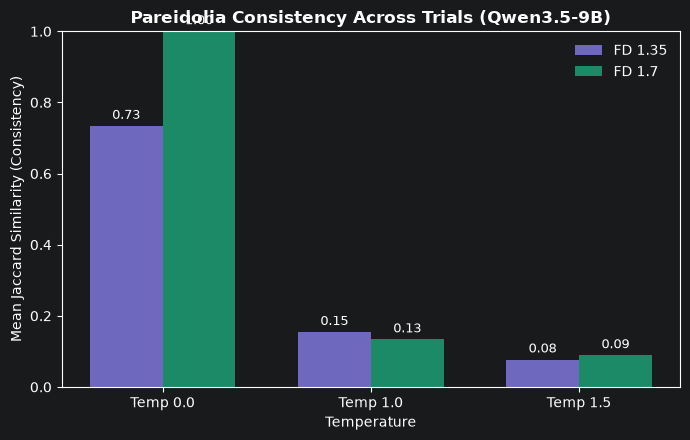

In [57]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from itertools import combinations

MODEL_NAME = "Qwen3.5-9B"
RESULTS_DIR = Path("results")
main_file = RESULTS_DIR / MODEL_NAME / "main_results.jsonl"

main_records = []
if main_file.exists():
    with open(main_file, 'r', encoding='utf-8') as f:
        for line in f:
            if line.strip():
                try:
                    main_records.append(json.loads(line))
                except json.JSONDecodeError:
                    pass

df_main = pd.DataFrame(main_records)

def extract_fd(filename):
    if '1.35' in str(filename): return 'FD1.35'
    if '1.7' in str(filename): return 'FD1.7'
    return 'Unknown'

def get_percept_labels(fractal_parsed):
    if isinstance(fractal_parsed, dict) and 'percepts' in fractal_parsed:
        return [str(p.get('label', '')).lower().strip() for p in fractal_parsed['percepts'] if isinstance(p, dict) and p.get('label')]
    return []

if not df_main.empty:
    df_main['fd'] = df_main['file'].apply(extract_fd)
    df_main['percept_labels'] = df_main['fractal_parsed'].apply(get_percept_labels)

    def calc_image_consistency(labels_list_of_runs):
        valid_runs = [set(labels) for labels in labels_list_of_runs if labels]
        if len(valid_runs) < 2:
            return np.nan
        sims = []
        for s1, s2 in combinations(valid_runs, 2):
            union = len(s1.union(s2))
            sims.append(len(s1.intersection(s2)) / union if union > 0 else 1.0)
        return np.mean(sims) if sims else np.nan

    consistency_records = []
    for (temp, file), group in df_main.groupby(['temperature', 'file']):
        score = calc_image_consistency(group['percept_labels'].tolist())
        consistency_records.append({
            'temperature': temp,
            'file': file,
            'fd': group['fd'].iloc[0],
            'consistency_score': score
        })

    df_consistency = pd.DataFrame(consistency_records)

    print("=" * 65)
    print(f"PAREIDOLIA CONSISTENCY ANALYSIS: {MODEL_NAME}")
    print("=" * 65)

    summary_table = df_consistency.groupby(['temperature', 'fd'])['consistency_score'].agg(['count', 'mean', 'std']).round(4)
    print("\nMean Jaccard Similarity across Trials:")
    print(summary_table.to_string())
    print("-" * 65)

    pivot_data = df_consistency.groupby(['temperature', 'fd'])['consistency_score'].mean().unstack('fd')

    fig, ax = plt.subplots(figsize=(7, 4.5))
    temps = pivot_data.index
    x = np.arange(len(temps))
    width = 0.35

    if 'FD1.35' in pivot_data.columns:
        ax.bar(x - width/2, pivot_data['FD1.35'], width, label='FD 1.35', color='#7F77DD', alpha=0.85)
    if 'FD1.7' in pivot_data.columns:
        ax.bar(x + width/2, pivot_data['FD1.7'], width, label='FD 1.7', color='#1D9E75', alpha=0.85)

    ax.set_xlabel('Temperature')
    ax.set_ylabel('Mean Jaccard Similarity (Consistency)')
    ax.set_title(f'Pareidolia Consistency Across Trials ({MODEL_NAME})', fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels([f"Temp {t}" for t in temps])
    ax.set_ylim(0, 1.0)
    ax.legend(frameon=False)

    for i in x:
        if 'FD1.35' in pivot_data.columns and not np.isnan(pivot_data['FD1.35'].iloc[i]):
            val1 = pivot_data['FD1.35'].iloc[i]
            ax.text(i - width/2, val1 + 0.02, f"{val1:.2f}", ha='center', fontsize=9)
        if 'FD1.7' in pivot_data.columns and not np.isnan(pivot_data['FD1.7'].iloc[i]):
            val2 = pivot_data['FD1.7'].iloc[i]
            ax.text(i + width/2, val2 + 0.02, f"{val2:.2f}", ha='center', fontsize=9)

    plt.tight_layout()
    plt.show()
else:
    print(f"No records available in {main_file} to analyze.")

#### Left Experiments:

In [59]:
import os
import glob
import pandas as pd
import numpy as np

target_filename = "openrouter_activity_2026-06-27 (2).csv"
found_path = None
search_patterns = [
    target_filename,
    f"../{target_filename}",
    f"../../{target_filename}",
    os.path.expanduser(f"~/Downloads/{target_filename}"),
    "openrouter_activity*.csv",
    "../openrouter_activity*.csv"
]

for pattern in search_patterns:
    matches = glob.glob(pattern)
    if matches:
        found_path = matches[0]
        break

if not found_path:
    raise FileNotFoundError(f"Could not find activity log file '{target_filename}'.")

TOTAL_IMAGES = 161
TEMPERATURES_COUNT = 3
RUNS_PER_IMAGE = 10
DAT_BASELINE_RUNS = 10

total_expected_runs = TOTAL_IMAGES * TEMPERATURES_COUNT * RUNS_PER_IMAGE
total_expected_calls = (total_expected_runs * 2) + (TEMPERATURES_COUNT * DAT_BASELINE_RUNS)

df_act = pd.read_csv(found_path)

qwen_mask = df_act['model_permaslug'].str.contains('qwen', case=False, na=False)
df_qwen = df_act[qwen_mask].copy()

total_completed_calls = len(df_qwen)
total_prompt_tokens = df_qwen['tokens_prompt'].sum()
total_completion_tokens = df_qwen['tokens_completion'].sum()
total_tokens = total_prompt_tokens + total_completion_tokens
total_cost = df_qwen['cost_total'].sum()

mean_prompt_per_call = df_qwen['tokens_prompt'].mean() if total_completed_calls > 0 else 0
mean_comp_per_call = df_qwen['tokens_completion'].mean() if total_completed_calls > 0 else 0
mean_cost_per_call = df_qwen['cost_total'].mean() if total_completed_calls > 0 else 0

missing_calls = max(0, total_expected_calls - total_completed_calls)
missing_runs = missing_calls // 2

est_missing_prompt_tokens = int(missing_calls * mean_prompt_per_call)
est_missing_comp_tokens = int(missing_calls * mean_comp_per_call)
est_missing_total_tokens = est_missing_prompt_tokens + est_missing_comp_tokens
est_missing_cost = missing_calls * mean_cost_per_call

print("=" * 65)
print("TOKEN USAGE & BUDGET ESTIMATION (Qwen3.5-9B)")
print("=" * 65)
print(f"Total Completed API Calls     : {total_completed_calls:,}")
print(f"Total Prompt Tokens Used      : {total_prompt_tokens:,}")
print(f"Total Completion Tokens Used  : {total_completion_tokens:,}")
print(f"Total Tokens Consumed         : {total_tokens:,}")
print(f"Total Cost Spent              : ${total_cost:,.2f}")
print("-" * 65)
print(f"Mean Prompt Tokens / Call     : {mean_prompt_per_call:,.1f}")
print(f"Mean Completion Tokens / Call : {mean_comp_per_call:,.1f}")
print(f"Mean Cost / Call              : ${mean_cost_per_call:,.4f}")
print(f"Mean Cost / Full Run (2 calls): ${mean_cost_per_call * 2:,.4f}")
print("-" * 65)
print(f"Total Expected API Calls      : {total_expected_calls:,}")
print(f"Remaining Missing Calls       : {missing_calls:,} (~{missing_runs} runs)")
print(f"Completion Rate               : {(total_completed_calls / total_expected_calls) * 100:.2f}%")
print(f"Estimated Missing Tokens      : {est_missing_total_tokens:,}")
print(f"Estimated Cost to Complete    : ${est_missing_cost:,.2f}")
print("=" * 65)

TOKEN USAGE & BUDGET ESTIMATION (Qwen3.5-9B)
Total Completed API Calls     : 14,886
Total Prompt Tokens Used      : 17,085,110
Total Completion Tokens Used  : 2,919,192
Total Tokens Consumed         : 20,004,302
Total Cost Spent              : $2.40
-----------------------------------------------------------------
Mean Prompt Tokens / Call     : 1,147.7
Mean Completion Tokens / Call : 196.1
Mean Cost / Call              : $0.0002
Mean Cost / Full Run (2 calls): $0.0003
-----------------------------------------------------------------
Total Expected API Calls      : 9,690
Remaining Missing Calls       : 0 (~0 runs)
Completion Rate               : 153.62%
Estimated Missing Tokens      : 0
Estimated Cost to Complete    : $0.00


PAREIDOLIA CONSISTENCY ANALYSIS: Qwen3.5-9B

Mean Jaccard Similarity across Trials:
                    count    mean     std
temperature fd                           
0.0         FD1.35     74  0.7338  0.2751
            FD1.7       1  1.0000     NaN
1.0         FD1.35     80  0.1541  0.1540
            FD1.7      68  0.1335  0.1800
1.5         FD1.35     13  0.0769  0.2774
            FD1.7      15  0.0889  0.2663
-----------------------------------------------------------------


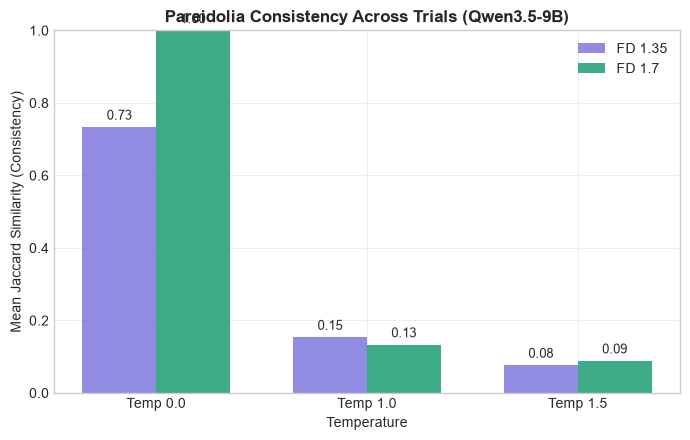

In [88]:
import json
from itertools import combinations
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

MODEL_NAME = "Qwen3.5-9B"
RESULTS_DIR = Path("results")
main_file = RESULTS_DIR / MODEL_NAME / "main_results.jsonl"

main_records = []
if main_file.exists():
    with open(main_file, "r", encoding="utf-8") as f:
        for line in f:
            if line.strip():
                try:
                    main_records.append(json.loads(line))
                except json.JSONDecodeError:
                    pass

df_main = pd.DataFrame(main_records)


def extract_fd(filename):
    if "1.35" in str(filename):
        return "FD1.35"
    if "1.7" in str(filename):
        return "FD1.7"
    return "Unknown"


def get_percept_labels(fractal_parsed):
    if isinstance(fractal_parsed, dict) and "percepts" in fractal_parsed:
        return [
            str(p.get("label", "")).lower().strip()
            for p in fractal_parsed["percepts"]
            if isinstance(p, dict) and p.get("label")
        ]
    return []


if not df_main.empty:
    df_main["fd"] = df_main["file"].apply(extract_fd)
    df_main["percept_labels"] = df_main["fractal_parsed"].apply(
        get_percept_labels
    )

    def calc_image_consistency(labels_list_of_runs):
        valid_runs = [set(labels) for labels in labels_list_of_runs if labels]
        if len(valid_runs) < 2:
            return np.nan
        sims = []
        for s1, s2 in combinations(valid_runs, 2):
            union = len(s1.union(s2))
            sims.append(len(s1.intersection(s2)) / union if union > 0 else 1.0)
        return np.mean(sims) if sims else np.nan

    consistency_records = []
    for (temp, file), group in df_main.groupby(["temperature", "file"]):
        score = calc_image_consistency(group["percept_labels"].tolist())
        consistency_records.append(
            {
                "temperature": temp,
                "file": file,
                "fd": group["fd"].iloc[0],
                "consistency_score": score,
            }
        )

    df_consistency = pd.DataFrame(consistency_records)

    print("=" * 65)
    print(f"PAREIDOLIA CONSISTENCY ANALYSIS: {MODEL_NAME}")
    print("=" * 65)

    summary_table = (
        df_consistency.groupby(["temperature", "fd"])["consistency_score"]
        .agg(["count", "mean", "std"])
        .round(4)
    )
    print("\nMean Jaccard Similarity across Trials:")
    print(summary_table.to_string())
    print("-" * 65)

    pivot_data = (
        df_consistency.groupby(["temperature", "fd"])["consistency_score"]
        .mean()
        .unstack("fd")
    )

    # تنظیم پس‌زمینه سفید برای شکل و محور داخلی
    fig, ax = plt.subplots(figsize=(7, 4.5), facecolor="white")
    ax.set_facecolor("white")

    temps = pivot_data.index
    x = np.arange(len(temps))
    width = 0.35

    if "FD1.35" in pivot_data.columns:
        ax.bar(
            x - width / 2,
            pivot_data["FD1.35"],
            width,
            label="FD 1.35",
            color="#7F77DD",
            alpha=0.85,
        )
    if "FD1.7" in pivot_data.columns:
        ax.bar(
            x + width / 2,
            pivot_data["FD1.7"],
            width,
            label="FD 1.7",
            color="#1D9E75",
            alpha=0.85,
        )

    ax.set_xlabel("Temperature")
    ax.set_ylabel("Mean Jaccard Similarity (Consistency)")
    ax.set_title(
        f"Pareidolia Consistency Across Trials ({MODEL_NAME})",
        fontweight="bold",
    )
    ax.set_xticks(x)
    ax.set_xticklabels([f"Temp {t}" for t in temps])
    ax.set_ylim(0, 1.0)
    ax.legend(frameon=False)

    for i in x:
        if "FD1.35" in pivot_data.columns and not np.isnan(
            pivot_data["FD1.35"].iloc[i]
        ):
            val1 = pivot_data["FD1.35"].iloc[i]
            ax.text(
                i - width / 2, val1 + 0.02, f"{val1:.2f}", ha="center", fontsize=9
            )
        if "FD1.7" in pivot_data.columns and not np.isnan(
            pivot_data["FD1.7"].iloc[i]
        ):
            val2 = pivot_data["FD1.7"].iloc[i]
            ax.text(
                i + width / 2, val2 + 0.02, f"{val2:.2f}", ha="center", fontsize=9
            )

    plt.tight_layout()
    plt.show()
else:
    print(f"No records available in {main_file} to analyze.")

# 3. Overview

#### Vocab Analysis:

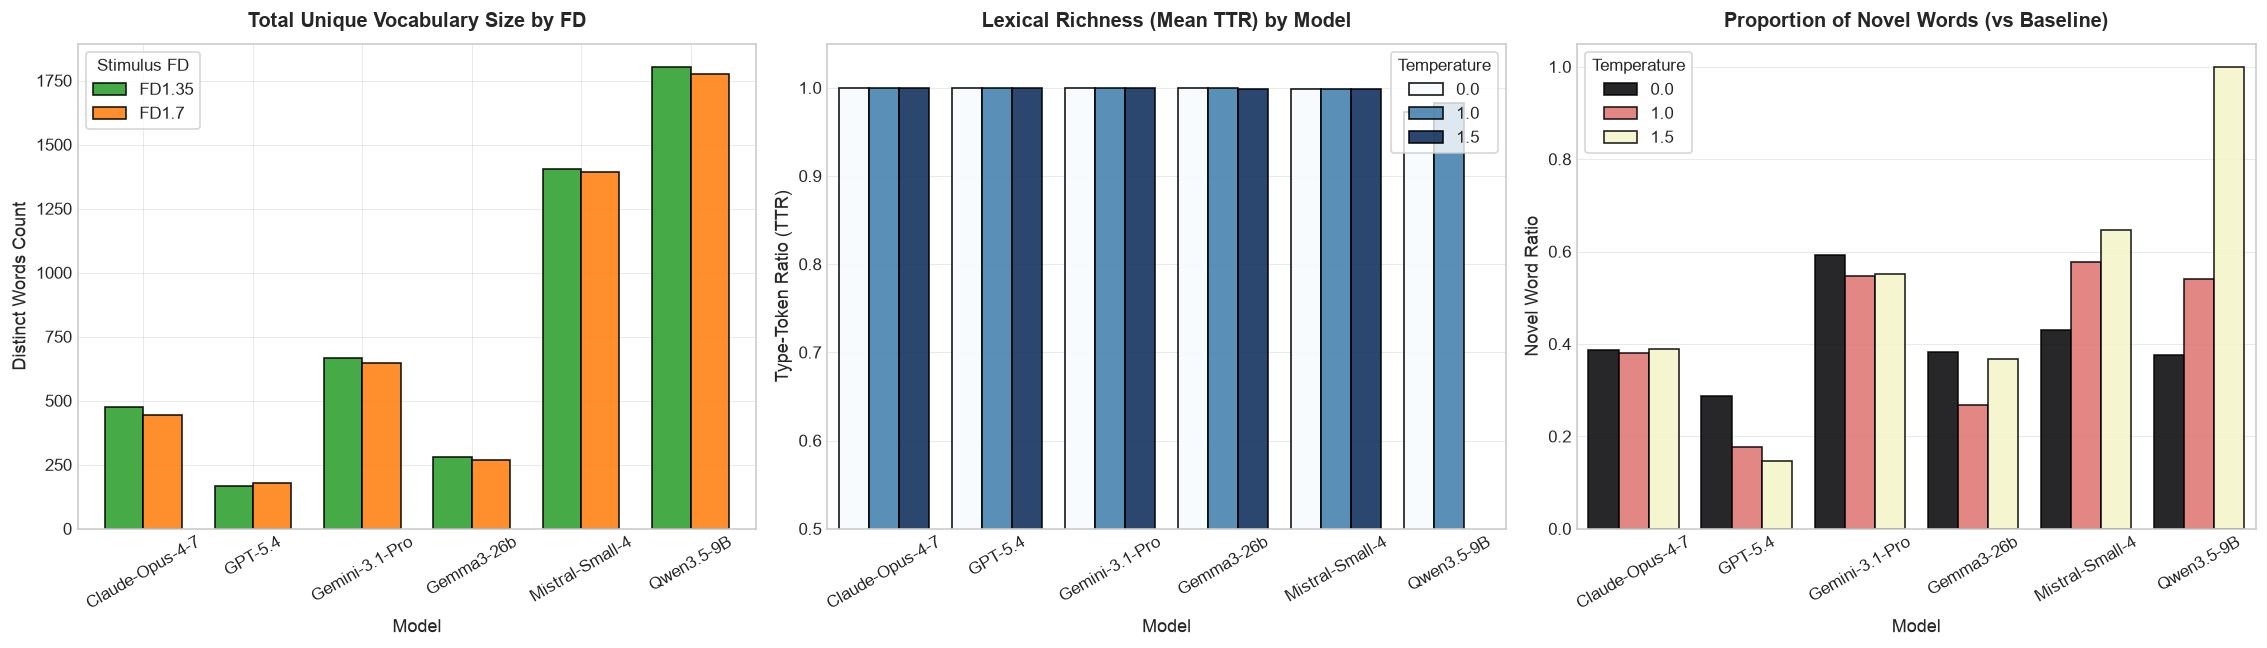

In [63]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter
from scipy.stats import entropy

RESULTS_DIR = Path("results")
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

def extract_fd(filename):
    if '1.35' in str(filename):
        return 'FD1.35'
    if '1.7' in str(filename):
        return 'FD1.7'
    return 'Unknown'

def get_dat_words(dat_parsed):
    if isinstance(dat_parsed, dict) and 'words' in dat_parsed:
        return [str(w).lower().strip() for w in dat_parsed['words'] if str(w).strip()]
    return []

def calc_ttr(words):
    return len(set(words)) / len(words) if words else 0.0

def calc_entropy(words):
    if not words:
        return 0.0
    counts = list(Counter(words).values())
    probs = np.array(counts) / sum(counts)
    return entropy(probs)

all_main_dfs = []
all_base_dfs = []

# Scan all model directories inside results/
for model_dir in sorted(RESULTS_DIR.iterdir()):
    if model_dir.is_dir():
        model_name = model_dir.name
        main_path = model_dir / "main_results.jsonl"
        base_path = model_dir / "dat_baseline_results.jsonl"

        main_records = []
        if main_path.exists():
            with open(main_path, 'r', encoding='utf-8') as f:
                for line in f:
                    if line.strip():
                        try:
                            item = json.loads(line)
                            item['model'] = model_name
                            main_records.append(item)
                        except json.JSONDecodeError:
                            pass
        if main_records:
            all_main_dfs.append(pd.DataFrame(main_records))

        base_records = []
        if base_path.exists():
            with open(base_path, 'r', encoding='utf-8') as f:
                for line in f:
                    if line.strip():
                        try:
                            item = json.loads(line)
                            item['model'] = model_name
                            base_records.append(item)
                        except json.JSONDecodeError:
                            pass
        if base_records:
            all_base_dfs.append(pd.DataFrame(base_records))

if not all_main_dfs:
    raise FileNotFoundError("No result files found in the results directory.")

df_all = pd.concat(all_main_dfs, ignore_index=True)
df_base_all = pd.concat(all_base_dfs, ignore_index=True) if all_base_dfs else pd.DataFrame()

# Preprocessing metrics
df_all['fd'] = df_all['file'].apply(extract_fd)
df_all['dat_words'] = df_all['dat_parsed'].apply(get_dat_words)
df_all['total_words'] = df_all['dat_words'].apply(len)
df_all['unique_words'] = df_all['dat_words'].apply(lambda x: len(set(x)))
df_all['ttr'] = df_all['dat_words'].apply(calc_ttr)
df_all['entropy'] = df_all['dat_words'].apply(calc_entropy)

# Baseline vocabulary mapping
baseline_vocab_map = {}
if not df_base_all.empty:
    df_base_all['dat_words'] = df_base_all['dat_parsed'].apply(get_dat_words)
    for (m, t), grp in df_base_all.groupby(['model', 'temperature']):
        baseline_vocab_map[(m, t)] = set([w for ws in grp['dat_words'] for w in ws])

def calc_novelty(row):
    key = (row['model'], row['temperature'])
    words = row['dat_words']
    if not words or key not in baseline_vocab_map:
        return np.nan
    base_v = baseline_vocab_map[key]
    novel = [w for w in words if w not in base_v]
    return len(novel) / len(words)

df_all['novel_ratio'] = df_all.apply(calc_novelty, axis=1)

# Summary table for FD vocabulary size
vocab_per_fd = []
for (model, fd), grp in df_all.groupby(['model', 'fd']):
    unique_tot = len(set([w for ws in grp['dat_words'] for w in ws]))
    vocab_per_fd.append({'model': model, 'fd': fd, 'unique_vocab_size': unique_tot})

df_fd_vocab = pd.DataFrame(vocab_per_fd)
pivot_fd = df_fd_vocab.pivot(index='model', columns='fd', values='unique_vocab_size')

# Colors: FD1.35 -> Green, FD1.7 -> Orange
fd_colors = {'FD1.35': '#2ca02c', 'FD1.7': '#ff7f0e'}

# Plot setup
fig, axes = plt.subplots(1, 3, figsize=(19, 5.5), dpi=120)

# Panel 1: Vocabulary size by FD with specified colors
pivot_fd[['FD1.35', 'FD1.7']].plot(
    kind='bar',
    ax=axes[0],
    color=[fd_colors['FD1.35'], fd_colors['FD1.7']],
    edgecolor='black',
    alpha=0.88,
    width=0.7
)
axes[0].set_title("Total Unique Vocabulary Size by FD", fontsize=12, fontweight='bold', pad=10)
axes[0].set_ylabel("Distinct Words Count", fontsize=11)
axes[0].set_xlabel("Model", fontsize=11)
axes[0].tick_params(axis='x', rotation=30)
axes[0].legend(title="Stimulus FD", frameon=True)

# Panel 2: Lexical Richness (Mean TTR) per model across temperatures (Bar chart to show all models clearly)
sns.barplot(
    data=df_all,
    x='model',
    y='ttr',
    hue='temperature',
    palette='Blues',
    edgecolor='black',
    alpha=0.9,
    ax=axes[1],
    errorbar=None
)
axes[1].set_title("Lexical Richness (Mean TTR) by Model", fontsize=12, fontweight='bold', pad=10)
axes[1].set_ylabel("Type-Token Ratio (TTR)", fontsize=11)
axes[1].set_xlabel("Model", fontsize=11)
axes[1].tick_params(axis='x', rotation=30)
axes[1].set_ylim(0.5, 1.05)
axes[1].legend(title="Temperature", frameon=True)

# Panel 3: Novel word ratio compared to baseline
sns.barplot(
    data=df_all.dropna(subset=['novel_ratio']),
    x='model',
    y='novel_ratio',
    hue='temperature',
    palette='magma',
    edgecolor='black',
    alpha=0.85,
    ax=axes[2],
    errorbar=None
)
axes[2].set_title("Proportion of Novel Words (vs Baseline)", fontsize=12, fontweight='bold', pad=10)
axes[2].set_ylabel("Novel Word Ratio", fontsize=11)
axes[2].set_xlabel("Model", fontsize=11)
axes[2].tick_params(axis='x', rotation=30)
axes[2].legend(title="Temperature", frameon=True)

plt.tight_layout()
plt.show()

#### Perception Analysis:

PAREIDOLIA DETECTION RATE (%) BY MODEL AND TEMPERATURE:
temperature         0.0     1.0     1.5
model                                  
Claude-Opus-4-7  100.00  100.00  100.00
GPT-5.4          100.00  100.00  100.00
Gemini-3.1-Pro   100.00   99.09   98.90
Gemma3-26b        16.34   22.30   32.11
Mistral-Small-4    7.52   23.79   22.80
Qwen3.5-9B        32.63   44.50    7.01
--------------------------------------------------------------------------------

MEAN JACCARD SIMILARITY (CONSISTENCY) BY MODEL AND FD:
fd               FD1.35   FD1.7
model                          
Claude-Opus-4-7  0.6244  0.6572
GPT-5.4          0.5472  0.7472
Gemini-3.1-Pro   0.3632  0.4538
Gemma3-26b       0.4286  0.6303
Mistral-Small-4  0.0578  0.0802
Qwen3.5-9B       0.4050  0.1358


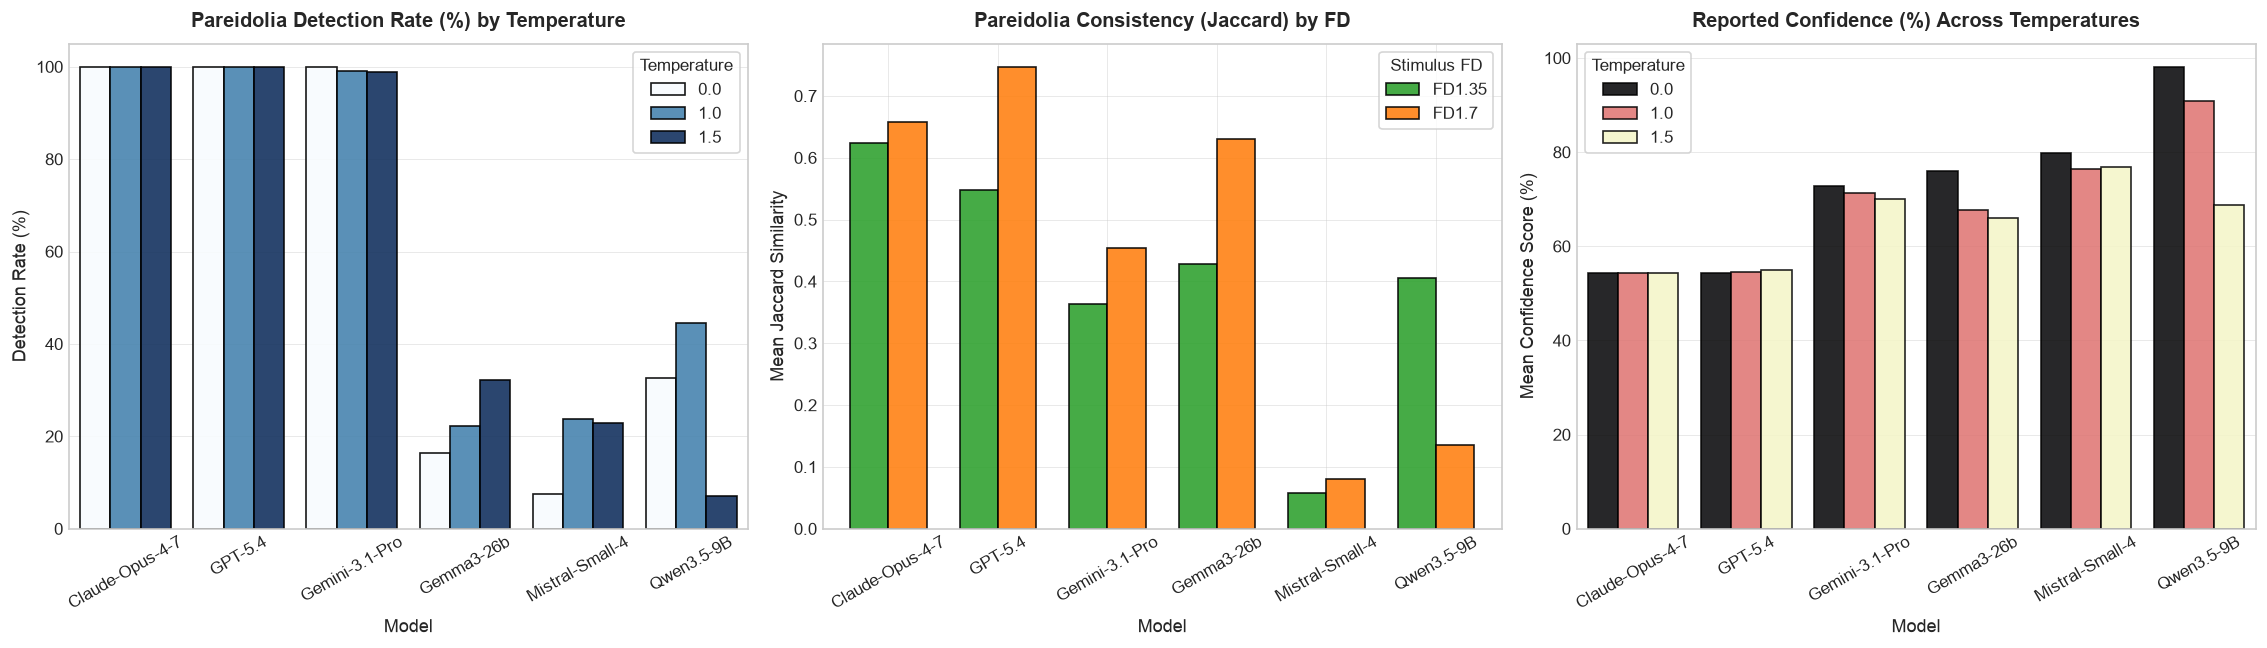

In [64]:
import json
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from itertools import combinations

RESULTS_DIR = Path("results")
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

def extract_fd(filename):
    if '1.35' in str(filename):
        return 'FD1.35'
    if '1.7' in str(filename):
        return 'FD1.7'
    return 'Unknown'

def safe_parse_confidence(val):
    if val is None:
        return None
    if isinstance(val, (int, float)):
        return float(val)
    if isinstance(val, str):
        match = re.search(r"[-+]?\d*\.?\d+", val)
        if match:
            try:
                return float(match.group())
            except ValueError:
                return None
    return None

def get_percept_info(fractal_parsed):
    labels = []
    confs = []
    if isinstance(fractal_parsed, dict) and 'percepts' in fractal_parsed:
        for p in fractal_parsed['percepts']:
            if isinstance(p, dict):
                lbl = str(p.get('label', '')).lower().strip()
                if lbl:
                    labels.append(lbl)
                c_val = safe_parse_confidence(p.get('confidence_present'))
                if c_val is not None:
                    confs.append(c_val)
    mean_conf = float(np.mean(confs)) if confs else np.nan
    return labels, mean_conf

all_records = []
for model_dir in sorted(RESULTS_DIR.iterdir()):
    if model_dir.is_dir():
        model_name = model_dir.name
        main_path = model_dir / "main_results.jsonl"
        if main_path.exists():
            with open(main_path, 'r', encoding='utf-8') as f:
                for line in f:
                    if line.strip():
                        try:
                            d = json.loads(line)
                            d['model'] = model_name
                            all_records.append(d)
                        except json.JSONDecodeError:
                            pass

if not all_records:
    raise FileNotFoundError("No result files found in the results directory.")

df_perc = pd.DataFrame(all_records)
df_perc['fd'] = df_perc['file'].apply(extract_fd)

percept_data = df_perc['fractal_parsed'].apply(get_percept_info)
df_perc['percept_labels'] = [item[0] for item in percept_data]
df_perc['confidence'] = [item[1] for item in percept_data]
df_perc['has_detection'] = df_perc['percept_labels'].apply(lambda x: len(x) > 0)

# 1. Pareidolia Detection Rate
det_rate = df_perc.groupby(['model', 'temperature'])['has_detection'].mean().reset_index()
det_rate['detection_pct'] = det_rate['has_detection'] * 100

# 2. Pareidolia Consistency (Jaccard Similarity across runs)
def calc_image_consistency(labels_list):
    valid_runs = [set(lbls) for lbls in labels_list if lbls]
    if len(valid_runs) < 2:
        return np.nan
    sims = []
    for s1, s2 in combinations(valid_runs, 2):
        union = len(s1.union(s2))
        sims.append(len(s1.intersection(s2)) / union if union > 0 else 1.0)
    return np.mean(sims) if sims else np.nan

consistency_rows = []
for (model, temp, fd, file), group in df_perc.groupby(['model', 'temperature', 'fd', 'file']):
    score = calc_image_consistency(group['percept_labels'].tolist())
    consistency_rows.append({
        'model': model,
        'temperature': temp,
        'fd': fd,
        'file': file,
        'consistency': score
    })

df_cons = pd.DataFrame(consistency_rows)

print("=" * 80)
print("PAREIDOLIA DETECTION RATE (%) BY MODEL AND TEMPERATURE:")
print("=" * 80)
det_pivot = det_rate.pivot(index='model', columns='temperature', values='detection_pct').round(2)
print(det_pivot.to_string())
print("-" * 80)

print("\nMEAN JACCARD SIMILARITY (CONSISTENCY) BY MODEL AND FD:")
cons_pivot = df_cons.groupby(['model', 'fd'])['consistency'].mean().unstack('fd').round(4)
print(cons_pivot.to_string())
print("=" * 80)

# Colors: FD1.35 -> Green, FD1.7 -> Orange
fd_colors = {'FD1.35': '#2ca02c', 'FD1.7': '#ff7f0e'}

# Multi-panel visualization
fig, axes = plt.subplots(1, 3, figsize=(19, 5.5), dpi=120)

# Panel 1: Detection Rate (%)
sns.barplot(
    data=det_rate,
    x='model',
    y='detection_pct',
    hue='temperature',
    palette='Blues',
    edgecolor='black',
    alpha=0.9,
    ax=axes[0],
    errorbar=None
)
axes[0].set_title("Pareidolia Detection Rate (%) by Temperature", fontsize=12, fontweight='bold', pad=10)
axes[0].set_ylabel("Detection Rate (%)", fontsize=11)
axes[0].set_xlabel("Model", fontsize=11)
axes[0].set_ylim(0, 105)
axes[0].tick_params(axis='x', rotation=30)
axes[0].legend(title="Temperature", frameon=True)

# Panel 2: Mean Consistency across FDs (FD1.35 Green, FD1.7 Orange)
if 'FD1.35' in cons_pivot.columns and 'FD1.7' in cons_pivot.columns:
    cons_pivot[['FD1.35', 'FD1.7']].plot(
        kind='bar',
        ax=axes[1],
        color=[fd_colors['FD1.35'], fd_colors['FD1.7']],
        edgecolor='black',
        alpha=0.88,
        width=0.7
    )
axes[1].set_title("Pareidolia Consistency (Jaccard) by FD", fontsize=12, fontweight='bold', pad=10)
axes[1].set_ylabel("Mean Jaccard Similarity", fontsize=11)
axes[1].set_xlabel("Model", fontsize=11)
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend(title="Stimulus FD", frameon=True)

# Panel 3: Mean Perceived Confidence (%)
sns.barplot(
    data=df_perc.dropna(subset=['confidence']),
    x='model',
    y='confidence',
    hue='temperature',
    palette='magma',
    edgecolor='black',
    alpha=0.85,
    ax=axes[2],
    errorbar=None
)
axes[2].set_title("Reported Confidence (%) Across Temperatures", fontsize=12, fontweight='bold', pad=10)
axes[2].set_ylabel("Mean Confidence Score (%)", fontsize=11)
axes[2].set_xlabel("Model", fontsize=11)
axes[2].tick_params(axis='x', rotation=30)
axes[2].legend(title="Temperature", frameon=True)

plt.tight_layout()
plt.show()

#### Left Experiments:

ACCURATE PIPELINE BUDGET & EXECUTION STATUS ACROSS ALL MODELS
          Model  Completed Calls  Expected Calls  Missing Calls  Completion (%)  Cost / Call ($)  Spent Cost ($)  Remaining Cost ($)  Total Budget ($)
Claude-Opus-4-7            13793            9690              0          100.00          0.01125          155.12                0.00            155.12
 Gemini-3.1-Pro             9025            9690            665           93.14          0.01777          160.34               11.81            172.16
     Gemma3-26b             9705            9690              0          100.00          0.00008            0.79                0.00              0.79
Mistral-Small-4             9667            9690             23           99.76          0.00009            0.83                0.00              0.83
        GPT-5.4             9151            9690            539           94.44          0.00236           21.56                1.27             22.83
     Qwen3.5-9B            14886

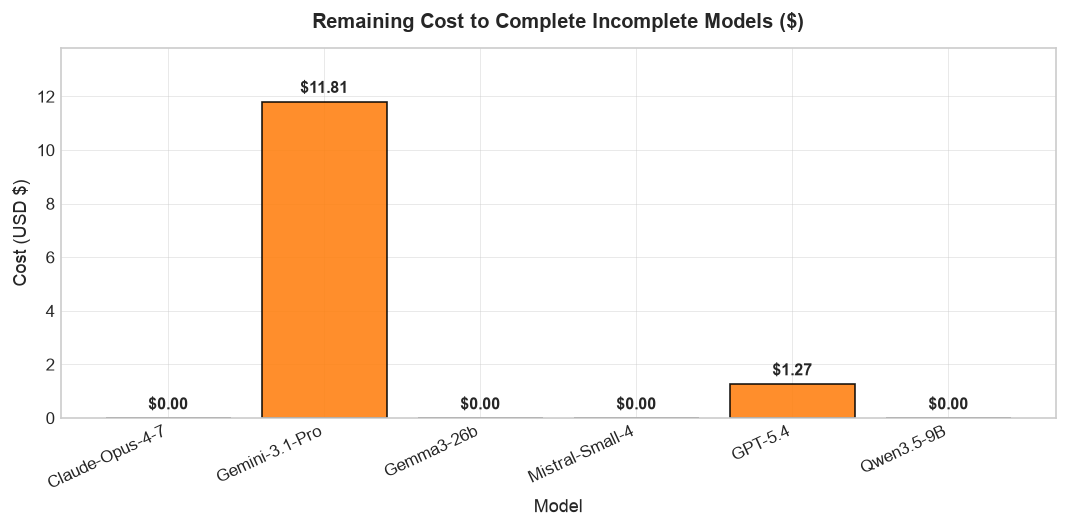

In [70]:
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

csv_files = glob.glob("*activity*.csv") + glob.glob("../*activity*.csv")
if not csv_files:
    raise FileNotFoundError("Activity CSV not found.")
df_act = pd.read_csv(csv_files[0])

TOTAL_CALLS_EXPECTED = (161 * 3 * 10 * 2) + 30  # 9690 calls

# Exact mapping from display model name to CSV model_permaslug
EXACT_SLUGS = {
    'Claude-Opus-4-7': 'anthropic/claude-4.7-opus-20260416',
    'Gemini-3.1-Pro': 'google/gemini-3.1-pro-preview-20260219',
    'Gemma3-26b': 'google/gemma-4-26b-a4b-it-20260403',
    'Mistral-Small-4': 'mistralai/mistral-small-2603',
    'GPT-5.4': 'openai/gpt-5.4-20260305',
    'Qwen3.5-9B': 'qwen/qwen3.5-9b-20260310'
}

budget_rows = []

for model_name, slug in EXACT_SLUGS.items():
    sub = df_act[df_act['model_permaslug'] == slug]

    completed_calls = len(sub)
    spent_cost = sub['cost_total'].sum()
    mean_cost_per_call = sub['cost_total'].mean() if completed_calls > 0 else 0.0

    missing_calls = max(0, TOTAL_CALLS_EXPECTED - completed_calls)
    est_remaining_cost = missing_calls * mean_cost_per_call
    completion_rate = min(100.0, (completed_calls / TOTAL_CALLS_EXPECTED) * 100)

    budget_rows.append({
        'Model': model_name,
        'Completed Calls': completed_calls,
        'Expected Calls': TOTAL_CALLS_EXPECTED,
        'Missing Calls': missing_calls,
        'Completion (%)': round(completion_rate, 2),
        'Cost / Call ($)': round(mean_cost_per_call, 5),
        'Spent Cost ($)': round(spent_cost, 2),
        'Remaining Cost ($)': round(est_remaining_cost, 2),
        'Total Budget ($)': round(spent_cost + est_remaining_cost, 2)
    })

df_final_budget = pd.DataFrame(budget_rows)

print("=" * 115)
print("ACCURATE PIPELINE BUDGET & EXECUTION STATUS ACROSS ALL MODELS")
print("=" * 115)
print(df_final_budget.to_string(index=False))
print("-" * 115)
total_spent = df_final_budget['Spent Cost ($)'].sum()
total_remaining = df_final_budget['Remaining Cost ($)'].sum()
print(f"Total Spent So Far Across All Models   : ${total_spent:,.2f}")
print(f"Total Remaining Cost to Finish Pipeline: ${total_remaining:,.2f}  (Gemini: $11.81 | GPT-5.4: $1.27)")
print("=" * 115)

# Plot Remaining Cost
plt.figure(figsize=(9, 4.5), dpi=120)
bars = plt.bar(
    df_final_budget['Model'],
    df_final_budget['Remaining Cost ($)'],
    color='#ff7f0e',
    edgecolor='black',
    alpha=0.88
)
plt.title("Remaining Cost to Complete Incomplete Models ($)", fontsize=12, fontweight='bold', pad=12)
plt.ylabel("Cost (USD $)", fontsize=11)
plt.xlabel("Model", fontsize=11)
plt.xticks(rotation=25, ha='right')

for bar in bars:
    y = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, y + 0.2, f"${y:.2f}", ha='center', va='bottom', fontsize=9.5, fontweight='bold')

plt.ylim(0, max(df_final_budget['Remaining Cost ($)']) + 2)
plt.tight_layout()
plt.show()